# 2. Mathematics essentials: linear algebra, calculus, probability, statistics and information theory

Machine learning is applied mathematics, and four branches of it appear on almost every
page of this course. **Linear algebra** describes the data (a matrix $\mathbf{X}$) and the
models (linear maps, projections, decompositions). **Calculus** is how models are fitted:
nearly every algorithm from linear regression to transformers is trained by following a
gradient downhill. **Probability and statistics** say what the data-generating process is,
what "the best estimate" means, and how uncertain we should be about it. **Information
theory** supplies the loss functions (cross-entropy) and the splitting criteria of decision
trees.

This notebook covers exactly the mathematics the later notebooks use — no more — and it
teaches every idea *by computing it*: every definition is followed by a few lines of NumPy
that verify it, every theorem by a simulation that shows it at work. If you have studied
this before, treat it as a refresher with a computational twist. Notebooks 6 (least
squares), 7 (logistic regression), 8 (naive Bayes), 9 (decision trees), 13 (mixtures and EM),
14 (PCA) and 15 (text as vectors) each pick up one thread from here and develop it in depth.

**How to read this notebook.** Each subsection combines the same four ingredients, mostly in this order:

1. a **Key idea** box (an indented quote) says in plain words what the concept is and why it matters — read it first;
2. the formal definition, followed by a few lines of NumPy that verify it;
3. an **Example** with numbers small enough to check by hand, and the code that checks them;
4. an **In machine learning** box says where the concept is used — which algorithm, which step of a project —
   with pointers to the notebooks that develop it, often followed by a short demonstration on data.

If a formula does not click on first reading, read the key idea and the example, then come back to it.

**Prerequisites:** notebook 1 (NumPy: shapes, broadcasting, `np.linalg`, `default_rng`).

## Learning objectives

After working through this notebook you will be able to

- compute and interpret norms, distances, dot products, cosine similarity, projections, matrix rank and inverses, read a data set as a design matrix, and explain matrices as linear maps;
- use the eigen-decomposition of symmetric matrices and the singular value decomposition, including the geometry of the SVD and the best low-rank approximation of a matrix;
- explain why covariance matrices are positive semi-definite and what that means for quadratic forms;
- derive gradients with the chain rule (including $\nabla_\mathbf{w}\|\mathbf{X}\mathbf{w}-\mathbf{y}\|^2$), check them numerically (and follow one step of backpropagation), implement gradient descent and explain its stochastic and mini-batch variants (run with `SGDRegressor`), understanding the roles of the learning rate, conditioning (feature scaling) and convexity;
- work with random variables, expectations, common distributions, CDFs and quantiles, joint/marginal/conditional probabilities, covariance and correlation, and Bayes' theorem, and explain the law of large numbers and the central limit theorem;
- define estimators and their bias and variance, derive maximum-likelihood estimates, and show that least squares and cross-entropy are maximum likelihood in disguise (and ridge regression is MAP), reading the common losses — squared, absolute, log loss, Poisson deviance — as noise models;
- compute confidence intervals analytically and by the bootstrap, and run — and criticise — a paired $t$-test on model scores, recognising the multiple-comparisons trap;
- compute entropy, Gini impurity, cross-entropy, KL divergence and mutual information, and relate them to loss functions (softmax and the log loss), to the splitting criteria of decision trees and to drift monitoring;
- say, for every concept, where machine learning uses it — which algorithm, or which step of a project, relies on it.

## Setup

In [85]:
import numpy as np                 # arrays, linear algebra (np.linalg) and random numbers
import pandas as pd                # DataFrames, used for the probability tables in section 3.3
import matplotlib.pyplot as plt    # plotting
import seaborn as sns              # statistical plots on top of matplotlib (not used in this notebook)
# SciPy: stats = probability distributions and statistical tests, optimize = numerical minimisation,
# integrate = numerical integration
from scipy import stats, optimize, integrate

# course helpers: plot style, colour list, and the loader for the cleaned customer-churn table
from course_utils import set_style, PALETTE, load_churn

RANDOM_STATE = 42                          # one fixed seed so every run gives the same random numbers
rng = np.random.default_rng(RANDOM_STATE)  # the seeded random-number generator used throughout
set_style()

## 1. Linear algebra

> **Key idea.** Linear algebra is the arithmetic of whole data sets: it works on tables of numbers in one go
> instead of one value at a time. A model uses it to measure how alike two samples are, to turn features into
> predictions, and to find the few directions in which the data vary most.

### 1.1 Vectors, norms, dot products and cosine similarity

> **Key idea.** A vector is a list of numbers describing one thing — a customer, a document, a
> house. Its *norm* says how big it is, the *distance* between two vectors how different two
> things are, and the *dot product* how much two vectors point the same way. Almost every
> machine-learning algorithm is built from these three operations.

A **vector** $\mathbf{x} \in \mathbb{R}^d$ is an ordered list of $d$ numbers — in this
course, usually one data point: a customer described by $d$ features, or a document by
$d$ word counts. A **norm** measures the length of a vector; the three we use are

$$
\|\mathbf{x}\|_2 = \sqrt{\textstyle\sum_j x_j^2}, \qquad
\|\mathbf{x}\|_1 = \textstyle\sum_j |x_j|, \qquad
\|\mathbf{x}\|_\infty = \max_j |x_j| .
$$

The Euclidean norm $\|\cdot\|_2$ is ordinary length; the Manhattan norm $\|\cdot\|_1$ is the
distance you walk on a grid of streets. Their unit balls (the sets $\{\mathbf{x} :
\|\mathbf{x}\| \le 1\}$) look different, and that difference is the whole story of ridge
versus lasso regularisation in notebook 6: the $\ell_1$ ball has corners on the axes,
which is why $\ell_1$ penalties produce sparse solutions.

The **distance** between two vectors is the norm of their difference, $\|\mathbf{x} - \mathbf{y}\|$:
two samples are similar when they are close. The $\ell_2$ norm gives the Euclidean
(straight-line) distance, $\ell_1$ the Manhattan distance, and $\ell_\infty$ the Chebyshev
distance — the largest difference in any single feature.

The **dot product** (inner product) $\mathbf{x}^\top \mathbf{y} = \sum_j x_j y_j$ links
lengths and angles:

$$
\mathbf{x}^\top \mathbf{y} \;=\; \|\mathbf{x}\|_2 \,\|\mathbf{y}\|_2 \cos\theta ,
\qquad\text{so}\qquad
\cos\theta \;=\; \frac{\mathbf{x}^\top \mathbf{y}}{\|\mathbf{x}\|_2 \|\mathbf{y}\|_2}
$$

is the **cosine similarity** — $1$ for parallel vectors, $0$ for orthogonal
(perpendicular) ones, $-1$ for opposite ones. It ignores the lengths of the vectors, which
is exactly what one wants when comparing documents of different lengths (notebook 15) or embeddings. Every linear model computes $\mathbf{w}^\top\mathbf{x}$: a
prediction is a dot product between the weights and the features.

> **Real-life example.** A supermarket receipt is a dot product: the quantities bought (2 loaves,
> 1 kg of apples, 6 eggs) times the unit prices (2.50, 3.00 and 0.30 euros), summed, give
> 2 × 2.50 + 1 × 3.00 + 6 × 0.30 = 9.80 euros. A linear model's prediction is the same sum, with the
> feature values in the role of the quantities and the weights in the role of the prices.

||x||_2 = 5.0, ||x||_1 = 7.0, ||x||_inf = 4.0
x.y = 0.0  -> cosine +0.00 (orthogonal)
x.z = 50.0  -> cosine +1.00 (parallel: z = 2x, different length, same direction)


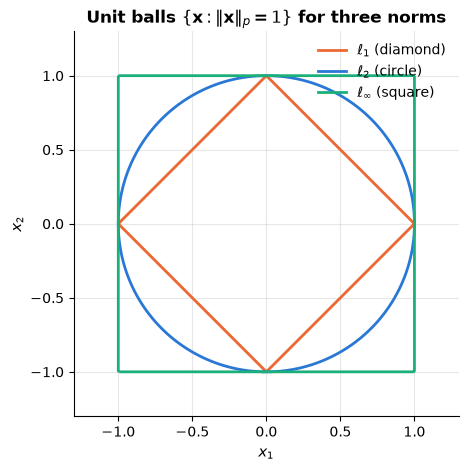

In [86]:
x = np.array([3.0, 4.0])
y = np.array([4.0, -3.0])
z = np.array([6.0, 8.0])

def cosine_similarity(a, b):
    """Cosine of the angle between vectors a and b: a.b / (||a|| ||b||), a number between -1 and 1."""
    return a @ b / (np.linalg.norm(a) * np.linalg.norm(b))    # @ between two 1-D arrays is the dot product

# np.linalg.norm(v, ord): the default ord is the Euclidean (l2) norm, 1 the l1 norm, np.inf the largest |entry|
print(f"||x||_2 = {np.linalg.norm(x):.1f}, ||x||_1 = {np.linalg.norm(x, 1):.1f}, ||x||_inf = {np.linalg.norm(x, np.inf):.1f}")
# the format spec :+.2f always prints the sign (+ or -) and 2 decimals
print(f"x.y = {x @ y:.1f}  -> cosine {cosine_similarity(x, y):+.2f} (orthogonal)")
print(f"x.z = {x @ z:.1f}  -> cosine {cosine_similarity(x, z):+.2f} (parallel: z = 2x, different length, same direction)")

# unit balls of the three norms
grid = np.linspace(-1.3, 1.3, 400)          # 400 evenly spaced values from -1.3 to 1.3
# np.meshgrid turns two 1-D grids into two (400, 400) arrays: gx holds the x and gy the y coordinate of every point
gx, gy = np.meshgrid(grid, grid)
fig, ax = plt.subplots(figsize=(5, 5))
for p, name, color in [(1, "$\\ell_1$ (diamond)", PALETTE[1]), (2, "$\\ell_2$ (circle)", PALETTE[0]), (np.inf, "$\\ell_\\infty$ (square)", PALETTE[2])]:
    # stack to (400, 400, 2), one 2-D point per grid position; the norm along axis=-1 gives (400, 400)
    norm = np.linalg.norm(np.stack([gx, gy], axis=-1), ord=p, axis=-1)
    ax.contour(gx, gy, norm, levels=[1.0], colors=[color], linewidths=2)   # draw only the curve where norm == 1
    ax.plot([], [], color=color, lw=2, label=name)     # an empty line, only to get a legend entry for the contour
ax.set_aspect("equal")                      # one unit is equally long on both axes, so a circle looks round
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_title("Unit balls $\\{\\mathbf{x}: \\|\\mathbf{x}\\|_p = 1\\}$ for three norms")
ax.legend(loc="upper right")
plt.show()

**Example — three customers.** Describe a customer by (years as a customer, number of
products): Ana $= (3, 4)$ and Ben $= (6, 8)$ — the `x` and `z` above — and Cleo $= (4, 3)$.

**Ana and Ben, step by step.**

1. *The difference vector.* Every distance starts from the gap between the two customers, taken
   component by component: Ben $-$ Ana $= (6 - 3, 8 - 4) = (3, 4)$. Ben has been a customer 3 years
   longer and has 4 more products. A distance is a norm (a "length") of this gap vector, and the
   three norms measure that length in different ways.
2. *Euclidean distance ($\ell_2$)* is the straight-line distance, by Pythagoras: square each
   component, add, take the root. $\sqrt{3^2 + 4^2} = \sqrt{9 + 16} = \sqrt{25} = 5$.
3. *Manhattan distance ($\ell_1$)* adds the absolute gaps, like walking along a street grid
   instead of cutting diagonally: $|3| + |4| = 7$.
4. *Chebyshev distance ($\ell_\infty$)* keeps only the single largest gap: $\max(|3|, |4|) = 4$.
5. *Cosine similarity* uses the two original vectors, not the gap. It asks whether they point in
   the same direction, ignoring their lengths:
   - dot product (multiply matching components, then add): $3 \cdot 6 + 4 \cdot 8 = 18 + 32 = 50$;
   - length of Ana: $\sqrt{3^2 + 4^2} = \sqrt{25} = 5$;
   - length of Ben: $\sqrt{6^2 + 8^2} = \sqrt{36 + 64} = \sqrt{100} = 10$;
   - dot product divided by the product of the lengths: $\frac{50}{5 \cdot 10} = \frac{50}{50} = 1$.

The cosine is exactly 1 because Ben is twice Ana: $(6, 8) = 2 \cdot (3, 4)$. Both vectors lie on
the same line through the origin, so the angle between them is 0° and $\cos 0° = 1$, the largest
possible value. In general, for $\mathbf{b} = c\,\mathbf{a}$ with $c > 0$ the dot product is
$c\,\|\mathbf{a}\|^2$ and the product of the lengths is also $c\,\|\mathbf{a}\|^2$, so the factor
$c$ cancels and the cosine is always 1.

**Ana and Cleo, the same steps in short.** They differ by $(4 - 3, 3 - 4) = (1, -1)$: Euclidean
distance $\sqrt{1^2 + (-1)^2} = \sqrt{2} \approx 1.41$, Manhattan distance $|1| + |-1| = 2$, Chebyshev
distance $\max(|1|, |-1|) = 1$; cosine similarity
$\frac{3 \cdot 4 + 4 \cdot 3}{5 \cdot 5} = \frac{24}{25} = 0.96$.

By distance, Cleo is Ana's nearest neighbour; by cosine, Ben is — a "scaled-up Ana" with a
different size but exactly the same profile (the same ratio of products to years,
$4/3 = 8/6$, where Cleo has $3/4$). Distance compares size *and* direction, cosine
only direction; which one fits depends on the question being asked.

In [87]:
ana, ben, cleo = np.array([3.0, 4.0]), np.array([6.0, 8.0]), np.array([4.0, 3.0])
for other_name, other in [("Ben", ben), ("Cleo", cleo)]:
    gap = other - ana                       # the difference vector: every distance is a norm of it
    # :<4 pads the name to 4 characters (left-aligned); cosine_similarity is the helper defined above
    print(f"Ana-{other_name:<4}: l2 {np.linalg.norm(gap):.2f}, l1 {np.linalg.norm(gap, 1):.0f}, "
          f"l_inf {np.linalg.norm(gap, np.inf):.0f}, cosine {cosine_similarity(ana, other):.2f}")

Ana-Ben : l2 5.00, l1 7, l_inf 4, cosine 1.00
Ana-Cleo: l2 1.41, l1 2, l_inf 1, cosine 0.96


> **In machine learning.**
> - **Distances drive neighbour methods.** $k$-nearest neighbours (notebook 8) and $k$-means (notebook 13) compare
>   samples by distance; `KNeighborsClassifier(metric=...)` chooses which one (notebook 8, §1.2 and §8.1). A distance combines the
>   differences in all features, so a feature in large units dominates it: in the demo below, recording income in
>   euros rather than thousands of euros changes a customer's nearest neighbour. Standardising the features first —
>   rescaling each to mean 0 and standard deviation 1 — removes this dependence on units (notebook 4, §4.1;
>   notebook 13, §1.2).
> - **Cosine similarity compares texts.** Documents become vectors of weighted word counts (TF-IDF) scaled to
>   length 1, so their dot product is their cosine and document length no longer matters (notebook 15, §3.2); word
>   vectors are compared by cosine too (notebook 15, §6.2).
> - **Norms are penalties.** Ridge regression adds $\lambda\|\mathbf{w}\|_2^2$ to the loss and the lasso
>   $\lambda\|\mathbf{w}\|_1$, where $\lambda \ge 0$ sets the strength of the penalty (notebook 6, §7.1–7.3).

In [88]:
# a new customer and two existing ones, described by (age in years, yearly income in euros)
query = np.array([30.0, 50_000.0])             # 50_000 is 50000: the underscore only makes it readable
candidates = np.array([[31.0, 52_000.0],       # customer A: one year older, 2 000 euros more income
                       [55.0, 50_500.0]])      # customer B: 25 years older, 500 euros more income
for unit, income_scale in [("euros", 1.0), ("thousands of euros", 1000.0)]:
    rescale = np.array([1.0, 1.0 / income_scale])   # multiplies the income column by 1 / income_scale
    # candidates - query subtracts the query from every row (broadcasting); axis=1: one distance per row
    dists = np.linalg.norm((candidates - query) * rescale, axis=1)
    # argmin() is the position of the smallest distance, and "AB"[0] is "A"
    print(f"income in {unit:<18}: distances {dists.round(1)} -> nearest: customer {'AB'[dists.argmin()]}")

income in euros             : distances [2000.   500.6] -> nearest: customer B
income in thousands of euros: distances [ 2.2 25. ] -> nearest: customer A


### 1.2 Matrices as linear maps

> **Key idea.** A matrix plays two roles. It *stores* a data set — one row per sample, one column
> per feature — and it *transforms* vectors: it can rotate, stretch or squash them. Doing one
> transformation after another is again a matrix (their product), and, as with putting on socks
> and shoes, the order matters.

A matrix $\mathbf{A} \in \mathbb{R}^{m \times n}$ is a table of numbers, but the useful way
to think of it is as a **function** $\mathbf{x} \mapsto \mathbf{A}\mathbf{x}$ from
$\mathbb{R}^n$ to $\mathbb{R}^m$ that is *linear*: $\mathbf{A}(\alpha\mathbf{x} + \beta\mathbf{y})
= \alpha\mathbf{A}\mathbf{x} + \beta\mathbf{A}\mathbf{y}$. The columns of $\mathbf{A}$ are the
images of the basis vectors, and $\mathbf{A}\mathbf{x}$ is a linear combination of those
columns with the entries of $\mathbf{x}$ as weights. In two dimensions every linear map is
some combination of rotation, scaling and shear, and some maps *lose* a dimension:

- The **rank** of $\mathbf{A}$ is the dimension of its image (the column space), i.e. the
  number of linearly independent columns. A rank-deficient map squashes the plane onto a
  line (or a point).
- The **determinant** of a square matrix is the factor by which it scales area (volume);
  $\det \mathbf{A} = 0$ exactly when the map collapses a dimension, i.e. when $\mathbf{A}$
  has no **inverse** $\mathbf{A}^{-1}$ (the map that undoes it: $\mathbf{A}^{-1}\mathbf{A} = \mathbf{I}$,
  where the **identity** matrix $\mathbf{I}$ — ones on the diagonal, zeros elsewhere — leaves
  every vector unchanged).
- The **matrix product** $\mathbf{A}\mathbf{B}$ is the composition of the maps ("first
  $\mathbf{B}$, then $\mathbf{A}$"), which is why it is associative but *not* commutative,
  and why $(\mathbf{A}\mathbf{B})^\top = \mathbf{B}^\top\mathbf{A}^\top$, where the **transpose**
  $\mathbf{A}^\top$ swaps rows and columns, $(\mathbf{A}^\top)_{ij} = a_{ji}$. Computing the product costs
  $O(mnp)$ operations for an $m \times n$ times $n \times p$ product — $O(n^3)$ for square
  matrices — which is why "just multiply the matrices" can be the most expensive step of an
  algorithm.

> **Real-life examples.**
> - A bakery's recipe matrix has one row per ingredient (flour, butter, sugar, in kg) and one column
>   per product (bread, rolls, cakes, per batch); multiplied by a production plan (batches of each)
>   it gives the ingredients to order. If the cake recipe were exactly twice the rolls recipe, the
>   matrix would have rank 2 and determinant 0: one batch of cakes would use the same as two batches
>   of rolls, so no inverse could recover the plan from the ingredient bill.
> - In a photo editor, rotating a picture by 30° and then stretching it horizontally gives a
>   different result from stretching it first and rotating afterwards: the two matrix products
>   differ.

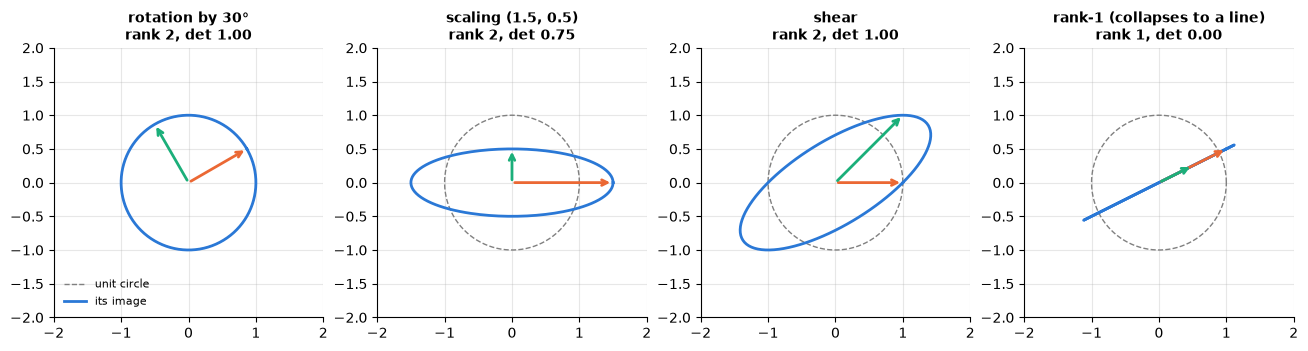

A @ B == B @ A ? False    (matrix products do not commute)
(A @ B).T == B.T @ A.T ? True
A @ inv(A) == I ? True | rotation inverse = transpose: True


In [89]:
theta = np.deg2rad(30)                      # NumPy's trigonometric functions expect radians
maps = {
    "rotation by 30°": np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]]),
    "scaling (1.5, 0.5)": np.array([[1.5, 0.0], [0.0, 0.5]]),
    "shear": np.array([[1.0, 1.0], [0.0, 1.0]]),
    "rank-1 (collapses to a line)": np.array([[1.0, 0.5], [0.5, 0.25]]),   # second row = 0.5 x first row
}
t = np.linspace(0, 2 * np.pi, 200)
circle = np.stack([np.cos(t), np.sin(t)])                    # shape (2, 200): one point per column
e1, e2 = np.array([1.0, 0.0]), np.array([0.0, 1.0])         # the two basis vectors

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (name, A) in zip(axes, maps.items()):     # zip pairs each panel with one (name, matrix) entry
    image = A @ circle                            # (2, 2) @ (2, 200) -> (2, 200): every circle point mapped by A
    ax.plot(circle[0], circle[1], color="gray", ls="--", lw=1, label="unit circle")
    ax.plot(image[0], image[1], color=PALETTE[0], lw=2, label="its image")
    for vec, color in [(e1, PALETTE[1]), (e2, PALETTE[2])]:
        # annotate("", xy=end, xytext=start, arrowprops=...) draws just an arrow; A @ e1 is the first column of A
        ax.annotate("", xy=A @ vec, xytext=(0, 0), arrowprops=dict(arrowstyle="->", color=color, lw=2))
    ax.set_aspect("equal")
    ax.set_xlim(-2, 2)
    ax.set_ylim(-2, 2)
    # matrix_rank counts the linearly independent columns; det is the factor by which A scales area
    ax.set_title(f"{name}\nrank {np.linalg.matrix_rank(A)}, det {np.linalg.det(A):.2f}", fontsize=10)
axes[0].legend(loc="lower left", fontsize=8)
plt.show()

A, B = maps["rotation by 30°"], maps["shear"]
# np.allclose(a, b): True when all entries agree up to tiny floating-point differences
print("A @ B == B @ A ?", np.allclose(A @ B, B @ A), "   (matrix products do not commute)")
print("(A @ B).T == B.T @ A.T ?", np.allclose((A @ B).T, B.T @ A.T))
# np.linalg.inv computes the inverse matrix; np.eye(2) is the 2 x 2 identity
print("A @ inv(A) == I ?", np.allclose(A @ np.linalg.inv(A), np.eye(2)), "| rotation inverse = transpose:", np.allclose(np.linalg.inv(A), A.T))

The orange and green arrows are the images of the basis vectors — the columns of each
matrix. The rank-1 matrix sends the whole circle onto a line segment: two different inputs
can have the same output, so the map cannot be undone (`np.linalg.inv` would raise
`LinAlgError`). Rotations are **orthogonal** matrices ($\mathbf{Q}^\top\mathbf{Q} =
\mathbf{I}$, so $\mathbf{Q}^{-1} = \mathbf{Q}^\top$): they preserve lengths and angles, and
they will reappear as the $\mathbf{U}$ and $\mathbf{V}$ of the SVD.

**Example — the panels above, by hand.** For a $2 \times 2$ matrix the determinant is
$a_{11}a_{22} - a_{12}a_{21}$.

- The scaling $\begin{pmatrix} 1.5 & 0 \\ 0 & 0.5 \end{pmatrix}$ has $\det = 1.5 \cdot 0.5 = 0.75$: every area
  shrinks to three quarters. Its inverse
  $\begin{pmatrix} 1/1.5 & 0 \\ 0 & 1/0.5 \end{pmatrix} \approx \begin{pmatrix} 0.67 & 0 \\ 0 & 2 \end{pmatrix}$
  stretches the plane back, and the product of the two is $\mathbf{I}$.
- The shear $\begin{pmatrix} 1 & 1 \\ 0 & 1 \end{pmatrix}$ has $\det = 1 \cdot 1 - 1 \cdot 0 = 1$: it slants
  the square into a parallelogram of the same area.
- The rank-1 matrix $\begin{pmatrix} 1 & 0.5 \\ 0.5 & 0.25 \end{pmatrix}$ has $\det = 1 \cdot 0.25 - 0.5 \cdot 0.5 = 0$.
  Its second column is half its first, so all outputs lie on one line and different inputs
  collide: $(1, 0)$ and $(0, 2)$ both land on $(1, 0.5)$. No inverse could tell them apart.

In [90]:
scaling, rank_one = maps["scaling (1.5, 0.5)"], maps["rank-1 (collapses to a line)"]   # two matrices of the figure
print("inverse of the scaling:\n", np.linalg.inv(scaling).round(2))
print("rank-1 map: (1, 0) ->", rank_one @ np.array([1.0, 0.0]), " and (0, 2) ->", rank_one @ np.array([0.0, 2.0]))

inverse of the scaling:
 [[0.67 0.  ]
 [0.   2.  ]]
rank-1 map: (1, 0) -> [1.  0.5]  and (0, 2) -> [1.  0.5]


**The design matrix.** In machine learning the most important matrix is the data set itself:
the *design matrix* $\mathbf{X} \in \mathbb{R}^{n \times d}$ has one row $\mathbf{x}_i^\top$ per sample and one
column per feature. Multiplying it by a weight vector computes all $n$ predictions at once —
entry $i$ of $\mathbf{X}\mathbf{w}$ is the dot product $\mathbf{x}_i^\top\mathbf{w}$ — and, read by columns,
$\mathbf{X}\mathbf{w}$ is a weighted sum of the feature columns. The bias $b$ fits the same pattern: give $\mathbf{X}$ an
extra column of ones and let $b$ be its weight, and $\mathbf{X}\mathbf{w} + b$ becomes a single matrix–vector product.
This *intercept column* returns in the dummy-variable trap below and in the hat matrix of section 1.3.

**Example — three samples, two features.**

$$
\mathbf{X} = \begin{pmatrix} 1 & 2 \\ 2 & 0 \\ 3 & 1 \end{pmatrix}, \quad
\mathbf{w} = \begin{pmatrix} 2 \\ 1 \end{pmatrix}: \qquad
\mathbf{X}\mathbf{w} = \begin{pmatrix} 1 \cdot 2 + 2 \cdot 1 \\ 2 \cdot 2 + 0 \cdot 1 \\ 3 \cdot 2 + 1 \cdot 1 \end{pmatrix}
= \begin{pmatrix} 4 \\ 4 \\ 7 \end{pmatrix}
= 2 \begin{pmatrix} 1 \\ 2 \\ 3 \end{pmatrix} + 1 \begin{pmatrix} 2 \\ 0 \\ 1 \end{pmatrix}.
$$

The transpose turns samples × features into features × samples, and
$\mathbf{X}^\top\mathbf{X} = \begin{pmatrix} 14 & 5 \\ 5 & 5 \end{pmatrix}$ is the $d \times d$ table of dot products
between feature columns ($1^2 + 2^2 + 3^2 = 14$, $1 \cdot 2 + 2 \cdot 0 + 3 \cdot 1 = 5$,
$2^2 + 0^2 + 1^2 = 5$). This *Gram matrix* returns in the normal equations (section 1.3) and in
the covariance matrix (section 1.4).

> **Real-life example.** A parcel service predicts how many minutes a courier spends at a stop. Each
> row of the design matrix is one stop, described by (parcels delivered, floors climbed), and the
> weights (2, 1) mean 2 minutes per parcel and 1 per floor. With a bias of 0.5 minutes for parking,
> the three stops above take 4.5, 4.5 and 7.5 minutes, and the new stop in the code below (4 parcels
> to the 4th floor) takes 12.5 minutes.

In [91]:
from sklearn.linear_model import LinearRegression    # ordinary least squares

# e.g. 3 courier stops x (parcels delivered, floors climbed); w_toy: minutes per parcel and per floor
X_toy = np.array([[1.0, 2.0], [2.0, 0.0], [3.0, 1.0]])   # design matrix: 3 samples (rows) x 2 features (columns)
w_toy = np.array([2.0, 1.0])
print("X w =", X_toy @ w_toy, "  (one dot product per row: all predictions at once)")
print("X^T X =\n", X_toy.T @ X_toy)                      # .T is the transpose

# fit(X, y) learns the weights (coef_) and the bias (intercept_); these targets were made with w and b = 0.5
linreg = LinearRegression().fit(X_toy, X_toy @ w_toy + 0.5)
print("coef_ =", linreg.coef_.round(3), "| intercept_ =", round(linreg.intercept_, 3))
X_new = np.array([[4.0, 4.0]])                           # one new sample: a 2-D array with 1 row and 2 features
# predict(X) applies the fitted model to every row of X
print("predict:", linreg.predict(X_new), "| X_new @ coef_ + intercept_:", X_new @ linreg.coef_ + linreg.intercept_)

X w = [4. 4. 7.]   (one dot product per row: all predictions at once)
X^T X =
 [[14.  5.]
 [ 5.  5.]]
coef_ = [2. 1.] | intercept_ = 0.5
predict: [12.5] | X_new @ coef_ + intercept_: [12.5]


> **In machine learning.**
> - **Predicting is a matrix–vector product.** A linear model's `predict` computes $\mathbf{X}\mathbf{w} + b$ for all
>   samples at once (above); logistic regression turns the same scores into probabilities (section 4.3; notebook 7,
>   §1.3).
> - **Rank exposes redundant features.** If a column of $\mathbf{X}$ is a combination of others, $\mathbf{X}^\top\mathbf{X}$
>   has no inverse and many weight vectors give the same predictions — as in the *dummy-variable trap* below, where
>   0/1 columns for every category add up to the intercept's column of ones; `OneHotEncoder(drop="first")` avoids
>   it (notebook 4, §5.1).
> - **Linear steps chain into one matrix.** PCA (section 1.4) followed by a linear model is still one linear model
>   (notebook 14, §2.6). PCA only centres the data and turns them with an orthogonal matrix, so with all components
>   kept no distance changes and a $k$-nearest-neighbour model finds the same neighbours.
> - **Cost decides what is feasible.** For $n = 10^6$ samples and $d = 100$ features, $\mathbf{X}^\top\mathbf{X}$ costs
>   $nd^2 = 10^{10}$ multiply-adds (notebook 6, §2.1), but a kernel method's $n \times n$ matrix of similarities between all pairs of samples would hold $10^{12}$
>   numbers — 8 TB (notebook 11, §4.3).

In [92]:
from sklearn.preprocessing import OneHotEncoder   # turns a categorical column into 0/1 indicator ("dummy") columns

contract = np.array([["monthly"], ["yearly"], ["two-year"], ["monthly"], ["yearly"]])   # 5 samples, 1 feature
for label_text, drop in [("all three dummies", None), ('drop="first"', "first")]:
    # sparse_output=False returns a NumPy array; drop="first" leaves out the first category's column;
    # fit_transform learns the categories and encodes the data in one call
    dummies = OneHotEncoder(drop=drop, sparse_output=False).fit_transform(contract)
    # np.ones(5) is a vector of five ones (the intercept's column); np.column_stack puts arrays side by side
    X_design = np.column_stack([np.ones(len(contract)), dummies])
    print(f"{label_text:<17}: X has {X_design.shape[1]} columns and rank {np.linalg.matrix_rank(X_design)}")
    if drop is None:
        # the dummies add up to the column of ones, so changing w by (1, -1, -1, -1) changes no prediction
        print("   X @ (1, -1, -1, -1) =", X_design @ np.array([1.0, -1.0, -1.0, -1.0]))

all three dummies: X has 4 columns and rank 3
   X @ (1, -1, -1, -1) = [0. 0. 0. 0. 0.]
drop="first"     : X has 3 columns and rank 3


### 1.3 Projections and orthogonality

> **Key idea.** Projecting means dropping a perpendicular: the projection of a point onto a line
> (or a plane) is the closest point on it — like the shadow of a stick on the ground when the sun
> is directly overhead. What is left over, the *residual*, is perpendicular to the line. Fitting
> a linear regression is exactly this: its predictions are the shadow of the targets on the set
> of all predictions a linear model can make.

Two vectors are **orthogonal** if $\mathbf{x}^\top\mathbf{y} = 0$. The **projection** of
$\mathbf{b}$ onto the line spanned by $\mathbf{a}$ is the point on that line closest to
$\mathbf{b}$:

$$
\mathbf{p} \;=\; \frac{\mathbf{a}^\top\mathbf{b}}{\mathbf{a}^\top\mathbf{a}}\,\mathbf{a},
\qquad\text{and the residual } \mathbf{b} - \mathbf{p} \text{ is orthogonal to } \mathbf{a}.
$$

More generally, the projection of $\mathbf{b}$ onto the **column space** of a matrix
$\mathbf{A} \in \mathbb{R}^{n \times d}$ (all vectors of the form $\mathbf{A}\mathbf{w}$) is
$\mathbf{p} = \mathbf{A}\hat{\mathbf{w}}$ where $\hat{\mathbf{w}}$ is chosen so that the
residual is orthogonal to every column: $\mathbf{A}^\top(\mathbf{b} - \mathbf{A}\hat{\mathbf{w}})
= \mathbf{0}$, i.e.

$$
\mathbf{A}^\top\mathbf{A}\,\hat{\mathbf{w}} = \mathbf{A}^\top\mathbf{b}
\qquad\Longrightarrow\qquad
\mathbf{p} = \mathbf{P}\mathbf{b}, \quad \mathbf{P} = \mathbf{A}(\mathbf{A}^\top\mathbf{A})^{-1}\mathbf{A}^\top .
$$

These are the **normal equations** of least squares (notebooks 1 and 6): fitting a linear
model *is* projecting the target vector $\mathbf{y}$ onto the column space of the design
matrix $\mathbf{X}$. The projection matrix $\mathbf{P}$ is symmetric and idempotent
($\mathbf{P}^2 = \mathbf{P}$ — projecting twice changes nothing).

> **Real-life example.** An ice-cream kiosk records its sales on six days together with the
> temperature and the hours of sunshine. Whatever weights it picks, the model "sales = weight ×
> temperature + weight × sunshine" can only produce six-number predictions that lie in one plane,
> the column space; the six actual sales lie off it. Least squares picks the point of the plane
> closest to them, and the residual — what the weather cannot explain, such as a school trip passing
> by on one day — is perpendicular to both columns.

projection of b onto the line of a: [2.588 0.647] | residual orthogonal to a: True
P symmetric: True | P idempotent: True | rank of P: 2
P b == A w_hat: True | A^T (b - P b) == 0: True
least squares via lstsq gives the same w_hat: True


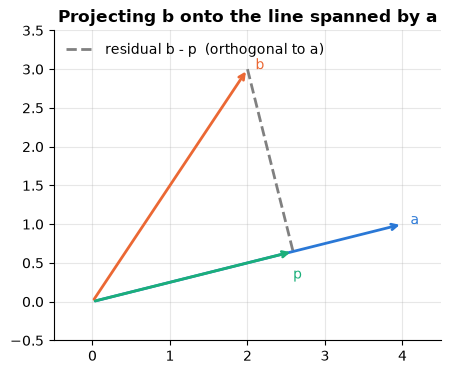

In [93]:
a = np.array([4.0, 1.0])
b = np.array([2.0, 3.0])
p = (a @ b) / (a @ a) * a                 # projection of b onto the line through a: (a.b / a.a) a
# np.isclose(x, 0) is the single-number version of allclose: True if x is 0 up to round-off
print("projection of b onto the line of a:", p.round(3), "| residual orthogonal to a:", np.isclose(a @ (b - p), 0))

# e.g. 6 days x (temperature, hours of sunshine) and, in b6, the kiosk's sales, all as deviations from average
A = rng.normal(size=(6, 2))                 # column space = a plane in R^6
b6 = rng.normal(size=6)
# np.linalg.solve(M, B) returns X with M X = B; with B = A.T (2, 6) the result is (A^T A)^{-1} A^T, shape (2, 6)
P = A @ np.linalg.solve(A.T @ A, A.T)      # A (A^T A)^{-1} A^T without forming the inverse explicitly
w_hat = np.linalg.solve(A.T @ A, A.T @ b6)  # normal equations
print("P symmetric:", np.allclose(P, P.T), "| P idempotent:", np.allclose(P @ P, P), "| rank of P:", np.linalg.matrix_rank(P))
print("P b == A w_hat:", np.allclose(P @ b6, A @ w_hat), "| A^T (b - P b) == 0:", np.allclose(A.T @ (b6 - P @ b6), 0))
# np.linalg.lstsq solves the least-squares problem directly; [0] picks the solution from the tuple it returns
print("least squares via lstsq gives the same w_hat:", np.allclose(np.linalg.lstsq(A, b6, rcond=None)[0], w_hat))

fig, ax = plt.subplots(figsize=(5, 4.2))
# three arrows from the origin: a, b and the projection p
ax.annotate("", xy=a, xytext=(0, 0), arrowprops=dict(arrowstyle="->", color=PALETTE[0], lw=2))
ax.annotate("", xy=b, xytext=(0, 0), arrowprops=dict(arrowstyle="->", color=PALETTE[1], lw=2))
ax.annotate("", xy=p, xytext=(0, 0), arrowprops=dict(arrowstyle="->", color=PALETTE[2], lw=2))
ax.plot([b[0], p[0]], [b[1], p[1]], color="gray", ls="--", label="residual b - p  (orthogonal to a)")
ax.text(*a, "  a", color=PALETTE[0])      # *a unpacks the array into the two arguments x and y
ax.text(*b, "  b", color=PALETTE[1])
ax.text(p[0], p[1] - 0.35, "p", color=PALETTE[2])
ax.set_xlim(-0.5, 4.5)
ax.set_ylim(-0.5, 3.5)
ax.set_aspect("equal")
ax.set_title("Projecting b onto the line spanned by a")
ax.legend(loc="upper left")
plt.show()

**Example — two projections by hand.**

- Above, $\mathbf{b} = (2, 3)$ was projected onto $\mathbf{a} = (4, 1)$: $\mathbf{a}^\top\mathbf{b} = 4 \cdot 2 + 1 \cdot 3 = 11$
  and $\mathbf{a}^\top\mathbf{a} = 4^2 + 1^2 = 17$, so $\mathbf{p} = \frac{11}{17}(4, 1) \approx (2.588, 0.647)$, as
  printed. The residual $\mathbf{b} - \mathbf{p} = \frac{1}{17}(-10, 40)$ is orthogonal to $\mathbf{a}$:
  $4 \cdot (-10) + 1 \cdot 40 = 0$.
- Project three targets $\mathbf{y} = (1, 2, 6)$ onto the all-ones vector $\mathbf{1} = (1, 1, 1)$:
  $\frac{\mathbf{1}^\top\mathbf{y}}{\mathbf{1}^\top\mathbf{1}}\,\mathbf{1} = \frac{9}{3}\,\mathbf{1} = (3, 3, 3)$ — every entry is
  replaced by the **mean**. The residual $(-2, -1, 3)$ sums to zero, which is what "orthogonal to
  $\mathbf{1}$" means. So the best constant prediction in the least-squares sense is the mean, and
  a model with only an intercept is a projection onto $\mathbf{1}$.

In [94]:
from sklearn.dummy import DummyRegressor     # a baseline model that ignores the features

y_three = np.array([1.0, 2.0, 6.0])                       # e.g. units sold on three days
ones = np.ones(3)                                         # the vector (1, 1, 1)
on_ones = (ones @ y_three) / (ones @ ones) * ones         # the projection formula with a = (1, 1, 1)
print("projection:", on_ones, "| residual:", y_three - on_ones, "| residual sum:", (y_three - on_ones).sum())
# DummyRegressor's default strategy="mean" always predicts the training mean; it ignores the features,
# so np.zeros((3, 1)), a 3 x 1 array of zeros, stands in for them
mean_model = DummyRegressor().fit(np.zeros((3, 1)), y_three)
print("DummyRegressor predicts:", mean_model.predict(np.zeros((3, 1))))

projection: [3. 3. 3.] | residual: [-2. -1.  3.] | residual sum: 0.0
DummyRegressor predicts: [3. 3. 3.]


> **In machine learning.**
> - **The hat matrix.** For `LinearRegression`, $\mathbf{P}$ — built from the feature columns plus the intercept's
>   column of ones — turns the targets into the fitted values, $\hat{\mathbf{y}} = \mathbf{P}\mathbf{y}$, and is called the
>   *hat matrix*; its diagonal, the *leverage*, flags samples with unusual inputs (notebook 6, §1.2 and §4.1).
> - **The mean is the simplest projection** (example above): `DummyRegressor`, the baseline every regression model
>   must beat (notebook 5, §5).
> - **Residuals are orthogonal to every feature and sum to zero** (demo below), so they are orthogonal to the fitted
>   values too: a plot of residuals against fitted values never shows a straight-line trend, and any pattern left
>   in it — a curve, a funnel — points to something the model misses (notebook 6, §4.1).

In [95]:
rng_demo = np.random.default_rng(0)   # its own seeded generator: reproducible, and the notebook's rng is left untouched
# e.g. 100 used cars x 3 standardised features (engine power, age, optional extras); y_sim: their prices
X_sim = rng_demo.normal(size=(100, 3))                                          # 100 samples, 3 features
y_sim = X_sim @ np.array([1.5, -2.0, 0.5]) + 3.0 + rng_demo.normal(size=100)   # linear signal plus noise
residuals_sim = y_sim - LinearRegression().fit(X_sim, y_sim).predict(X_sim)     # LinearRegression: imported in 1.2
# X^T r holds one dot product per feature column; np.abs takes absolute values; :.1e prints e.g. 3.7e-14
print(f"largest |X^T r| = {np.abs(X_sim.T @ residuals_sim).max():.1e} | sum of residuals = {residuals_sim.sum():.1e}")

largest |X^T r| = 3.7e-14 | sum of residuals = -1.6e-14


### 1.4 Eigen-decomposition of symmetric matrices

> **Key idea.** A matrix turns most directions, but a few special ones — the *eigenvectors* — it
> only stretches or shrinks, by a factor called the *eigenvalue*. For a symmetric matrix these
> directions are perpendicular to each other and form a natural set of axes; for the covariance
> matrix of a data set they are the axes along which the data spread out most and least.

A vector $\mathbf{q}$ is an **eigenvector** of a square matrix $\mathbf{A}$ with
**eigenvalue** $\lambda$ if $\mathbf{A}\mathbf{q} = \lambda\mathbf{q}$: the map does not
rotate $\mathbf{q}$, it only stretches it by $\lambda$. For a **symmetric** matrix
($\mathbf{A} = \mathbf{A}^\top$) the *spectral theorem* says that there are $n$ real
eigenvalues with mutually orthogonal eigenvectors, so

$$
\mathbf{A} \;=\; \mathbf{Q}\,\boldsymbol{\Lambda}\,\mathbf{Q}^\top
\;=\; \sum_{i=1}^n \lambda_i\,\mathbf{q}_i\mathbf{q}_i^\top,
\qquad \mathbf{Q}^\top\mathbf{Q} = \mathbf{I}, \quad \boldsymbol{\Lambda} = \operatorname{diag}(\lambda_1, \dots, \lambda_n).
$$

Symmetric matrices are the ones that matter in this course — covariance matrices, Gram
matrices $\mathbf{X}^\top\mathbf{X}$, kernel matrices (notebook 11), Hessians — and for
them `np.linalg.eigh` is the right function (faster than `eig`, and it guarantees real,
sorted output). The most important example: the **covariance matrix** of a data set,
$\boldsymbol{\Sigma} = \frac{1}{n-1}\mathbf{X}_c^\top\mathbf{X}_c$ where $\mathbf{X}_c$ is
$\mathbf{X}$ with column means removed. Its eigenvectors are the directions along which the
data vary independently (strictly: *uncorrelated*, which means independent only for Gaussian
data) — the *principal axes* of the point cloud — and its eigenvalues are
the variances along those axes. That single fact is principal component analysis
(notebook 14). The **trace** $\operatorname{tr}\mathbf{A} = \sum_i a_{ii}$, the sum of the diagonal
entries, equals the sum of the eigenvalues of any square matrix; for $\boldsymbol{\Sigma}$ it is the
sum of the feature variances — the *total variance* — which the eigenvalues split among the
principal axes.

**Example — eigenvectors by hand.** Take $\mathbf{A} = \begin{pmatrix} 2 & 1 \\ 1 & 2 \end{pmatrix}$. Then
$\mathbf{A}\begin{pmatrix} 1 \\ 1 \end{pmatrix} = \begin{pmatrix} 3 \\ 3 \end{pmatrix} = 3\begin{pmatrix} 1 \\ 1 \end{pmatrix}$ and
$\mathbf{A}\begin{pmatrix} 1 \\ -1 \end{pmatrix} = \begin{pmatrix} 1 \\ -1 \end{pmatrix}$: the diagonal direction is
stretched by $\lambda_1 = 3$, the anti-diagonal one is left as it is ($\lambda_2 = 1$), and the two
are perpendicular, $1 \cdot 1 + 1 \cdot (-1) = 0$, as the spectral theorem promises. The trace
$2 + 2 = 4$ is the sum of the eigenvalues, $3 + 1$, and the determinant $2 \cdot 2 - 1 \cdot 1 = 3$
their product, $3 \cdot 1$. Read as a covariance matrix — two features with variance 2 each, and an
off-diagonal 1 saying that they tend to rise together (their *covariance*, section 3.3) — $\mathbf{A}$ says
that the data spread most along the diagonal, with variance 3, and least across it, with variance 1.

> **Real-life example.** A clothing maker measures the height and weight of 500 customers. The two
> rise together, so the cloud of points is an elongated ellipse: the top eigenvector of its
> covariance matrix points in the direction "taller and heavier" — overall size — and carries most
> of the variance, while the second, perpendicular one is "heavier for one's height" — build. The
> second code cell below draws such a cloud.

In [96]:
A_sym = np.array([[2.0, 1.0], [1.0, 2.0]])
eigenvalues_sym, eigenvectors_sym = np.linalg.eigh(A_sym)   # ascending eigenvalues, unit eigenvectors as columns
# (1, -1) and (1, 1) scaled to length 1, i.e. entries +-0.707; the sign of an eigenvector is arbitrary
print("eigenvalues:", eigenvalues_sym, "| eigenvectors (columns):\n", eigenvectors_sym.round(3))
# A @ Q multiplies every column by A; Q * eigenvalues scales column j by lambda_j (broadcasting)
print("A q = lambda q for both:", np.allclose(A_sym @ eigenvectors_sym, eigenvectors_sym * eigenvalues_sym))
# np.trace sums the diagonal entries; round(x, 6) hides a round-off error in the last digit of det
print("trace:", np.trace(A_sym), "= 1 + 3 | det:", round(np.linalg.det(A_sym), 6), "= 1 x 3")

eigenvalues: [1. 3.] | eigenvectors (columns):
 [[-0.707  0.707]
 [ 0.707  0.707]]
A q = lambda q for both: True
trace: 4.0 = 1 + 3 | det: 3.0 = 1 x 3


sample covariance:
 [[3.073 1.066]
 [1.066 0.845]]
eigenvalues: [0.417 3.501] | eigenvectors orthonormal: True
Q diag(lam) Q^T reconstructs Sigma: True
trace = sum of eigenvalues = total variance: 3.918 3.918
variance of the data projected on the top eigenvector: 3.501 = largest eigenvalue


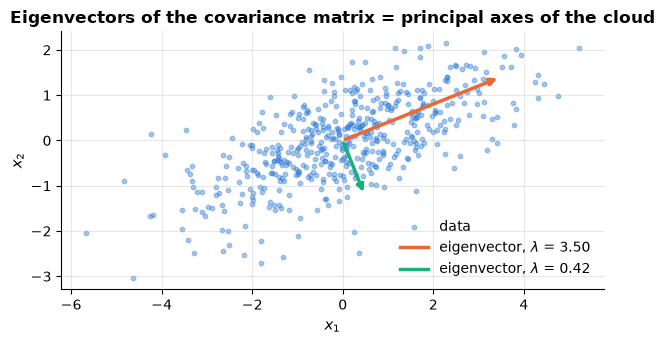

In [97]:
# e.g. height and weight of 500 customers, centred (in arbitrary units): the two rise together
Sigma_true = np.array([[3.0, 1.2], [1.2, 1.0]])
# 500 draws from a 2-D Gaussian with mean (0, 0) and covariance Sigma_true -> shape (500, 2)
X = rng.multivariate_normal(mean=[0, 0], cov=Sigma_true, size=500)
# rowvar=False tells np.cov that the columns are the variables and the rows the observations
Sigma = np.cov(X, rowvar=False)                      # (2, 2) sample covariance
lam, Q = np.linalg.eigh(Sigma)                       # ascending eigenvalues, orthonormal eigenvectors as columns
print("sample covariance:\n", Sigma.round(3))
print("eigenvalues:", lam.round(3), "| eigenvectors orthonormal:", np.allclose(Q.T @ Q, np.eye(2)))
print("Q diag(lam) Q^T reconstructs Sigma:", np.allclose(Q @ np.diag(lam) @ Q.T, Sigma))   # np.diag(v): v on a diagonal
# np.trace is the sum of the diagonal entries
print("trace = sum of eigenvalues = total variance:", np.trace(Sigma).round(3), lam.sum().round(3))
# Q[:, 1] is the eigenvector of the largest eigenvalue (eigh sorts ascending); X @ it projects every point onto it
print("variance of the data projected on the top eigenvector:", (X @ Q[:, 1]).var(ddof=1).round(3), "= largest eigenvalue")

# Q[0] is the first row (the x1 components); np.sign gives +-1 per column, and multiplying flips the columns with x1 < 0
Q = Q * np.sign(Q[0])                                # eigenvector signs are arbitrary: make them point to positive x1
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.scatter(X[:, 0], X[:, 1], s=10, alpha=0.4, label="data")
for i, color in zip([1, 0], [PALETTE[1], PALETTE[2]]):   # largest eigenvalue first
    v = Q[:, i] * 2 * np.sqrt(lam[i])                 # length = 2 standard deviations along that axis
    ax.annotate("", xy=v, xytext=(0, 0), arrowprops=dict(arrowstyle="->", color=color, lw=2.5))
    ax.plot([], [], color=color, lw=2.5, label=f"eigenvector, $\\lambda$ = {lam[i]:.2f}")   # legend entry only
ax.set_aspect("equal")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_title("Eigenvectors of the covariance matrix = principal axes of the cloud")
ax.legend(loc="lower right")
plt.show()

> **In machine learning.**
> - **PCA is this eigen-decomposition.** Its `components_` are the eigenvectors of the covariance matrix, largest
>   eigenvalue first, and `explained_variance_` the eigenvalues; keeping the top $k$ axes reduces $d$ features to
>   $k$ (notebook 14, §2). The demo below reproduces the cell above.
> - **The trace is the total variance**, so $\lambda_i / \operatorname{tr}\boldsymbol{\Sigma}$ is the share of the variance
>   along axis $i$: `explained_variance_ratio_`, the usual guide to how many components to keep (notebook 14,
>   §2.3). Here the first axis carries about 89 % of it.
> - **Gaussian mixtures** model each cluster as an elliptical cloud whose axes are the eigenvectors of its
>   covariance matrix, with half-lengths proportional to the square roots of the eigenvalues (notebook 13, §5.3);
>   `covariance_type="diag"` forces axis-parallel ellipses (notebook 13, §5.4).

In [98]:
from sklearn.decomposition import PCA    # principal component analysis

pca_cloud = PCA().fit(X)   # X: the 500-point cloud above; PCA centres it and, by default, keeps all components
# lam and Q come from the eigh code cell above (eigh sorts ascending, so [::-1] reverses to largest first)
print("explained_variance_:", pca_cloud.explained_variance_.round(3), "| eigenvalues:", lam[::-1].round(3))
# components_ holds the axes as rows; eigenvectors are defined only up to sign, so compare absolute values
print("components_ = eigenvectors:", np.allclose(np.abs(pca_cloud.components_), np.abs(Q[:, ::-1].T)))
print("explained_variance_ratio_:", pca_cloud.explained_variance_ratio_.round(3), "= eigenvalues / trace")

explained_variance_: [3.501 0.417] | eigenvalues: [3.501 0.417]
components_ = eigenvectors: True
explained_variance_ratio_: [0.894 0.106] = eigenvalues / trace


### 1.5 The singular value decomposition

> **Key idea.** Every matrix, whatever its shape, can be taken apart into three simple steps:
> turn, stretch along perpendicular axes, turn again. The stretch factors — the *singular values*
> — say how much each axis matters, and keeping only the largest few gives the best compressed
> copy of the matrix. That one idea is behind PCA, recommender systems and finding topics in text.

The eigen-decomposition needs a square symmetric matrix. Every matrix, of any shape, has a
**singular value decomposition** (SVD):

$$
\mathbf{A} \;=\; \mathbf{U}\,\boldsymbol{\Sigma}\,\mathbf{V}^\top,
\qquad \mathbf{U} \in \mathbb{R}^{m \times r},\ \boldsymbol{\Sigma} = \operatorname{diag}(\sigma_1 \ge \dots \ge \sigma_r > 0),\ \mathbf{V} \in \mathbb{R}^{n \times r},
$$

with orthonormal columns in $\mathbf{U}$ and $\mathbf{V}$ and $r = \operatorname{rank}\mathbf{A}$
(the "compact" SVD; `np.linalg.svd(A, full_matrices=False)` returns the "thin" SVD with
$\min(m, n)$ components, of which those beyond the rank have $\sigma_i = 0$ up to round-off). Geometrically, every
linear map is *a rotation ($\mathbf{V}^\top$), then a scaling by the singular values, then
another rotation ($\mathbf{U}$)*: the unit circle is always mapped to an ellipse whose
semi-axes have lengths $\sigma_i$. The SVD and the eigen-decomposition are related by
$\mathbf{A}^\top\mathbf{A} = \mathbf{V}\boldsymbol{\Sigma}^2\mathbf{V}^\top$ — the right
singular vectors are the eigenvectors of the Gram matrix and $\sigma_i^2$ its eigenvalues,
which is why PCA can be computed either way (notebook 14).

The property that makes the SVD indispensable in machine learning is the **Eckart–Young
theorem** (Eckart & Young, 1936): the best rank-$k$ approximation of $\mathbf{A}$, in the
sense of the Frobenius norm (and the spectral norm), is obtained by keeping the $k$ largest
singular values,

$$
\mathbf{A}_k = \sum_{i=1}^k \sigma_i\,\mathbf{u}_i\mathbf{v}_i^\top,
\qquad
\|\mathbf{A} - \mathbf{A}_k\|_F = \sqrt{\textstyle\sum_{i>k}\sigma_i^2}.
$$

Here $\|\mathbf{M}\|_F = \sqrt{\sum_{i,j} m_{ij}^2}$ is the **Frobenius norm** — the $\ell_2$ norm of
all entries read as one long vector — and $\|\mathbf{A}\|_F^2 = \sum_i \sigma_i^2$ is the *energy* of
the matrix; the **spectral norm** $\|\mathbf{A}\|_2 = \sigma_1$ is its largest stretch factor.

An image is a matrix, so we can *see* this. We use one of the two sample photographs
bundled with scikit-learn (converted to greyscale, $427 \times 640$ pixels).

image shape: (427, 640) | number of singular values: 427 | largest five: [83442. 15393.  9760.  5762.  4909.]


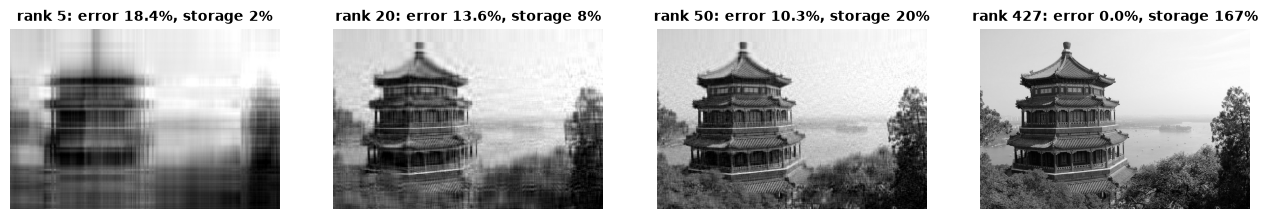

In [99]:
from sklearn.datasets import load_sample_images     # the two example photos that ship with scikit-learn

# .images is a list of two RGB photos, each (427, 640, 3) with values 0-255; [0] takes the first one
image = load_sample_images().images[0].mean(axis=2)        # RGB -> greyscale, shape (427, 640)
# thin SVD: U (427, 427), s (427,) sorted descending, Vt (427, 640)
U, s, Vt = np.linalg.svd(image, full_matrices=False)
print("image shape:", image.shape, "| number of singular values:", len(s), "| largest five:", s[:5].round(0))

ranks = [5, 20, 50, len(s)]
fig, axes = plt.subplots(1, 4, figsize=(16, 3.4))
for ax, k in zip(axes, ranks):
    # U[:, :k] * s[:k] scales column i of U by s_i (broadcasting), like U_k @ diag(s_k); @ Vt[:k] then gives (427, 640)
    approx = (U[:, :k] * s[:k]) @ Vt[:k]                      # sum of the k leading rank-1 terms
    rel_err = np.linalg.norm(image - approx) / np.linalg.norm(image)   # for a matrix, norm() is the Frobenius norm
    # numbers to store: k columns of U (427 each) + k rows of Vt (640 each) + k singular values, as a share of the pixels
    storage = k * (image.shape[0] + image.shape[1] + 1) / image.size
    ax.imshow(approx, cmap="gray", vmin=0, vmax=255)          # the same 0-255 grey scale in every panel
    ax.set_title(f"rank {k}: error {rel_err:.1%}, storage {storage:.0%}", fontsize=10)
    ax.axis("off")
plt.show()

Fifty numbers per row and column (a fifth of the storage) give a recognisable picture,
because the singular values decay fast — most of the "energy" $\sum\sigma_i^2$ is in the
first few components. That decay is what makes dimensionality reduction (notebook 14) and
low-rank recommender models (notebook 14, matrix factorisation) work, and it is worth
looking at directly:

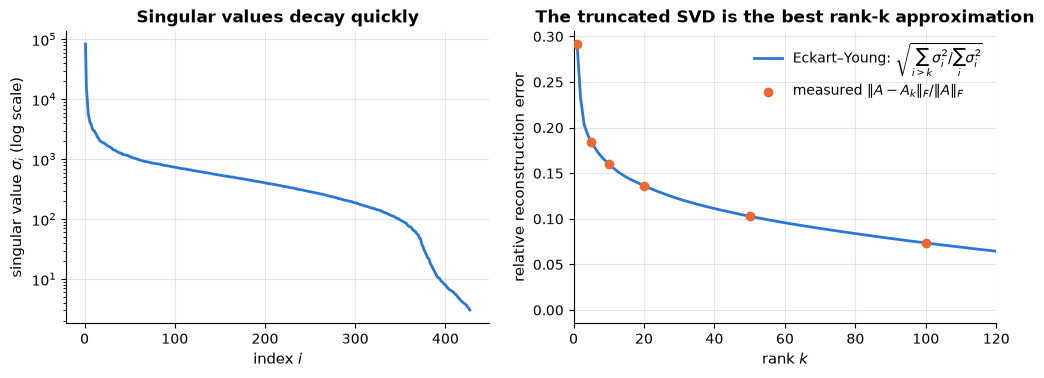

components needed for 99% / 99.9% of the energy sum(sigma_i^2): 54 / 216 of 427


In [100]:
# np.cumsum gives running totals, so energy[k - 1] is the share of sum(sigma_i^2) held by the first k values
energy = np.cumsum(s ** 2) / np.sum(s ** 2)
ks = np.arange(1, len(s) + 1)                                  # ranks 1, 2, ..., 427
predicted_err = np.sqrt(1 - energy)                            # Eckart-Young: ||A - A_k||_F / ||A||_F
# the actual relative error of the rank-k approximation, measured for six values of k
measured_err = [np.linalg.norm(image - (U[:, :k] * s[:k]) @ Vt[:k]) / np.linalg.norm(image) for k in [1, 5, 10, 20, 50, 100]]

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].semilogy(ks, s, lw=2)                 # semilogy: a line plot with a logarithmic y-axis
axes[0].set_xlabel("index $i$")
axes[0].set_ylabel("singular value $\\sigma_i$ (log scale)")
axes[0].set_title("Singular values decay quickly")
axes[1].plot(ks, predicted_err, lw=2, label="Eckart–Young: $\\sqrt{\\sum_{i>k}\\sigma_i^2 / \\sum_i \\sigma_i^2}$")
# zorder=3 draws the dots on top of the line
axes[1].scatter([1, 5, 10, 20, 50, 100], measured_err, color=PALETTE[1], zorder=3, label="measured $\\|A - A_k\\|_F / \\|A\\|_F$")
axes[1].set_xlim(0, 120)
axes[1].set_xlabel("rank $k$")
axes[1].set_ylabel("relative reconstruction error")
axes[1].set_title("The truncated SVD is the best rank-k approximation")
axes[1].legend()
plt.show()
# np.searchsorted(energy, 0.99) is the first index where the (increasing) energy reaches 0.99; + 1 turns it into a count
print(f"components needed for 99% / 99.9% of the energy sum(sigma_i^2): {np.searchsorted(energy, 0.99) + 1} / {np.searchsorted(energy, 0.999) + 1} of {len(s)}")

**Example — an SVD by hand.** Take $\mathbf{A} = \begin{pmatrix} 3 & 0 \\ 4 & 5 \end{pmatrix}$. Its Gram
matrix $\mathbf{A}^\top\mathbf{A} = \begin{pmatrix} 25 & 20 \\ 20 & 25 \end{pmatrix}$ has, like the example of
section 1.4, eigenvectors along $(1, 1)$ and $(1, -1)$, with eigenvalues $25 \pm 20$, i.e. $45$
and $5$. So the singular values are $\sigma_1 = \sqrt{45} \approx 6.708$ (the spectral norm: $\mathbf{A}$
stretches no vector of length 1 further) and $\sigma_2 = \sqrt{5} \approx 2.236$, and the energy checks out:
$\|\mathbf{A}\|_F^2 = 3^2 + 0^2 + 4^2 + 5^2 = 50 = 45 + 5$. The best rank-1 approximation
$\mathbf{A}_1 = \sigma_1\mathbf{u}_1\mathbf{v}_1^\top$ equals $\mathbf{A}\mathbf{v}_1\mathbf{v}_1^\top$ (multiplying $\mathbf{A} = \mathbf{U}\boldsymbol{\Sigma}\mathbf{V}^\top$ on the right by $\mathbf{V}$ gives
$\mathbf{A}\mathbf{V} = \mathbf{U}\boldsymbol{\Sigma}$, i.e. $\mathbf{A}\mathbf{v}_1 = \sigma_1\mathbf{u}_1$);
with $\mathbf{v}_1 = (1, 1)/\sqrt{2}$ it is $\begin{pmatrix} 1.5 & 1.5 \\ 4.5 & 4.5 \end{pmatrix}$. It keeps
$45/50 = 90\,\%$ of the energy, and its error is
$\|\mathbf{A} - \mathbf{A}_1\|_F = \sqrt{1.5^2 + 1.5^2 + 0.5^2 + 0.5^2} = \sqrt{5} = \sigma_2$, exactly as
Eckart–Young says. The ratio $\sigma_1/\sigma_2 = 3$ of the largest to the smallest singular value is the
*condition number* of $\mathbf{A}$, and that of $\mathbf{A}^\top\mathbf{A}$ is its square, $45/5 = 9$ — the number that
sections 1.6 and 2.3 tie to unstable weights and slow gradient descent.

In [101]:
A_small = np.array([[3.0, 0.0], [4.0, 5.0]])
U_small, s_small, Vt_small = np.linalg.svd(A_small)
print("singular values:", s_small.round(3), "| squared:", (s_small ** 2).round(3), "| ||A||_F^2 =", np.sum(A_small ** 2))
# np.outer(u, v) is the matrix u v^T with entries u_i v_j: here the leading rank-1 term sigma_1 u_1 v_1^T
A_rank1 = s_small[0] * np.outer(U_small[:, 0], Vt_small[0])
# .tolist() turns the array into nested Python lists, which print on one line
print("A_1 =", A_rank1.round(3).tolist(), "| ||A - A_1||_F =", np.linalg.norm(A_small - A_rank1).round(3))

singular values: [6.708 2.236] | squared: [45.  5.] | ||A||_F^2 = 50.0
A_1 = [[1.5, 1.5], [4.5, 4.5]] | ||A - A_1||_F = 2.236


> **In machine learning.**
> - **PCA is a truncated SVD**, the $k$ leading terms of the SVD of the centred data $\mathbf{X}_c$: the right singular
>   vectors are the principal axes, $\sigma_i^2/(n-1)$ the variances along them, and by Eckart–Young no other $k$
>   axes reconstruct the data with a smaller error (notebook 14, §2.2).
> - **Recommender systems.** A users × films ratings matrix is close to low rank: a few hidden "taste" factors
>   explain most ratings. In the demo below two singular values hold 98 % of the energy, the second factor's sign
>   separates action from romance films, and the rank-2 approximation raises Eve's missing rating from the film's
>   mean, 3.0, to 3.9: she rates like the action fans. (Filling the gap with the mean is a shortcut; real
>   recommenders fit the factors to the observed ratings only, notebook 14, §4.)
> - **Text.** Latent semantic analysis (notebook 15, §5) and count-based word vectors (notebook 15, §6.2) are
>   truncated SVDs of weighted word-count matrices.

In [102]:
# ratings (1-5) of five users (rows) for two action and two romance films (columns); np.nan marks a missing rating
ratings = np.array([[5, 5, 1, 1],           # Ana
                    [4, 5, 1, 2],           # Ben
                    [1, 1, 5, 4],           # Cleo
                    [2, 1, 4, 5],           # Dan
                    [5, np.nan, 2, 1]])     # Eve has not seen the second action film
film_means = np.nanmean(ratings, axis=0)                     # column means that skip the missing value
# np.isnan is True at the missing entry; np.where(condition, a, b) takes a where True, else b
filled = np.where(np.isnan(ratings), film_means, ratings)
U_ratings, s_ratings, Vt_ratings = np.linalg.svd(filled, full_matrices=False)
energy_two = np.sum(s_ratings[:2] ** 2) / np.sum(s_ratings ** 2)        # share of sum(sigma_i^2) in the first two
print("singular values:", s_ratings.round(2), f"| energy in the first two: {energy_two:.0%}")   # :.0% = percentage
print("second film factor (action, action, romance, romance):", Vt_ratings[1].round(2))
rank2 = (U_ratings[:, :2] * s_ratings[:2]) @ Vt_ratings[:2]   # the two leading rank-1 terms, as for the image
print(f"Eve's missing rating: film mean {filled[4, 1]:.1f} -> rank-2 reconstruction {rank2[4, 1]:.1f}")

singular values: [13.1   7.05  1.83  1.11] | energy in the first two: 98%
second film factor (action, action, romance, romance): [ 0.39  0.45 -0.58 -0.56]
Eve's missing rating: film mean 3.0 -> rank-2 reconstruction 3.9


### 1.6 Positive (semi-)definite matrices and the covariance matrix

> **Key idea.** A symmetric matrix assigns a number — a spread or a curvature — to every
> direction. It is *positive semi-definite* when that number is never negative, like the
> variance of data, and *positive definite* when it is always strictly positive: then it
> describes a bowl with a single lowest point, which is what gives a minimisation problem one
> clear answer.

A symmetric matrix $\mathbf{A}$ is **positive semi-definite** (PSD, written
$\mathbf{A} \succeq 0$) if the quadratic form $\mathbf{x}^\top\mathbf{A}\mathbf{x} \ge 0$
for every $\mathbf{x}$, and **positive definite** (PD, $\mathbf{A} \succ 0$) if the
inequality is strict for $\mathbf{x} \ne \mathbf{0}$. Equivalently: all eigenvalues are
$\ge 0$ (resp. $> 0$). Three reasons to care:

1. **Every covariance matrix is PSD.** With $\mathbf{X}_c$ the centred data,
   $\mathbf{x}^\top\boldsymbol{\Sigma}\mathbf{x} = \frac{1}{n-1}\mathbf{x}^\top\mathbf{X}_c^\top\mathbf{X}_c\mathbf{x}
   = \frac{1}{n-1}\|\mathbf{X}_c\mathbf{x}\|_2^2 \ge 0$ — it is the variance of the data
   projected onto direction $\mathbf{x}$, and variances cannot be negative. The same
   argument shows that every Gram matrix $\mathbf{X}^\top\mathbf{X}$ and every kernel matrix
   is PSD.
2. **PD matrices define bowl-shaped functions.** $f(\mathbf{w}) = \frac{1}{2}\mathbf{w}^\top\mathbf{A}\mathbf{w}$
   has ellipsoidal contours with a unique minimum when $\mathbf{A} \succ 0$, and a saddle
   when $\mathbf{A}$ has eigenvalues of both signs. Since the Hessian of the least-squares
   loss $\|\mathbf{X}\mathbf{w} - \mathbf{y}\|_2^2$ is $2\mathbf{X}^\top\mathbf{X} \succeq 0$, least squares is convex
   (section 2.5).
3. **Regularisation makes PSD matrices PD.** $\mathbf{X}^\top\mathbf{X}$ can be singular
   (collinear features); adding $\lambda\mathbf{I}$ shifts every eigenvalue up by $\lambda$,
   which is why ridge regression (notebook 6) always has a unique solution.

> **Real-life example.** An investor spreads money over several shares. The variance of the
> portfolio's return is the quadratic form above, with the amounts invested as the vector and the
> covariance matrix of the share returns as the matrix, so it can never be negative, whatever the
> amounts (selling short included). A "covariance matrix" pieced together pair by pair from price
> histories of different lengths can fail this test: with a negative eigenvalue it would promise a
> portfolio of negative risk, a sign that it is not a valid covariance matrix.

min of x^T Sigma x over 10 000 random directions: 0.000  (never negative)
eigenvalues of Sigma: [0.417 3.501]
eigenvalues of the indefinite matrix: [-1.  1.]
eigenvalues of a singular Gram matrix: [0. 5.] -> after adding 0.5 I: [0.5 5.5]


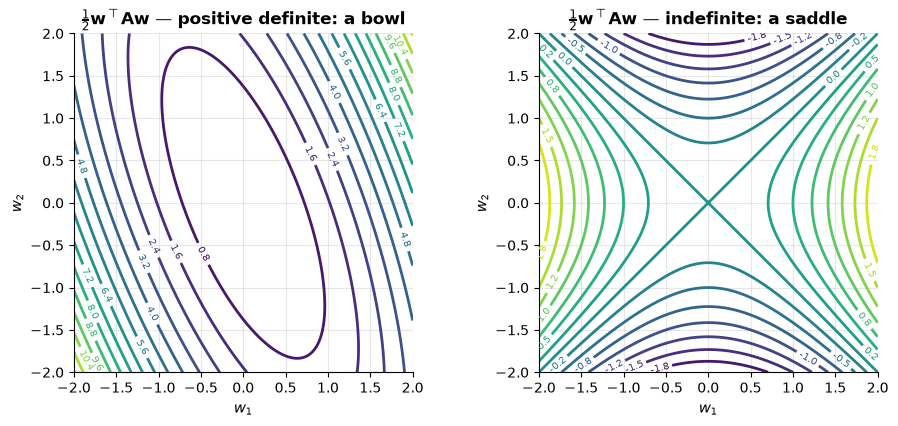

In [103]:
X_c = X - X.mean(axis=0)                  # centre the data: subtract each column's mean, (500, 2) - (2,)
Sigma = X_c.T @ X_c / (len(X) - 1)        # the covariance formula by hand (the same as np.cov above)
directions = rng.normal(size=(10000, 2))  # 10 000 random 2-D vectors
# np.einsum writes a sum over indices: each letter labels an axis, and letters missing after "->" are summed over;
# here quad[i] = sum over j, k of directions[i, j] * Sigma[j, k] * directions[i, k]
quad = np.einsum("ij,jk,ik->i", directions, Sigma, directions)     # x^T Sigma x for 10 000 random x
print(f"min of x^T Sigma x over 10 000 random directions: {quad.min():.3f}  (never negative)")
# np.linalg.eigvalsh returns only the eigenvalues of a symmetric matrix, in ascending order
print("eigenvalues of Sigma:", np.linalg.eigvalsh(Sigma).round(3))
indefinite = np.array([[1.0, 0.0], [0.0, -1.0]])
print("eigenvalues of the indefinite matrix:", np.linalg.eigvalsh(indefinite))
singular_gram = np.array([[1.0, 2.0], [2.0, 4.0]])                  # X^T X for two collinear features
print("eigenvalues of a singular Gram matrix:", np.linalg.eigvalsh(singular_gram).round(3),
      "-> after adding 0.5 I:", np.linalg.eigvalsh(singular_gram + 0.5 * np.eye(2)).round(3))

w1, w2 = np.meshgrid(np.linspace(-2, 2, 200), np.linspace(-2, 2, 200))   # each (200, 200)
W = np.stack([w1, w2], axis=-1)           # (200, 200, 2): one weight vector w per grid point
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
for ax, (name, M) in zip(axes, [("positive definite: a bowl", Sigma), ("indefinite: a saddle", indefinite)]):
    # "..." in einsum stands for any leading axes (here 200 x 200): w^T M w at every grid point -> (200, 200)
    f = 0.5 * np.einsum("...i,ij,...j->...", W, M, W)
    cs = ax.contour(w1, w2, f, levels=15, cmap="viridis")    # 15 contour lines of f, coloured by level
    ax.clabel(cs, inline=True, fontsize=7, fmt="%.1f")       # write each line's value on it, with 1 decimal
    ax.set_aspect("equal")
    ax.set_xlabel("$w_1$")
    ax.set_ylabel("$w_2$")
    # in an f-string {{ and }} produce literal braces, which the LaTeX \frac{1}{2} needs
    ax.set_title(f"$\\frac{{1}}{{2}}\\mathbf{{w}}^\\top \\mathbf{{A}} \\mathbf{{w}}$ — {name}")
plt.show()

**Example — a flat direction by hand.** The singular Gram matrix above,
$\mathbf{G} = \begin{pmatrix} 1 & 2 \\ 2 & 4 \end{pmatrix}$, is $\mathbf{X}^\top\mathbf{X}$ for two collinear features (the
second is twice the first). Along $\mathbf{v} = (2, -1)$ its quadratic form vanishes:
$\mathbf{v}^\top\mathbf{G}\mathbf{v} = g_{11}v_1^2 + 2g_{12}v_1v_2 + g_{22}v_2^2 = 4 - 8 + 4 = 0$. The
least-squares bowl is flat in that direction: moving the weights along $\mathbf{v}$ changes no
prediction, since twice the first feature column minus the second is zero. Adding
$0.5\,\mathbf{I}$ curves it up: $\mathbf{v}^\top(\mathbf{G} + 0.5\,\mathbf{I})\mathbf{v} = 0 + 0.5\,\|\mathbf{v}\|_2^2 = 0.5 \cdot 5 = 2.5 > 0$.

> **Real-life example.** A weather data set that stores the temperature both in °C and in °F has
> exactly this problem: with the intercept's column of ones, the °F column is 1.8 times the °C
> column plus 32, a combination of the other columns. The weights can then move along a flat
> direction — more weight on °C, less on °F and a shifted intercept — without changing a single
> prediction, and only a penalty such as ridge's picks one sensible split.

In [104]:
v_flat = np.array([2.0, -1.0])
# singular_gram (G) was defined in the PSD code cell above; v @ M @ v computes the quadratic form v^T M v
print("v^T G v =", v_flat @ singular_gram @ v_flat)
print("v^T (G + 0.5 I) v =", v_flat @ (singular_gram + 0.5 * np.eye(2)) @ v_flat)

v^T G v = 0.0
v^T (G + 0.5 I) v = 2.5


> **In machine learning.**
> - **Nearly collinear features make $\mathbf{X}^\top\mathbf{X}$ nearly singular**: its smallest eigenvalue is close to zero,
>   the condition number (largest over smallest eigenvalue) explodes, and the weights become unstable along the
>   flat direction (notebook 6, §9.3). Ridge regression minimises $\|\mathbf{X}\mathbf{w} - \mathbf{y}\|_2^2 + \lambda\|\mathbf{w}\|_2^2$
>   and so solves $(\mathbf{X}^\top\mathbf{X} + \lambda\mathbf{I})\mathbf{w} = \mathbf{X}^\top\mathbf{y}$, lifting every eigenvalue by
>   $\lambda$ (notebook 6, §7.1). In the demo below, a feature and its near-copy get large weights of opposite sign
>   without the penalty — only their sum, about 3, is pinned down — and about 1.5 each with $\lambda = 1$.
> - **Kernel matrices must be PSD.** A *kernel* is the similarity an SVM uses in place of a dot product; Mercer's
>   condition — every kernel matrix it produces is PSD — decides which functions qualify (notebook 11, §3.2).
> - **Gaussian densities need a positive definite covariance matrix**, since they use its inverse and its
>   determinant; `GaussianMixture` adds `reg_covar` $= 10^{-6}$ to the diagonal of each covariance matrix to
>   guarantee it (notebook 13, §5.3).

In [105]:
rng_demo = np.random.default_rng(0)   # its own seeded generator: reproducible, and the notebook's rng is left untouched
# e.g. a day's temperature read at two neighbouring weather stations (almost the same number);
# y_twins: a café's cold-drink sales on that day
base_feature = rng_demo.normal(size=100)
# two nearly identical features: the second is the first plus a tiny perturbation
X_twins = np.column_stack([base_feature, base_feature + 0.001 * rng_demo.normal(size=100)])
y_twins = 3 * base_feature + rng_demo.normal(scale=0.5, size=100)     # true combined effect 3; noise std (scale) 0.5
for ridge_lambda in [0.0, 1.0]:
    gram_twins = X_twins.T @ X_twins + ridge_lambda * np.eye(2)          # X^T X + lambda I
    w_twins = np.linalg.solve(gram_twins, X_twins.T @ y_twins)          # the (ridge) normal equations
    eig_twins = np.linalg.eigvalsh(gram_twins)
    # np.linalg.cond is the condition number, here the largest divided by the smallest eigenvalue
    print(f"lambda = {ridge_lambda:.0f}: eigenvalues {eig_twins[0]:.1e} and {eig_twins[1]:.1f}, "
          f"condition number {np.linalg.cond(gram_twins):.0e}, weights {w_twins.round(2)}")

lambda = 0: eigenvalues 4.6e-05 and 186.5, condition number 4e+06, weights [-19.39  22.38]
lambda = 1: eigenvalues 1.0e+00 and 187.5, condition number 2e+02, weights [1.48 1.49]


## 2. Calculus for optimisation

> **Key idea.** Fitting a model means choosing its weights so that a loss — one number measuring how badly the
> model fits the training data — is as small as possible. With thousands of weights we cannot try every
> combination; calculus tells us, from wherever we stand, which direction lowers the loss fastest and how steeply:
> the information every gradient-based optimiser runs on.

### 2.1 Derivatives, gradients and the chain rule

> **Key idea.** A derivative measures sensitivity: how much the output moves when you nudge the input a little.
> A function of many inputs has one such sensitivity per input; together they form the gradient, an arrow that
> points uphill — so to make a loss smaller you step the opposite way. The chain rule finds the sensitivity of a
> function built in stages by multiplying the sensitivities of the stages.

The derivative $f'(x) = \lim_{h\to 0}\frac{f(x+h) - f(x)}{h}$ is the slope of $f$ at $x$ —
the factor by which a tiny change in the input is amplified in the output. For a function
of several variables $f: \mathbb{R}^d \to \mathbb{R}$ the **gradient** collects the partial
derivatives,

$$
\nabla f(\mathbf{x}) = \Big(\frac{\partial f}{\partial x_1}, \dots, \frac{\partial f}{\partial x_d}\Big)^\top,
\qquad f(\mathbf{x} + \boldsymbol{\delta}) \approx f(\mathbf{x}) + \nabla f(\mathbf{x})^\top \boldsymbol{\delta} .
$$

The linear approximation gives the two facts optimisation lives on: the gradient points in
the direction of **steepest ascent** (the $\boldsymbol{\delta}$ of fixed length that
increases $f$ most is parallel to $\nabla f$), and at an interior minimum the gradient is
zero. For a vector-valued $\mathbf{g}: \mathbb{R}^d \to \mathbb{R}^m$ the matrix of partials
$\mathbf{J}_{ij} = \partial g_i / \partial x_j$ is the **Jacobian** — row $i$ is the gradient of output $i$, so it records how every output responds to a
nudge in every input; the matrix of second
derivatives of a scalar function, $\mathbf{H}_{ij} = \partial^2 f / \partial x_i \partial x_j$,
is the **Hessian** — the curvature, which decides whether a *stationary point* — a point where the gradient is zero — is a minimum
(all eigenvalues $> 0$), a maximum (all $< 0$) or a saddle (mixed).

The **chain rule** is how gradients of complicated functions are assembled from simple
pieces. For a composition $f(\mathbf{x}) = h(\mathbf{g}(\mathbf{x}))$,

$$
\nabla f(\mathbf{x}) = \mathbf{J}_{\mathbf{g}}(\mathbf{x})^\top\,\nabla h(\mathbf{g}(\mathbf{x})) ,
$$

i.e. multiply the Jacobians of the layers, innermost last. A neural network is a long
composition of simple layers, and *backpropagation* in neural networks is nothing but this
formula applied layer by layer, reusing intermediate results.

> **Real-life examples.**
> - *Gradient.* An online shop's weekly profit depends on the prices of its two best-selling
>   products. The gradient holds the two sensitivities — euros of profit gained per cent of price
>   increase on each — and points to the mix of small price changes that raises profit fastest; at
>   the best pair of prices both are zero.
> - *Chain rule.* Every degree colder outside raises a house's gas use by about 3 kWh a day, and
>   each kWh costs 0.10 euros, so the daily heating bill rises by 3 × 0.10 = 0.30 euros per degree
>   colder: the sensitivities of the stages multiply.

**Numerical gradient checking.** Any hand-derived gradient should be checked against a
finite-difference approximation. The central difference

$$
\frac{\partial f}{\partial x_i} \approx \frac{f(\mathbf{x} + \varepsilon\mathbf{e}_i) - f(\mathbf{x} - \varepsilon\mathbf{e}_i)}{2\varepsilon}
$$

has error $O(\varepsilon^2)$; with $\varepsilon \approx 10^{-5}$ in double precision it
agrees with the true gradient to about eight digits. It is far too slow to *train* with
($2d$ evaluations of $f$ per gradient, versus one backward pass), but it is the standard
unit test for gradient code.

In [106]:
def numerical_gradient(f, x, eps=1e-5):
    """Central-difference gradient of a scalar function f at the point x (a 1-D array).

    Returns an array shaped like x whose entry i is (f(x + eps e_i) - f(x - eps e_i)) / (2 eps).
    """
    x = np.asarray(x, dtype=float)       # accept lists too, and make sure the values are floats
    grad = np.zeros_like(x)              # an array of zeros with the same shape and dtype as x
    for i in range(len(x)):
        step = np.zeros_like(x)
        step[i] = eps                    # a small step along coordinate i only
        grad[i] = (f(x + step) - f(x - step)) / (2 * eps)
    return grad

def relative_error(g_analytic, g_numeric):
    """Relative difference ||g1 - g2|| / (||g1|| + ||g2||) of two gradients: near 0 when they agree."""
    return np.linalg.norm(g_analytic - g_numeric) / (np.linalg.norm(g_analytic) + np.linalg.norm(g_numeric))

# f(x, y) = x^2 y + sin(y): grad = (2xy, x^2 + cos(y))
# lambda defines a small unnamed function; v is the point (x, y), so v[0] = x and v[1] = y
f = lambda v: v[0] ** 2 * v[1] + np.sin(v[1])
grad_f = lambda v: np.array([2 * v[0] * v[1], v[0] ** 2 + np.cos(v[1])])
point = np.array([1.5, -0.7])
print("analytic :", grad_f(point).round(6))
print("numeric  :", numerical_gradient(f, point).round(6))
# :.1e prints in scientific notation with 1 decimal
print(f"relative error: {relative_error(grad_f(point), numerical_gradient(f, point)):.1e}")

analytic : [-2.1       3.014842]
numeric  : [-2.1       3.014842]
relative error: 4.1e-12


**Example — slope as sensitivity, and why central differences.** For $f(x) = x^3$ at $x = 1$ the slope is
$f'(1) = 3 \cdot 1^2 = 3$, so a nudge of $h = 0.01$ should change $f$ by about $3 \times 0.01 = 0.03$. Indeed
$f(1.01) - f(1) = 1.030301 - 1 = 0.030301$; the small remainder is the curvature that a straight line ignores.
The same numbers show why gradient checking uses *central* differences: the forward difference
$0.030301 / 0.01 = 3.0301$ is off by about $3h = 0.03$, the central difference
$(1.030301 - 0.970299) / 0.02 = 3.0001$ only by $h^2 = 0.0001$. Each tenfold smaller $h$ shrinks the first error
tenfold and the second a hundredfold:

In [107]:
def cube(x_val):
    """The example function f(x) = x^3; its true slope at x = 1 is 3."""
    return x_val ** 3

for h_step in [0.1, 0.01, 0.001]:
    forward = (cube(1 + h_step) - cube(1)) / h_step                  # one-sided slope estimate
    central = (cube(1 + h_step) - cube(1 - h_step)) / (2 * h_step)   # symmetric slope estimate
    # {h_step:<6} pads the number to 6 characters, left-aligned; :.1e is scientific notation with 1 decimal
    print(f"h = {h_step:<6} forward error {forward - 3:.1e}   central error {central - 3:.1e}")

h = 0.1    forward error 3.1e-01   central error 1.0e-02
h = 0.01   forward error 3.0e-02   central error 1.0e-04
h = 0.001  forward error 3.0e-03   central error 1.0e-06


**Example — a gradient and the linear approximation.** Take $f(w_1, w_2) = w_1^2 + 3w_1w_2$ at
$\mathbf{w} = (1, 2)$, where $f = 1 + 6 = 7$. Its partial derivatives are $\partial f/\partial w_1 = 2w_1 + 3w_2 = 8$
and $\partial f/\partial w_2 = 3w_1 = 3$, so $\nabla f = (8, 3)$. The step $\boldsymbol{\delta} = (0.1, 0.1)$ should
therefore raise $f$ by about $\nabla f^\top\boldsymbol{\delta} = 0.8 + 0.3 = 1.1$; the true change is
$f(1.1, 2.1) - 7 = 8.14 - 7 = 1.14$. Why is $\nabla f$ the steepest way up? By section 1.1,
$\nabla f^\top\boldsymbol{\delta} = \|\nabla f\|\,\|\boldsymbol{\delta}\|\cos\theta$: among steps of the same length the
predicted change is largest when $\boldsymbol{\delta}$ points along $\nabla f$ ($\cos\theta = 1$) and most negative
when it points the opposite way — the direction gradient descent takes.

In [108]:
def f_two(w_vec):
    """The example function f(w1, w2) = w1^2 + 3 w1 w2 at the point w_vec = (w1, w2)."""
    return w_vec[0] ** 2 + 3 * w_vec[0] * w_vec[1]

w_here, delta = np.array([1.0, 2.0]), np.array([0.1, 0.1])
grad_here = numerical_gradient(f_two, w_here)          # central differences (helper defined above)
print("gradient at (1, 2):", grad_here.round(6))
print(f"true change {f_two(w_here + delta) - f_two(w_here):.4f} | linear approximation {grad_here @ delta:.4f}")

gradient at (1, 2): [8. 3.]
true change 1.1400 | linear approximation 1.1000


**Example — the Hessian: curvature, and a saddle.** Differentiating the two partial derivatives of the same $f$
once more gives the Hessian $\mathbf{H} = \begin{pmatrix} 2 & 3 \\ 3 & 0 \end{pmatrix}$ (for instance
$\partial^2 f/\partial w_1\partial w_2 = \partial(2w_1 + 3w_2)/\partial w_2 = 3$). Adding a curvature term to the linear
approximation gives the *quadratic approximation*
$f(\mathbf{w} + \boldsymbol{\delta}) \approx f(\mathbf{w}) + \nabla f(\mathbf{w})^\top\boldsymbol{\delta} + \tfrac12\boldsymbol{\delta}^\top\mathbf{H}\boldsymbol{\delta}$,
and the extra term closes the gap the linear one left:
$\tfrac12\boldsymbol{\delta}^\top\mathbf{H}\boldsymbol{\delta} = \tfrac12(2\delta_1^2 + 6\delta_1\delta_2)$, which is
$\tfrac12(0.02 + 0.06) = 0.04$, and $1.1 + 0.04 = 1.14$ — exactly, because $f$ is quadratic. $\mathbf{H}$ is also
the Jacobian of the gradient map $\mathbf{w} \mapsto (2w_1 + 3w_2,\ 3w_1) = \mathbf{H}\mathbf{w}$, as the Jacobian of
a linear map $\mathbf{w} \mapsto \mathbf{A}\mathbf{w}$ is $\mathbf{A}$ itself. Finally, the gradient is zero only at
the origin, and there the eigenvalues of $\mathbf{H}$, $1 \pm \sqrt{10} \approx 4.16$ and $-2.16$, have mixed signs:
the origin is a saddle, so a zero gradient alone does not prove a minimum.

In [109]:
hess_two = np.array([[2.0, 3.0], [3.0, 0.0]])          # the Hessian worked out by hand
print(f"linear approximation + Hessian term: {grad_here @ delta + 0.5 * delta @ hess_two @ delta:.4f}")
print("gradient at (0, 0):", numerical_gradient(f_two, [0.0, 0.0]))
# np.linalg.eigvalsh: the eigenvalues of a symmetric matrix, in ascending order
print("Hessian eigenvalues:", np.linalg.eigvalsh(hess_two).round(2))

linear approximation + Hessian term: 1.1400
gradient at (0, 0): [0. 0.]
Hessian eigenvalues: [-2.16  4.16]


**Example — the chain rule on one neuron (backpropagation in miniature).** A single "neuron" scores an input as
$z = \mathbf{w}^\top\mathbf{x} + b$ and turns the score into a probability with the sigmoid
$\sigma(z) = 1/(1 + e^{-z})$ (explained in section 4.3); this is logistic regression (notebook 7, §1.3). For an
example with label $y = 1$ the log loss is $L = -\ln p$ with $p = \sigma(z)$. Take $\mathbf{x} = (1, 2)$,
$\mathbf{w} = (0.5, -0.25)$ and $b = 0$.

- *Forward pass*, from the inputs to the loss: $z = 0.5 - 0.5 = 0$, $p = \sigma(0) = 0.5$ and
  $L = -\ln 0.5 \approx 0.693$.
- *Backward pass*, from the loss back to the weights, one link of the chain at a time:
  $\partial L/\partial p = -1/p = -2$ and $\partial p/\partial z = p(1 - p) = 0.25$ (the sigmoid's derivative), hence
  $\partial L/\partial z = -2 \times 0.25 = -0.5$, which equals $p - y$. Finally $\partial z/\partial\mathbf{w} = \mathbf{x}$
  and $\partial z/\partial b = 1$, so $\nabla_\mathbf{w} L = -0.5\,\mathbf{x} = (-0.5, -1)$ and $\partial L/\partial b = -0.5$.

The backward pass reuses $p$ from the forward pass and computes $\partial L/\partial z$ once for all the weights;
that reuse is why backpropagation costs only a small multiple of one forward pass, however many weights there are.

In [110]:
# e.g. a machine with 1 overheating alarm this week and 2 maintenance visits this year (x) that broke
# down (y = 1); the weights add 0.5 per alarm and subtract 0.25 per maintenance visit
x_one, y_one = np.array([1.0, 2.0]), 1          # one example: two feature values and its label
params_one = np.array([0.5, -0.25, 0.0])        # the parameters (w1, w2, b)

def neuron_log_loss(params):
    """Log loss of one sigmoid neuron with weights params[:2] and bias params[2] on the example (x_one, y_one)."""
    prob = 1 / (1 + np.exp(-(params[:2] @ x_one + params[2])))        # forward pass; np.exp(t) is e^t
    return -(y_one * np.log(prob) + (1 - y_one) * np.log(1 - prob))   # np.log is ln; with y = 1 this is -ln p

# forward pass, keeping the intermediate results
z_one = params_one[:2] @ x_one + params_one[2]
p_one = 1 / (1 + np.exp(-z_one))
# backward pass: multiply the local derivatives, from the loss back to the parameters
dloss_dp = -y_one / p_one + (1 - y_one) / (1 - p_one)   # derivative of the log loss with respect to p
dp_dz = p_one * (1 - p_one)                             # derivative of the sigmoid
dloss_dz = dloss_dp * dp_dz                             # chain rule; equals p - y
grad_backprop = np.append(dloss_dz * x_one, dloss_dz)   # dz/dw = x and dz/db = 1; np.append joins them into one array
print(f"forward pass: z = {z_one}, p = {p_one}, loss = {neuron_log_loss(params_one):.3f}")
print("backpropagation gradient (w1, w2, b):", grad_backprop)
print("numerical gradient                  :", numerical_gradient(neuron_log_loss, params_one).round(6))

forward pass: z = 0.0, p = 0.5, loss = 0.693
backpropagation gradient (w1, w2, b): [-0.5 -1.  -0.5]
numerical gradient                  : [-0.5 -1.  -0.5]


> **In machine learning.**
> - **Training follows the gradient.** Gradient descent (section 2.3) moves every weight a small step against the
>   gradient, and gradient-based solvers stop where it is (almost) zero. Notebook 7, §2.3 trains logistic
>   regression this way from scratch, and notebook 11, §2.3 a linear SVM (with sub-gradients).
> - **Linear versus quadratic approximation.** Gradient descent trusts the linear approximation, which holds only
>   for small steps — hence the learning-rate limit of section 2.3. Newton's method trusts the quadratic one and
>   rescales the gradient by the inverse Hessian (notebook 7, §2.4); `LogisticRegression`'s default `lbfgs` solver
>   approximates that inverse.
> - **The neuron is logistic regression on one example.** Averaged over $n$ examples its gradient
>   $(p - y)\mathbf{x}$ becomes $\frac1n\mathbf{X}^\top(\mathbf{p} - \mathbf{y})$ (notebook 7, §2.2); the
>   $\mathbf{X}^\top$ is the transposed Jacobian of $\mathbf{w} \mapsto \mathbf{X}\mathbf{w}$. Neural networks (not
>   covered in this course) chain many such neurons; backpropagation repeats the backward pass layer by layer.

### 2.2 The gradient of the least-squares loss, derived

> **Key idea.** To find the best weights of a linear regression, write the loss as a function of the weights,
> differentiate it, and set the result to zero. The gradient that comes out reads naturally: for each feature it adds
> up "residual × feature value" over the data, so a weight is pushed hardest when its feature lines up with the
> current errors.

The loss of linear regression is $\mathcal{L}(\mathbf{w}) = \|\mathbf{X}\mathbf{w} -
\mathbf{y}\|_2^2$. Expand the squared norm as a dot product:

$$
\mathcal{L}(\mathbf{w}) = (\mathbf{X}\mathbf{w} - \mathbf{y})^\top(\mathbf{X}\mathbf{w} - \mathbf{y})
= \mathbf{w}^\top\mathbf{X}^\top\mathbf{X}\mathbf{w} - 2\,\mathbf{y}^\top\mathbf{X}\mathbf{w} + \mathbf{y}^\top\mathbf{y}.
$$

Two matrix-calculus rules do the rest: $\nabla_\mathbf{w}(\mathbf{w}^\top\mathbf{A}\mathbf{w})
= 2\mathbf{A}\mathbf{w}$ for symmetric $\mathbf{A}$, and $\nabla_\mathbf{w}(\mathbf{c}^\top\mathbf{w})
= \mathbf{c}$. Hence

$$
\nabla_\mathbf{w}\mathcal{L} = 2\mathbf{X}^\top\mathbf{X}\mathbf{w} - 2\mathbf{X}^\top\mathbf{y}
= 2\,\mathbf{X}^\top(\mathbf{X}\mathbf{w} - \mathbf{y}),
\qquad
\mathbf{H} = \nabla^2_\mathbf{w}\mathcal{L} = 2\,\mathbf{X}^\top\mathbf{X} \succeq 0 .
$$

> **Real-life example.** A rent model that under-predicts large flats has negative residuals
> (prediction minus rent) exactly where the standardised floor area is large and positive. The
> floor-area entry of the gradient, the sum of "residual × floor area", is then clearly negative, so
> a step against the gradient raises the floor-area weight — just what the errors call for.

Setting the gradient to zero gives the normal equations of section 1.3; the PSD Hessian
says the loss is convex, so that solution is the global minimum. (Alternatively, apply the
chain rule with $\mathbf{g}(\mathbf{w}) = \mathbf{X}\mathbf{w} - \mathbf{y}$, whose Jacobian
is $\mathbf{X}$, and $h(\mathbf{r}) = \|\mathbf{r}\|^2$, whose gradient is $2\mathbf{r}$:
$\nabla\mathcal{L} = \mathbf{X}^\top \cdot 2\mathbf{r}$.) Let us check it numerically.

In [111]:
n, d = 50, 4
# e.g. 50 flats described by 4 standardised features and, in y_ls, their monthly rents
X_ls = rng.normal(size=(n, d))                                     # (50, 4) random design matrix
y_ls = X_ls @ np.array([1.0, -2.0, 0.5, 3.0]) + rng.normal(0, 0.5, n)   # known true weights plus noise (std 0.5)

loss = lambda w: np.sum((X_ls @ w - y_ls) ** 2)          # ||X w - y||^2
grad_loss = lambda w: 2 * X_ls.T @ (X_ls @ w - y_ls)     # the gradient derived above: 2 X^T (X w - y)
w0 = rng.normal(size=d)                                  # an arbitrary point at which to check the gradient
print(f"relative error of the analytic gradient: {relative_error(grad_loss(w0), numerical_gradient(loss, w0)):.1e}")
w_star = np.linalg.solve(X_ls.T @ X_ls, X_ls.T @ y_ls)   # solve the normal equations X^T X w = X^T y
# tiny negative round-off values print as -0. after rounding
print("gradient at the normal-equation solution:", grad_loss(w_star).round(8), "(zero: it is a stationary point)")
print("Hessian eigenvalues (all positive -> strictly convex):", np.linalg.eigvalsh(2 * X_ls.T @ X_ls).round(2))

relative error of the analytic gradient: 1.8e-11
gradient at the normal-equation solution: [0. 0. 0. 0.] (zero: it is a stationary point)
Hessian eigenvalues (all positive -> strictly convex): [ 71.05 101.48 125.69 142.31]


**Example — the formula on two data points.** One feature, no intercept, two points $(x, y) = (1, 1)$ and
$(2, 3)$, so $\mathbf{X} = (1, 2)^\top$ is a single column and $\mathbf{y} = (1, 3)$. At $w = 1$ the predictions are
$(1, 2)$, the residuals $\mathbf{X}w - \mathbf{y} = (0, -1)$ and the loss is $0^2 + (-1)^2 = 1$. The formula gives
$\nabla\mathcal{L} = 2\mathbf{X}^\top(\mathbf{X}w - \mathbf{y}) = 2\,(1 \cdot 0 + 2 \cdot (-1)) = -4$: the loss falls if
$w$ grows. Setting the gradient to zero, $\mathbf{X}^\top\mathbf{X}\,w = \mathbf{X}^\top\mathbf{y}$ reads $5w = 7$, so
$w^\star = 1.4$, and the Hessian $2\mathbf{X}^\top\mathbf{X} = 10 > 0$ confirms a minimum.

The first rule can be checked on the function of section 2.1: $w_1^2 + 3w_1w_2 = \mathbf{w}^\top\mathbf{A}\mathbf{w}$ with
the symmetric $\mathbf{A} = \begin{pmatrix} 1 & 1.5 \\ 1.5 & 0 \end{pmatrix}$ (half of the $3w_1w_2$ in each off-diagonal
entry), and $2\mathbf{A}\mathbf{w} = (2w_1 + 3w_2,\ 3w_1)$ is the gradient found there by hand.

In [112]:
X_two, y_two = np.array([[1.0], [2.0]]), np.array([1.0, 3.0])   # the two data points; X is a (2, 1) column
w_at_one = np.array([1.0])
print("gradient at w = 1:", 2 * X_two.T @ (X_two @ w_at_one - y_two),
      "| w* =", np.linalg.solve(X_two.T @ X_two, X_two.T @ y_two), "| Hessian:", 2 * X_two.T @ X_two)

gradient at w = 1: [-4.] | w* = [1.4] | Hessian: [[10.]]


> **In machine learning.**
> - **Two ways to use the gradient.** `LinearRegression` solves "gradient $= \mathbf{0}$" directly with a
>   least-squares factorisation (notebook 6, §2.1); gradient descent walks downhill instead (notebook 6, §2.2, and
>   section 2.3). The same rules plus $\nabla_\mathbf{w}(\lambda\mathbf{w}^\top\mathbf{w}) = 2\lambda\mathbf{w}$ give ridge
>   regression's closed form, $(\mathbf{X}^\top\mathbf{X} + \lambda\mathbf{I})\,\mathbf{w} = \mathbf{X}^\top\mathbf{y}$
>   (notebook 6, §7.1).
> - **Residuals drive gradient boosting.** Each new tree is fitted to the negative gradient of the loss with respect
>   to the current predictions — for the squared error, simply the residuals (notebook 10, §5.1).
> - **Mean or sum changes what `alpha` means.** scikit-learn calls the penalty strength $\lambda$ `alpha`. Its
>   `Lasso` averages the squared errors (its objective starts with $\frac{1}{2n}$), `Ridge` sums them. Listing every row twice therefore leaves a lasso fit unchanged,
>   while ridge needs twice the `alpha` for the same fit.

### 2.3 Gradient descent

> **Key idea.** Gradient descent is walking downhill in fog: you only feel the slope under your feet, so you take a
> step in the steepest downhill direction, feel again, and repeat. The learning rate is the length of each step —
> too short and you crawl, too long and you overshoot the valley floor, and can even climb out of the valley.

Since $-\nabla f$ is the direction of steepest descent, the simplest way to minimise a
differentiable function is to take repeated small steps in that direction:

1. Start from an initial guess $\mathbf{w}^{(0)}$.
2. Repeat for $t = 0, 1, 2, \dots$: $\quad \mathbf{w}^{(t+1)} = \mathbf{w}^{(t)} - \eta\,\nabla f(\mathbf{w}^{(t)})$.
3. Stop when the gradient is tiny, the loss stops improving, or a budget is exhausted.

The **learning rate** $\eta > 0$ is the single most important hyper-parameter in
optimisation. For the quadratic $f(\mathbf{w}) = \frac{1}{2}\mathbf{w}^\top\mathbf{A}\mathbf{w}$
with $\mathbf{A} \succ 0$ we can analyse it exactly: the update is $\mathbf{w}^{(t+1)} =
(\mathbf{I} - \eta\mathbf{A})\mathbf{w}^{(t)}$, so along each eigenvector of $\mathbf{A}$ the
error is multiplied by $1 - \eta\lambda_i$ per step. Convergence therefore requires
$|1 - \eta\lambda_i| < 1$ for every eigenvalue, i.e.

$$
0 < \eta < \frac{2}{\lambda_{\max}},
$$

and the *slowest* direction, $\lambda_{\min}$, converges at rate $1 - \eta\lambda_{\min}$.
With the largest safe step, the number of iterations needed scales with the **condition
number** $\kappa = \lambda_{\max}/\lambda_{\min}$. Let us watch all of this on a bowl with
$\mathbf{A} = \operatorname{diag}(1, 25)$, $\kappa = 25$, $2/\lambda_{\max} = 0.08$.

> **History.** Gradient descent was proposed by Augustin-Louis Cauchy in 1847 as a method
> for solving systems of equations; its stochastic variant (Robbins & Monro, 1951) is the
> engine of modern deep learning (Bottou, Curtis & Nocedal, 2018).

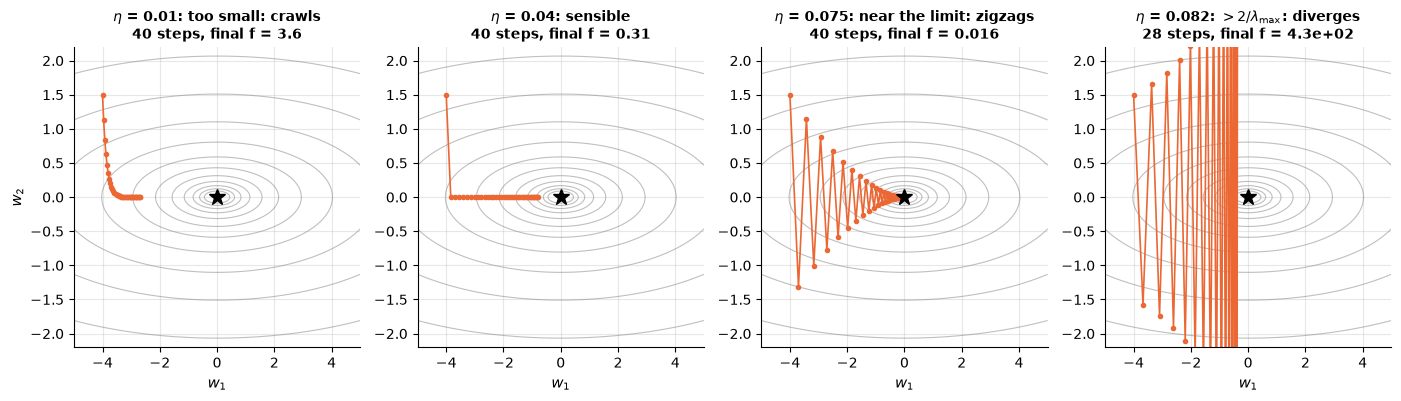

In [113]:
def gradient_descent(grad, w0, eta, n_steps):
    """Plain gradient descent; returns the trajectory as an array of shape (n_steps + 1, d).

    grad     function returning the gradient at a point
    w0       starting point (length d)
    eta      learning rate (step size)
    n_steps  number of updates w <- w - eta * grad(w); row 0 of the result is w0, row t the point after t steps
    """
    path = [np.asarray(w0, dtype=float)]
    for _ in range(n_steps):                               # _ : the loop counter itself is not needed
        path.append(path[-1] - eta * grad(path[-1]))       # path[-1] is the current (last) point
    return np.array(path)

A_bowl = np.diag([1.0, 25.0])             # eigenvalues 1 and 25: condition number 25
f_bowl = lambda w: 0.5 * w @ A_bowl @ w   # f(w) = 1/2 w^T A w
grad_bowl = lambda w: A_bowl @ w          # its gradient is A w
w_start = np.array([-4.0, 1.5])

g1, g2 = np.meshgrid(np.linspace(-5, 5, 200), np.linspace(-2.2, 2.2, 200))
F = 0.5 * (A_bowl[0, 0] * g1 ** 2 + A_bowl[1, 1] * g2 ** 2)   # f on the whole grid at once (A is diagonal)
etas = [(0.01, "too small: crawls"), (0.04, "sensible"), (0.075, "near the limit: zigzags"), (0.082, "$> 2/\\lambda_{\\max}$: diverges")]

fig, axes = plt.subplots(1, 4, figsize=(17, 3.9))
for ax, (eta, label) in zip(axes, etas):
    path = gradient_descent(grad_bowl, w_start, eta, n_steps=40)
    # np.all(..., axis=1) is True for the rows (points) whose coordinates are all inside (-6, 6)
    path = path[np.all(np.abs(path) < 6, axis=1)]            # drop the part of a diverging path that is far off screen
    # np.logspace(-1, 2, 12): 12 levels from 10^-1 to 10^2, evenly spaced on a log scale
    ax.contour(g1, g2, F, levels=np.logspace(-1, 2, 12), colors="gray", alpha=0.5, linewidths=0.8)
    ax.plot(path[:, 0], path[:, 1], marker="o", ms=3, lw=1.2, color=PALETTE[1])
    ax.plot(0, 0, marker="*", ms=12, color="black")          # the minimum
    ax.set_xlim(-5, 5)
    ax.set_ylim(-2.2, 2.2)
    # :.2g prints 2 significant digits, switching to scientific notation for very large or small values
    ax.set_title(f"$\\eta$ = {eta}: {label}\n{len(path) - 1} steps, final f = {f_bowl(path[-1]):.2g}", fontsize=10)
    ax.set_xlabel("$w_1$")
axes[0].set_ylabel("$w_2$")
plt.show()

Along $w_2$ (eigenvalue 25) the step is either tiny, well chosen, oscillating, or
explosive; along $w_1$ (eigenvalue 1) progress is slow in every panel because $\eta$ is
capped by the steep direction. Conditioning is the practical reason why **feature scaling**
matters for gradient-based models: features on different scales produce a loss surface
that is elongated along the small-scale feature, $\kappa$ becomes huge, and gradient
descent crawls. Compare the same optimiser on a well-conditioned and an ill-conditioned
bowl, each with its own near-optimal learning rate ($\eta^\star = 2/(\lambda_{\max} +
\lambda_{\min})$ balances the fastest and slowest directions):

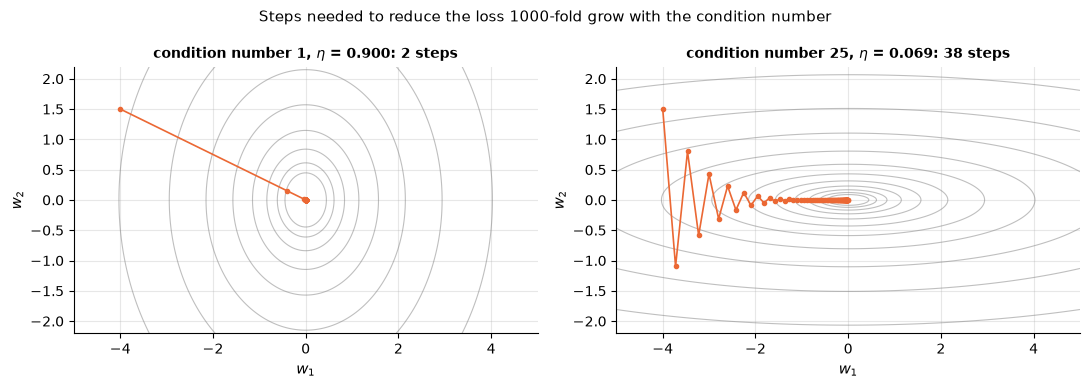

In [114]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.9))
for ax, kappa in zip(axes, [1, 25]):
    A_k = np.diag([1.0, float(kappa)])                         # eigenvalues 1 and kappa
    eta = 0.9 * 2 / (kappa + 1)                                # 90% of the optimal step for this problem
    path = gradient_descent(lambda w: A_k @ w, w_start, eta, n_steps=80)
    losses = 0.5 * np.einsum("ti,ij,tj->t", path, A_k, path)   # the loss 1/2 w^T A w at every step t -> (81,)
    # argmax of a True/False array is the index of the first True: the first step whose loss is below
    # 1/1000 of the starting loss; if that never happens, report the full 80 steps
    n_needed = int(np.argmax(losses < 1e-3 * losses[0])) if np.any(losses < 1e-3 * losses[0]) else 80
    Fk = 0.5 * (g1 ** 2 + kappa * g2 ** 2)
    ax.contour(g1, g2, Fk, levels=np.logspace(-1, 2, 12), colors="gray", alpha=0.5, linewidths=0.8)
    ax.plot(path[:, 0], path[:, 1], marker="o", ms=3, lw=1.2, color=PALETTE[1])
    ax.set_xlim(-5, 5)
    ax.set_ylim(-2.2, 2.2)
    ax.set_title(f"condition number {kappa}, $\\eta$ = {eta:.3f}: {n_needed} steps", fontsize=10)
    ax.set_xlabel("$w_1$")
    ax.set_ylabel("$w_2$")
fig.suptitle("Steps needed to reduce the loss 1000-fold grow with the condition number", fontsize=11)
plt.tight_layout()
plt.show()

**Example — the learning rate in one dimension.** For $f(w) = w^2$ the gradient is $2w$, so a step gives
$w \leftarrow w - \eta \cdot 2w = (1 - 2\eta)\,w$: each step multiplies $w$ by $1 - 2\eta$. From $w = 1$,
$\eta = 0.1$ gives $0.8, 0.64, 0.512, \dots$ (steady progress); $\eta = 0.5$ reaches the minimum in one step;
$\eta = 0.9$ gives $-0.8, 0.64, -0.512, \dots$ (zigzags inwards); and $\eta = 1.1$ gives $-1.2, 1.44, -1.728, \dots$
(diverges). The curvature is $f'' = 2$, so the rule $\eta < 2/\lambda_{\max}$ reads $\eta < 1$ — exactly where
$|1 - 2\eta|$ drops below 1 — and the best step $2/(\lambda_{\max} + \lambda_{\min})$ is $0.5$.

In [115]:
for eta_demo in [0.1, 0.5, 0.9, 1.1]:
    # gradient_descent (defined above) with the gradient 2w of f(w) = w^2: four steps from w = 1;
    # [:, 0] keeps the single coordinate of every point
    iterates = gradient_descent(lambda w_vec: 2 * w_vec, [1.0], eta_demo, n_steps=4)[:, 0]
    print(f"eta = {eta_demo}:", iterates.round(4))

eta = 0.1: [1.     0.8    0.64   0.512  0.4096]
eta = 0.5: [1. 0. 0. 0. 0.]
eta = 0.9: [ 1.     -0.8     0.64   -0.512   0.4096]
eta = 1.1: [ 1.     -1.2     1.44   -1.728   2.0736]


**Mean versus sum.** Machine-learning code usually minimises the *mean* squared error
$\frac1n\|\mathbf{X}\mathbf{w} - \mathbf{y}\|_2^2$, whose gradient $\frac2n\mathbf{X}^\top(\mathbf{X}\mathbf{w} - \mathbf{y})$
is the form notebook 6 uses. Dividing by $n$ moves neither the minimum nor the direction of the gradient, but it
rescales the gradient and the Hessian, and with them the usable learning rate. Listing the two data points of section 2.2 twice
doubles the summed loss's gradient at $w = 1$ (from $-4$ to $-8$) and its Hessian (from 10 to 20), so its largest
stable learning rate $2/\lambda_{\max}$ halves, from 0.2 to 0.1; the mean keeps gradient $-2$,
Hessian 5 and limit 0.4 however many copies there are. With a mean, one learning rate serves any $n$.

In [116]:
# X_two, y_two, w_at_one: from the two-point code cell of section 2.2; the second pair lists both points twice
# (np.vstack stacks arrays vertically, np.concatenate joins 1-D arrays end to end)
for X_rows, y_rows in [(X_two, y_two), (np.vstack([X_two, X_two]), np.concatenate([y_two, y_two]))]:
    n_rows = len(y_rows)
    grad_sum = (2 * X_rows.T @ (X_rows @ w_at_one - y_rows)).item()   # .item(): the one entry as a plain number
    hess_sum = (2 * X_rows.T @ X_rows).item()                         # Hessian of the summed loss (1 x 1 here)
    # the mean divides gradient and Hessian by n; the largest stable learning rate is 2 / Hessian
    print(f"{n_rows} rows | sum: gradient {grad_sum:.0f}, Hessian {hess_sum:.0f}, eta < {2 / hess_sum:.2f} | "
          f"mean: gradient {grad_sum / n_rows:.0f}, Hessian {hess_sum / n_rows:.0f}, eta < {2 * n_rows / hess_sum:.2f}")

2 rows | sum: gradient -4, Hessian 10, eta < 0.20 | mean: gradient -2, Hessian 5, eta < 0.40
4 rows | sum: gradient -8, Hessian 20, eta < 0.10 | mean: gradient -2, Hessian 5, eta < 0.40


> **In machine learning.**
> - **Learning rates are everywhere:** `eta0` and the `learning_rate` schedule of `SGDRegressor` and
>   `SGDClassifier` (stochastic gradient descent, explained below), the `learning_rate` of gradient boosting (notebook 10, §5.4) and of t-SNE (notebook 14, §9.4).
>   For least squares the safe range is known exactly: notebook 6, §2.3 computes it for the diabetes data and
>   watches gradient descent diverge just above it.
> - **Feature scaling fixes conditioning.** For three churn features — tenure (months), total charges (currency
>   units) and support tickets (counts) — the cell below finds a condition number of about 2.5 million
>   for $\mathbf{X}^\top\mathbf{X}$ of the centred raw features, and 11.4 after standardising each column (notebook 4,
>   §4.1). As the number of steps grows in proportion to $\kappa$, standardising cuts the work of gradient descent
>   here more than 200 000-fold.
> - **Standardising fixes units, not correlation.** The $\kappa$ of 11.4 that remains comes from correlated
>   features: tenure and total charges grow together (notebook 6, §4.2).

In [117]:
# load_churn (imported in the setup cell) returns the cleaned customer table as a DataFrame;
# keep three columns in very different units and drop the rows with a missing value (.dropna())
churn_cols = load_churn()[["tenure_months", "total_charges", "support_tickets"]].dropna()
churn_array = churn_cols.to_numpy()                                  # the DataFrame as a (n, 3) NumPy array
# axis=0: one mean (or standard deviation) per column; centring makes the two versions differ only in scale
churn_centred = churn_array - churn_array.mean(axis=0)
churn_standardised = churn_centred / churn_centred.std(axis=0)       # every column: mean 0, standard deviation 1
# dict(zip(names, values)) pairs each column name with its value; .tolist() gives plain floats for a tidy printout
print("standard deviations:", dict(zip(churn_cols.columns, churn_centred.std(axis=0).round(2).tolist())))
for version, feats in [("raw (centred)", churn_centred), ("standardised", churn_standardised)]:
    # np.linalg.cond: largest / smallest singular value; for the symmetric PSD X^T X that is lambda_max / lambda_min;
    # the format :,.1f prints commas as thousands separators and one decimal
    print(f"{version:13s}: condition number of X^T X = {np.linalg.cond(feats.T @ feats):,.1f}")

standard deviations: {'tenure_months': 20.58, 'total_charges': 1733.17, 'support_tickets': 1.16}
raw (centred): condition number of X^T X = 2,461,696.4
standardised : condition number of X^T X = 11.4


**Stochastic and mini-batch gradient descent.** The gradient of a mean loss is an average over all $n$ rows, so one
exact step needs a full pass over the data — slow when $n$ runs into millions. Like an opinion poll, a small random
*mini-batch* of rows (typically 32–512) estimates that average well, and *stochastic* gradient descent (SGD) uses a
single random row per step: each step is noisy but up to $n$ times cheaper. In the two-point example of section 2.2
at $w = 1$, the rows' own gradients $2x_i(wx_i - y_i)$ are $0$ and $-4$: each alone is wrong, but a randomly chosen
one is right *on average*, $(0 - 4)/2 = -2$. At the optimum $w^\star = 1.4$ they are $0.8$ and $-0.8$, which cancel
on average but not individually. So with a fixed learning rate SGD keeps jumping around the optimum, and the
learning rate must shrink over time for it to settle (Robbins & Monro, 1951).

> **Real-life example.** A video-streaming service logs millions of plays a day and predicts whether
> a user will watch a recommended film to the end. A full pass over months of plays for every single
> step would be far too slow, so it steps on mini-batches of a few hundred randomly drawn plays —
> each a noisy but unbiased estimate of the full gradient — and can keep learning as new plays
> arrive.

> **In machine learning.**
> - **Linear models on large or streaming data.** `SGDRegressor` and `SGDClassifier` fit linear models by SGD and
>   shrink the learning rate over time by default; with `partial_fit` they learn from data that arrive in chunks or
>   do not fit in memory (notebook 18, §9). Notebook 6, §2.2 implements batch, mini-batch and stochastic gradient
>   descent from scratch.
> - **The same idea elsewhere:** `MiniBatchKMeans` (notebook 13, §2.4) and Pegasos, the stochastic sub-gradient
>   method for linear SVMs, whose step shrinks like $1/t$ (notebook 11, §2.3). Momentum (exercise 6; t-SNE's optimiser, notebook 14, §5.2) and the
>   per-weight steps of Adam (neural networks) refine the update.
>
> Below, on the data of section 2.2, batch gradient descent reproduces the normal-equation weights, SGD with a
> decaying learning rate gets within about 0.003 of them, and SGD with a constant one still jumps around after 200
> passes (third weight 0.383 instead of 0.495).

In [118]:
from sklearn.linear_model import SGDRegressor   # linear regression fitted by stochastic gradient descent

def grad_mse_ls(weights):
    """Gradient (2/n) X^T (X w - y) of the mean squared error on X_ls, y_ls (section 2.2) at the point weights."""
    return 2 / len(y_ls) * X_ls.T @ (X_ls @ weights - y_ls)

# batch gradient descent: all 50 rows in every step; eta = half the stable limit 2 / lambda_max of the mean loss
eta_safe = 1 / np.linalg.eigvalsh(2 / len(y_ls) * X_ls.T @ X_ls).max()
w_batch = gradient_descent(grad_mse_ls, np.zeros(X_ls.shape[1]), eta_safe, n_steps=100)[-1]   # [-1]: the final point
fits = [("normal equations (w_star)", w_star), ("batch GD, 100 steps", w_batch)]   # w_star: section 2.2's code cell
# SGD, one row per update. penalty=None: plain least squares; fit_intercept=False: these data have no intercept;
# max_iter=200 passes over the data; tol=None: no early stopping; random_state fixes the order of the rows;
# learning_rate="constant" keeps eta at eta0, "invscaling" (the default) decays it as eta0 / t^0.25 (t counts updates);
# .fit(X, y) runs the optimiser on the data and returns the fitted model
for schedule, sgd_label in [("constant", "SGD, constant eta"), ("invscaling", "SGD, decaying eta")]:
    sgd_model = SGDRegressor(penalty=None, fit_intercept=False, learning_rate=schedule, eta0=0.05,
                             max_iter=200, tol=None, random_state=RANDOM_STATE).fit(X_ls, y_ls)
    fits.append((sgd_label, sgd_model.coef_))          # coef_: the fitted weights
for fit_label, fit_weights in fits:
    print(f"{fit_label:26s}:", fit_weights.round(3))   # :26s pads the label to 26 characters

normal equations (w_star) : [ 1.079 -2.076  0.495  3.046]
batch GD, 100 steps       : [ 1.079 -2.076  0.495  3.046]
SGD, constant eta         : [ 1.12  -2.022  0.383  3.016]
SGD, decaying eta         : [ 1.08  -2.073  0.492  3.048]


### 2.4 Non-convex functions: local minima and the role of initialisation

> **Key idea.** A non-convex loss is a landscape with several valleys. Walking downhill takes you to the bottom of
> whichever valley you started in — a *local* minimum — which need not be the deepest one, the *global* minimum.
> There are also flat spots that are not valley floors: a *saddle point* is like a mountain pass, downhill in one
> direction and uphill in another.

Real objectives — neural-network losses, $k$-means, matrix factorisation — are not bowls.
Himmelblau's function, $f(x, y) = (x^2 + y - 11)^2 + (x + y^2 - 7)^2$, is a standard test
case with four global minima (all with $f = 0$), a local maximum in the middle and saddle
points between the basins. Gradient descent from different starting points ends in
different minima: *which* solution you get depends on the initialisation. That is a fact
of life for $k$-means, whose clusters depend on the starting centres (notebook 13, §2.3, and the demo below),
for Gaussian mixtures fitted by EM (notebook 13, §5.2) and for deep learning. The remedies are restarts from
several starting points, keeping the best result, and smarter initialisation such as $k$-means++; in deep
learning, careful initialisation and momentum (exercise 6), which also helps with the zigzagging above, are
the usual ones.

> **Real-life example.** A retail chain chooses sites for 4 warehouses by running $k$-means on the
> map positions of its 500 shops. From unlucky starting points the algorithm can settle with two
> warehouses in the same city and a single one serving two distant cities: a local minimum, where
> moving any one warehouse a little makes things worse, yet the total squared distance is far above
> that of the best layout.

gradient check: relative error 2.0e-11


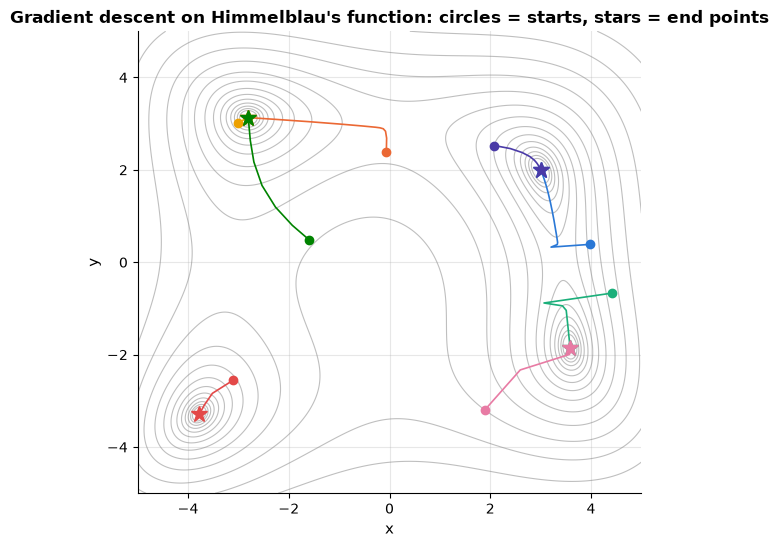

distinct minima reached: [(-3.78, -3.28), (-2.81, 3.13), (3.0, 2.0), (3.58, -1.85)]


In [119]:
def himmelblau(w):
    """Himmelblau's function f(x, y) = (x^2 + y - 11)^2 + (x + y^2 - 7)^2 at w = (x, y).

    x and y may also be whole grids of the same shape, which is how the contour plot below evaluates it.
    """
    x, y = w
    return (x ** 2 + y - 11) ** 2 + (x + y ** 2 - 7) ** 2

def grad_himmelblau(w):
    """Analytic gradient (df/dx, df/dy) of Himmelblau's function at w = (x, y), as a length-2 array."""
    x, y = w
    return np.array([4 * x * (x ** 2 + y - 11) + 2 * (x + y ** 2 - 7),
                     2 * (x ** 2 + y - 11) + 4 * y * (x + y ** 2 - 7)])

print(f"gradient check: relative error {relative_error(grad_himmelblau([1.0, 2.0]), numerical_gradient(himmelblau, [1.0, 2.0])):.1e}")

hx, hy = np.meshgrid(np.linspace(-5, 5, 300), np.linspace(-5, 5, 300))
H = himmelblau((hx, hy))                         # pass the two grids as one tuple -> f on the whole (300, 300) grid
starts = rng.uniform(-4.5, 4.5, size=(8, 2))     # 8 random starting points, uniform in the square [-4.5, 4.5)^2
fig, ax = plt.subplots(figsize=(6.5, 6))
ax.contour(hx, hy, H, levels=np.logspace(0, 3, 15), colors="gray", alpha=0.5, linewidths=0.8)
found = []
for i, w0 in enumerate(starts):
    path = gradient_descent(grad_himmelblau, w0, eta=0.01, n_steps=300)
    ax.plot(path[:, 0], path[:, 1], lw=1.2, color=PALETTE[i % len(PALETTE)])   # % wraps the index around the palette
    ax.plot(*path[0], marker="o", color=PALETTE[i % len(PALETTE)])            # *path[0] unpacks the start into x, y
    ax.plot(*path[-1], marker="*", ms=12, color=PALETTE[i % len(PALETTE)])
    # the end point rounded to 2 decimals, as a tuple of plain floats so that set() below can remove duplicates
    found.append(tuple(float(v) for v in path[-1].round(2)))
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Gradient descent on Himmelblau's function: circles = starts, stars = end points")
plt.show()
print("distinct minima reached:", sorted(set(found)))

**Example — a worse local minimum.** Himmelblau's four minima are equally deep, so they cannot show the difference
between local and global. The function $g(x) = x^4 - 3x^2 + x$ (drawn in section 2.5) can: its slope
$g'(x) = 4x^3 - 6x + 1$ is zero at $x \approx -1.30$, where $g \approx -3.51$ (the global minimum), at $x \approx 1.13$,
where $g \approx -1.07$ (a local minimum), and at a local maximum in between. Gradient descent from $x = 2$ stops in
the worse minimum; from $x = -2$ it finds the better one.

In [120]:
def g_slope(x_vec):
    """Derivative g'(x) = 4x^3 - 6x + 1 of g(x) = x^4 - 3x^2 + x."""
    return 4 * x_vec ** 3 - 6 * x_vec + 1

for x_start in [2.0, -2.0]:
    # gradient_descent (section 2.3) on g; [-1, 0] is the single coordinate of the final point
    x_end = gradient_descent(g_slope, [x_start], eta=0.01, n_steps=500)[-1, 0]
    # :+.0f prints the sign and no decimals
    print(f"start x = {x_start:+.0f}: ends at x = {x_end:.2f}, g = {x_end ** 4 - 3 * x_end ** 2 + x_end:.2f}")

start x = +2: ends at x = 1.13, g = -1.07
start x = -2: ends at x = -1.30, g = -3.51


**Example — a saddle point.** "Factorise" the number 4 by minimising $f(u, v) = (4 - uv)^2$: every point with
$uv = 4$, such as $(2, 2)$ or $(1, 4)$, is a global minimum. At the origin both partial derivatives, $-2v(4 - uv)$
and $-2u(4 - uv)$, are zero, but the Hessian there is $\begin{pmatrix} 0 & -8 \\ -8 & 0 \end{pmatrix}$, with
eigenvalues $\pm 8$: a saddle. Gradient descent started exactly at $(0, 0)$ never moves. Started near it, it escapes
along the downhill direction $u = v$, where each step with $\eta = 0.01$ multiplies the distance from the saddle by
about $1 + 8\eta = 1.08$ — so every tenfold closer start costs about $\ln 10 / \ln 1.08 \approx 30$ extra steps.

In [121]:
def grad_factorise(uv):
    """Gradient (-2v(4 - uv), -2u(4 - uv)) of f(u, v) = (4 - uv)^2 at the point uv = (u, v)."""
    u_val, v_val = uv
    return -2 * (4 - u_val * v_val) * np.array([v_val, u_val])

for start_uv in [(0.0, 0.0), (0.001, 0.001), (0.01, 0.01), (0.1, 0.1)]:
    path_uv = gradient_descent(grad_factorise, start_uv, eta=0.01, n_steps=300)
    loss_uv = (4 - path_uv[:, 0] * path_uv[:, 1]) ** 2       # the loss at every step
    below_one = np.flatnonzero(loss_uv < 1)                   # np.flatnonzero: the indices of the True entries
    # "a if condition else b"; .size is the number of entries (0 if the loss never dropped below 1)
    when = f"loss below 1 after {below_one[0]} steps" if below_one.size else "stuck at the saddle"
    print(f"start {start_uv}: ends at ({path_uv[-1, 0]:.2f}, {path_uv[-1, 1]:.2f}), {when}")

start (0.0, 0.0): ends at (0.00, 0.00), stuck at the saddle
start (0.001, 0.001): ends at (2.00, 2.00), loss below 1 after 105 steps
start (0.01, 0.01): ends at (2.00, 2.00), loss below 1 after 75 steps
start (0.1, 0.1): ends at (2.00, 2.00), loss below 1 after 46 steps


> **In machine learning.**
> - **$k$-means has bad local minima.** Its objective, the within-cluster sum of squares (`inertia_`), is
>   non-convex: fitted six times from random starting centres on the data of notebook 13, §2.3 (cell below), two
>   runs end at 3868.5 and 3863.8, about 2.4 times the best, 1603.6. Spread-out $k$-means++ starting centres
>   (scikit-learn's default) and the best of 10 random restarts (`n_init=10`) both reach the best here
>   (notebook 13, §2.3).
> - **Other non-convex models need the same care:** restarts for Gaussian mixtures (`n_init`, notebook 13, §5.2), a
>   deterministic SVD-based start for non-negative matrix factorisation (a relative of the SVD whose factors are
>   non-negative; notebook 14, §8.3).
> - **Saddles stall factorisations.** The toy $(4 - uv)^2$ is a one-rating recommender, rating = user factor × item
>   factor (notebook 14, §4). From small random factors gradient descent idles near the saddle at zero, the plateau
>   notebook 14 warns about; from exactly zero it never moves.

In [122]:
from sklearn.cluster import KMeans          # k-means clustering (notebook 13)
from sklearn.datasets import make_blobs     # simulated data: Gaussian blobs of points around random centres

# the data of notebook 13, section 2.3: 500 points in 4 blobs, each with standard deviation cluster_std = 1.3
# (make_blobs also returns the true labels, which are not needed here, hence _)
# e.g. map positions of 500 shops around 4 cities (the warehouse example above)
X_blobs, _ = make_blobs(n_samples=500, centers=4, cluster_std=1.3, random_state=RANDOM_STATE)
# init="random": the starting centres are 4 random data points; n_init=1: a single run without restarts;
# inertia_ = the k-means objective (sum of squared distances to the nearest centre) at the end of the run
single_runs = [KMeans(n_clusters=4, init="random", n_init=1, random_state=seed).fit(X_blobs).inertia_
               for seed in range(6)]                    # a list comprehension: one run per seed 0, ..., 5
print("six single runs from random starts:", np.round(single_runs, 1))
km_plus = KMeans(n_clusters=4, random_state=RANDOM_STATE).fit(X_blobs)    # the defaults: one run from k-means++
km_restarts = KMeans(n_clusters=4, init="random", n_init=10, random_state=RANDOM_STATE).fit(X_blobs)
print(f"one k-means++ run: {km_plus.inertia_:.1f} | best of 10 random restarts: {km_restarts.inertia_:.1f}")

six single runs from random starts: [1603.6 3868.5 1603.6 1603.6 1603.6 3863.8]
one k-means++ run: 1603.6 | best of 10 random restarts: 1603.6


### 2.5 Convexity

> **Key idea.** A convex function is a single bowl without dents: no second valley and no mountain pass. On such a
> function downhill always leads to the same lowest value, whatever the starting point or the (sensible)
> algorithm — and to the same weights, unless the bowl has a flat floor (as with collinear features and no
> penalty). That is what makes linear models so dependable to fit.

A function is **convex** if the line segment between any two points on its graph lies
above the graph:

$$
f\big(\alpha\mathbf{x} + (1-\alpha)\mathbf{y}\big) \;\le\; \alpha f(\mathbf{x}) + (1-\alpha) f(\mathbf{y})
\qquad \text{for all } \mathbf{x}, \mathbf{y} \text{ and } \alpha \in [0, 1].
$$

For twice-differentiable functions this is equivalent to a PSD Hessian everywhere. Convex
functions have one property that makes them precious: **every local minimum is a global
minimum**, so gradient descent (with a small enough step) cannot get stuck, and a zero
gradient certifies optimality. Least squares, ridge, lasso, logistic regression and support
vector machines all have convex objectives (Boyd & Vandenberghe, 2004, is the reference);
$k$-means, matrix factorisation and neural networks do not — which is why for those we
worry about initialisation, restarts and the choice of optimiser.

> **Real-life example.** A bank must be able to reproduce and explain its credit-scoring model to
> the regulator. Logistic regression is convex, so refitting it on the same loan applications gives
> the same lowest loss on any machine and with any solver — and, with the usual penalty, the same
> weights — whereas a neural network retrained from a different random start may end in another
> valley and score some applicants differently.

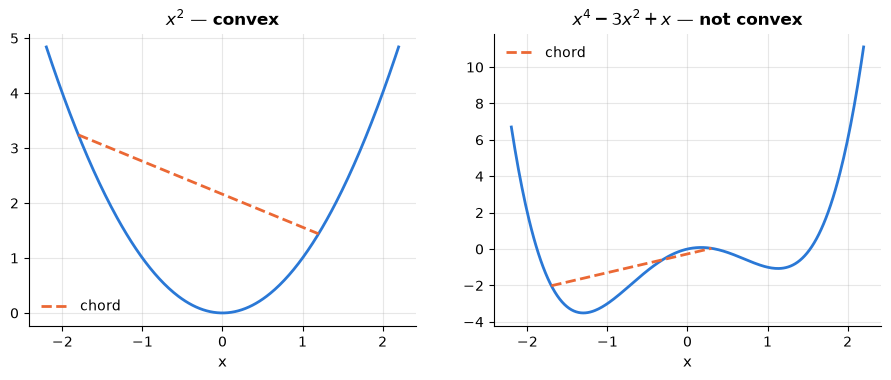

Himmelblau Hessian eigenvalues at the global minimum (3, 2) : [25.7 82.3]
Himmelblau Hessian eigenvalues at the local maximum         : [-45.6 -16.1]
Himmelblau Hessian eigenvalues at the saddle point          : [-14.1  97.5]


In [123]:
def numerical_hessian(grad, w, eps=1e-5):
    """Hessian by central differences of the (analytic) gradient.

    Column i is the change in the gradient when w_i moves by +-eps. Returns a (d, d) matrix,
    symmetrised by averaging with its transpose (round-off makes the raw estimate slightly asymmetric).
    """
    w = np.asarray(w, dtype=float)
    Hm = np.zeros((len(w), len(w)))
    for i in range(len(w)):
        step = np.zeros_like(w)
        step[i] = eps
        Hm[:, i] = (grad(w + step) - grad(w - step)) / (2 * eps)
    return (Hm + Hm.T) / 2

xs = np.linspace(-2.2, 2.2, 300)
convex, nonconvex = xs ** 2, xs ** 4 - 3 * xs ** 2 + xs
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
# zip walks through four lists in step: panel, function values, title, and the two x positions (a, b) of the chord
for ax, fvals, name, (a, b) in zip(axes, [convex, nonconvex], ["$x^2$ — convex", "$x^4 - 3x^2 + x$ — not convex"], [(-1.8, 1.2), (-1.7, 0.3)]):
    ax.plot(xs, fvals, lw=2)
    fa, fb = np.interp([a, b], xs, fvals)     # np.interp: read the function values at a and b off the sampled curve
    ax.plot([a, b], [fa, fb], color=PALETTE[1], lw=2, ls="--", label="chord")
    ax.set_title(name)
    ax.set_xlabel("x")
    ax.legend()
plt.show()

# three stationary points of Himmelblau's function (the last two given to 3 decimals)
for name, point in [("global minimum (3, 2)", [3.0, 2.0]), ("local maximum", [-0.271, -0.923]), ("saddle point", [3.385, 0.074])]:
    eig = np.linalg.eigvalsh(numerical_hessian(grad_himmelblau, point))
    print(f"Himmelblau Hessian eigenvalues at the {name:22s}: {eig.round(1)}")

The chord of the non-convex function dips *below* the graph, and the Hessian eigenvalues at
Himmelblau's stationary points tell the three stories: both positive at a minimum, both
negative at the maximum, one of each at the saddle.

**Example — the chord test by hand.** For $f(x) = x^2$ take the points $-1$ and $3$ with $\alpha = \tfrac12$: the
midpoint $1$ has $f(1) = 1$, below the chord's height $\tfrac12(1 + 9) = 5$, as convexity promises for every pair.
For $g(x) = x^4 - 3x^2 + x$ take $-1.2$ and $1.2$: $g(-1.2) = -3.4464$ and $g(1.2) = -1.0464$, so the chord's
midpoint lies at $-2.2464$, *below* the graph's value $g(0) = 0$ — not convex. The second-derivative test agrees:
$f'' = 2 > 0$ everywhere, while $g''(x) = 12x^2 - 6$ is negative for $|x| < 1/\sqrt2$, for example $g''(0) = -6$.

> **In machine learning.**
> - **Convex models fit reproducibly.** Least squares, ridge, lasso, logistic regression and linear SVMs are
>   convex — for least squares and logistic regression a PSD Hessian proves it (section 2.2; notebook 7, §2.2) — so
>   every solver and starting point reaches the same lowest loss — and the same weights whenever that minimum is
>   unique, as it is here thanks to the default $\ell_2$ penalty (a flat direction like that of section 1.6 leaves
>   many equally good weight vectors). The solver is chosen for speed and for the penalties it supports (notebook 7,
>   §3.3 and §10.5). In the cell below five solvers agree on the weights to four decimals, though not on the number
>   of iterations.
> - **Convexity is designed in.** The number of mistakes (the 0–1 loss) is a step function with zero gradient almost
>   everywhere, so classifiers minimise a convex *surrogate* instead: the log loss (notebook 7, §2.1) or the hinge
>   loss (notebook 11, §2.2).

In [124]:
from sklearn import linear_model                  # scikit-learn's module of linear models
from sklearn.datasets import make_classification  # simulated data for a two-class problem

# e.g. 300 past loans x 4 standardised applicant features; y_clf = 1 if the loan was not repaid
X_clf, y_clf = make_classification(n_samples=300, n_features=4, random_state=RANDOM_STATE)
for solver_name in ["lbfgs", "newton-cg", "newton-cholesky", "sag", "saga"]:
    # one convex objective (log loss + l2 penalty with C=1) minimised by five different algorithms;
    # the tiny tol and the large max_iter (10_000 = 10000; the underscore only aids reading) let each converge fully;
    # random_state fixes the random order in which sag and saga visit the rows
    clf = linear_model.LogisticRegression(solver=solver_name, tol=1e-10, max_iter=10_000,
                                          random_state=RANDOM_STATE).fit(X_clf, y_clf)
    # coef_[0]: the fitted weights; intercept_[0]: the bias; n_iter_[0]: the iterations the solver needed
    print(f"{solver_name:16s} weights {clf.coef_[0].round(4)}  bias {clf.intercept_[0]:.4f}  "
          f"({clf.n_iter_[0]} iterations)")

lbfgs            weights [-1.3421  1.0957  1.3957  0.2557]  bias 0.0315  (11 iterations)
newton-cg        weights [-1.3421  1.0957  1.3957  0.2557]  bias 0.0315  (7 iterations)
newton-cholesky  weights [-1.3421  1.0957  1.3957  0.2557]  bias 0.0315  (7 iterations)
sag              weights [-1.3421  1.0957  1.3957  0.2557]  bias 0.0315  (46 iterations)
saga             weights [-1.3421  1.0957  1.3957  0.2557]  bias 0.0315  (32 iterations)


## 3. Probability

> **Key idea.** Data are noisy: two customers with identical records may still behave differently,
> and the same model scores differently on another test set. Probability is the language of this
> uncertainty. Classifiers output probabilities, and probability tells us how far a score measured
> on a limited sample can be trusted.

### 3.1 Random variables, expectation and variance

> **Key idea.** A random variable is a number produced by chance — whether a customer churns (1) or
> not (0), say. Its distribution says which values can occur and how often; the expectation is the
> long-run average of those values, and the variance measures how widely they scatter around it.

A **random variable** $X$ is a quantity whose value is determined by chance — the outcome
of a die, the number of support tickets a customer files, the noise in a measurement. Its
**distribution** assigns probabilities to values: a probability mass function $p(x) =
P(X = x)$ for discrete variables, a density $p(x)$ (with $P(a \le X \le b) = \int_a^b p(x)\,dx$)
for continuous ones. Two numbers summarise a distribution:

$$
\mathbb{E}[X] = \sum_x x\,p(x) \ \text{ or } \int x\,p(x)\,dx, \qquad
\operatorname{Var}[X] = \mathbb{E}\big[(X - \mathbb{E}[X])^2\big] = \mathbb{E}[X^2] - \mathbb{E}[X]^2 .
$$

Expectation is *linear* — $\mathbb{E}[aX + bY] = a\mathbb{E}[X] + b\mathbb{E}[Y]$ always,
whether or not $X$ and $Y$ are related — while variance scales quadratically,
$\operatorname{Var}[aX] = a^2\operatorname{Var}[X]$, and adds for *independent* (more generally, uncorrelated)
variables: $\operatorname{Var}[X + Y] = \operatorname{Var}[X] + \operatorname{Var}[Y]$ if
$X \perp Y$. The standard deviation $\sqrt{\operatorname{Var}[X]}$ is in the units of $X$.
In practice we estimate both from a sample by the sample mean and sample variance, and the
estimates get better with more data — that is the law of large numbers (section 3.5).

> **Real-life example.** An insurer can cover one villa worth 1 million euros or two independent
> houses worth 500 000 euros each, all with the same fire risk. The expected claims are the same
> (linearity), but the villa's claim is twice a house's claim, so its variance is 4 times a house's,
> while the two independent houses add up to only 2 times: spreading the same cover over independent
> risks halves the variance — the idea behind diversification.

In [125]:
faces = np.arange(1, 7)                   # the outcomes 1..6
p_faces = np.full(6, 1 / 6)               # np.full(shape, value): six entries, each 1/6
mean_exact = faces @ p_faces              # E[X] = sum of x p(x), written as a dot product
var_exact = (faces ** 2) @ p_faces - mean_exact ** 2     # Var[X] = E[X^2] - E[X]^2
print(f"fair die: E[X] = {mean_exact:.4f}, Var[X] = {var_exact:.4f} (= 35/12)")
for n in [10, 1_000, 100_000]:
    rolls = rng.integers(1, 7, size=n)    # random integers from 1 up to 6 (the upper bound 7 is excluded)
    # {n:>7d}: an integer right-aligned in 7 characters; ddof=1 gives the sample variance (divide by n - 1)
    print(f"  n = {n:>7d} rolls: sample mean {rolls.mean():.4f}, sample variance {rolls.var(ddof=1):.4f}")

fair die: E[X] = 3.5000, Var[X] = 2.9167 (= 35/12)
  n =      10 rolls: sample mean 3.9000, sample variance 2.1000
  n =    1000 rolls: sample mean 3.4170, sample variance 3.0862
  n =  100000 rolls: sample mean 3.5052, sample variance 2.9090


**Example — two dice and the rules for variance.** Roll two fair dice $X$ and $Y$ independently;
each has mean 3.5 and variance $\frac{35}{12}$ (cell above). Linearity gives
$\mathbb{E}[X + Y] = 3.5 + 3.5 = 7$, and independence gives
$\operatorname{Var}[X + Y] = \frac{35}{12} + \frac{35}{12} = \frac{35}{6} \approx 5.83$. Doubling
one die gives the same mean, $\mathbb{E}[2X] = 7$, but
$\operatorname{Var}[2X] = 2^2 \cdot \frac{35}{12} = \frac{35}{3} \approx 11.67$: one die counted
twice is riskier than two independent dice. The *average* of the two dice has variance
$\frac{1}{2^2} \cdot \frac{35}{6} = \frac{35}{24} \approx 1.46$, half that of a single die. Listing
the 36 equally likely outcomes checks every number exactly:

In [126]:
# np.meshgrid pairs every face of the first die with every face of the second: two 6 x 6 arrays, 36 outcomes
first_die, second_die = np.meshgrid(faces, faces)       # faces: the outcomes 1, ..., 6 from the die cell above
outcomes = {"X + Y": first_die + second_die, "2X": 2 * first_die, "(X + Y) / 2": (first_die + second_die) / 2}
for quantity, values in outcomes.items():
    # the 36 outcomes are equally likely, so the plain mean and variance (ddof=0) are the exact E and Var
    print(f"{quantity:12s} E = {values.mean():.2f}   Var = {values.var():.4f}")

X + Y        E = 7.00   Var = 5.8333
2X           E = 7.00   Var = 11.6667
(X + Y) / 2  E = 3.50   Var = 1.4583


**Example — a density is not a probability.** Let a waiting time $X$ (in hours) be uniform on
$[0, 0.5]$. Its density is $p(x) = 1/0.5 = 2$ on that interval — larger than 1, which is allowed,
because for a continuous variable probabilities are *areas* under the density, not its height:
$P(0.1 \le X \le 0.2) = 2 \times 0.1 = 0.2$, the total area is $2 \times 0.5 = 1$, and any single
exact value has probability 0.

In [127]:
# stats.uniform(loc, scale) is the uniform distribution on [loc, loc + scale], here [0, 0.5]
# e.g. the wait at a stop served every 30 minutes, for someone who arrives at a random moment
waiting_time = stats.uniform(loc=0, scale=0.5)
print("density p(0.25) =", waiting_time.pdf(0.25), "  <- a density, not a probability: it may exceed 1")
# integrate.quad(f, a, b) integrates f numerically from a to b and returns (value, error estimate); [0] keeps the value
print(f"P(0.1 <= X <= 0.2) = area under the density = {integrate.quad(waiting_time.pdf, 0.1, 0.2)[0]:.4f}")
print(f"total area = {integrate.quad(waiting_time.pdf, 0, 0.5)[0]:.4f}")

density p(0.25) = 2.0   <- a density, not a probability: it may exceed 1
P(0.1 <= X <= 0.2) = area under the density = 0.2000
total area = 1.0000


> **In machine learning.**
> - **The risk is an expectation:** a model's expected loss on new data,
>   $R(f) = \mathbb{E}[\ell(y, f(\mathbf{x}))]$ (notebook 5, §1.2). By linearity, the average loss
>   on fresh test cases has exactly this expectation, so a test score estimates the risk without
>   systematic error; a training score, made small by the fitting, does not.
> - **Decisions minimise expected cost.** If missing a churner costs 300 and a needless retention
>   offer 40, a customer with churn probability $p = 0.2$ costs $300 \times 0.2 = 60$ in expectation
>   if ignored but $40 \times 0.8 = 32$ if contacted, so contacting pays; it does whenever
>   $p > 40/(40 + 300) \approx 0.12$ (notebook 7, §6.5).
> - **Averaging divides the variance.** The average of $k$ independent predictions, each with
>   variance $\sigma^2$, has variance $k\sigma^2/k^2 = \sigma^2/k$: the idea behind ensembles.
>   Correlated errors do not average away (notebook 10, §1.2).
> - **Densities score how typical a point is.** Kernel density estimates and Gaussian mixtures
>   return densities, which can exceed 1 (so `score_samples`, a log-density, can be positive); a low
>   density flags a candidate anomaly (notebook 8, §6; notebook 13, §7).

### 3.2 Common distributions

> **Key idea.** A few standard shapes, each fixed by one or two numbers, describe most random
> quantities met in practice — yes/no outcomes, counts, measurement noise, waiting times.
> Recognising the shape of a target, or of its noise, is often the first step in choosing a model.

| Distribution | Values | Parameters | $p(x)$ | Mean | Variance | Typical use |
|---|---|---|---|---|---|---|
| Bernoulli | $\{0, 1\}$ | $p$ | $p^x(1-p)^{1-x}$ | $p$ | $p(1-p)$ | a binary label, one coin flip |
| Binomial | $\{0, \dots, n\}$ | $n, p$ | $\binom{n}{x}p^x(1-p)^{n-x}$ | $np$ | $np(1-p)$ | number of successes in $n$ flips |
| Poisson | $\{0, 1, 2, \dots\}$ | $\lambda$ | $e^{-\lambda}\lambda^x / x!$ | $\lambda$ | $\lambda$ | counts of rare events (tickets, clicks) |
| Gaussian (normal) | $\mathbb{R}$ | $\mu, \sigma^2$ | $\frac{1}{\sqrt{2\pi\sigma^2}}\exp\!\big(-\frac{(x-\mu)^2}{2\sigma^2}\big)$ | $\mu$ | $\sigma^2$ | measurement noise, sums of many effects |
| Uniform | $[a, b]$ | $a, b$ | $1/(b-a)$ | $(a+b)/2$ | $(b-a)^2/12$ | "no idea", random initialisation |
| Exponential | $[0, \infty)$ | $\lambda$ | $\lambda e^{-\lambda x}$ | $1/\lambda$ | $1/\lambda^2$ | waiting times; a skewed example |

The Bernoulli distribution is the model behind every binary classifier (notebook 7: the
classifier outputs $p$); the Gaussian is the model behind least squares (section 4.3); the
Poisson appears in count regression (`PoissonRegressor`, notebook 6, §8). `scipy.stats`
implements all of them with the same interface (`pmf`/`pdf`, `cdf`, `ppf`, `mean`, `var`,
`rvs`).

> **Real-life example.** A call centre receives on average 4 calls a minute in the afternoon,
> independently of each other. The number of calls in a given minute is then Poisson with mean 4
> (8 or more arrive in about 5 % of minutes), and the gaps between calls are exponential with a mean
> of 15 seconds. These two distributions are the input of the queueing formulas used to decide how
> many agents to staff.

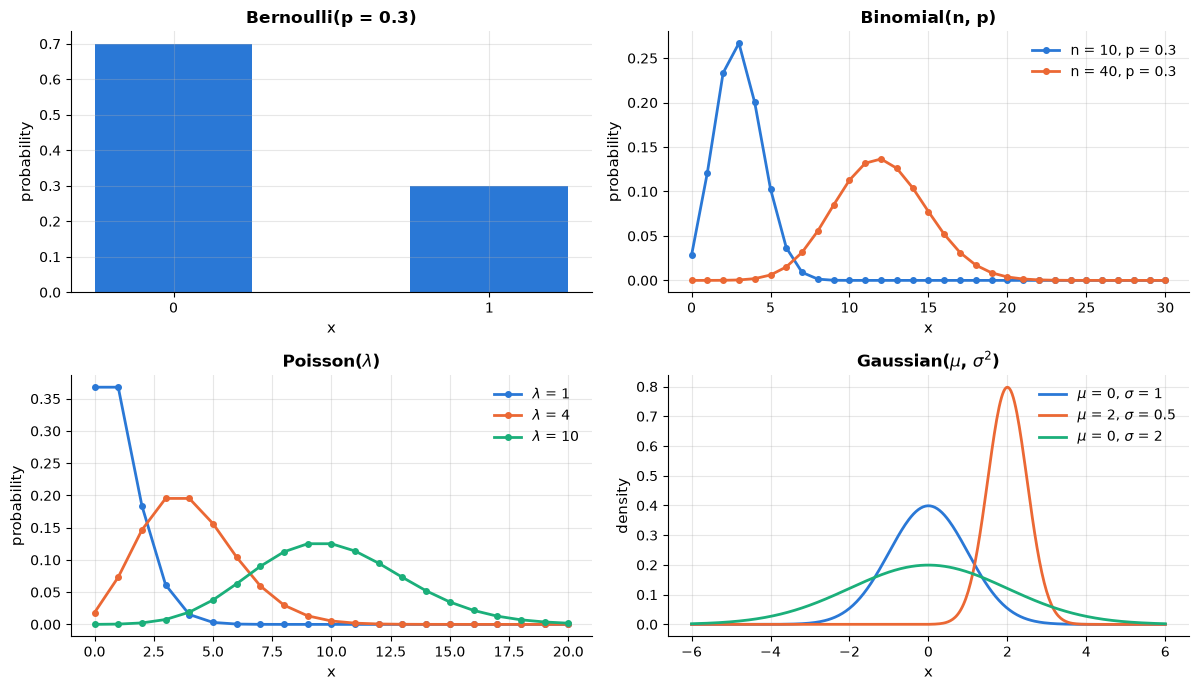

Poisson(4): theoretical mean 4.00 / var 4.00; from 100 000 samples: mean 3.995 / var 3.974


In [128]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))   # a 2 x 2 grid of panels; axes[row, col] picks one
ks = np.arange(0, 21)
# stats.bernoulli(0.3) is a scipy "frozen" distribution with p = 0.3; .pmf(k) gives P(X = k) for each k
axes[0, 0].bar([0, 1], stats.bernoulli(0.3).pmf([0, 1]), width=0.5, color=PALETTE[0])
axes[0, 0].set_title("Bernoulli(p = 0.3)")
axes[0, 0].set_xticks([0, 1])
ks_binom = np.arange(0, 31)
for n_trials, color in [(10, PALETTE[0]), (40, PALETTE[1])]:
    axes[0, 1].plot(ks_binom, stats.binom(n_trials, 0.3).pmf(ks_binom), marker="o", ms=4, color=color, label=f"n = {n_trials}, p = 0.3")
axes[0, 1].set_title("Binomial(n, p)")
axes[0, 1].legend()
for lam_, color in [(1, PALETTE[0]), (4, PALETTE[1]), (10, PALETTE[2])]:     # lam_ is the Poisson rate lambda
    axes[1, 0].plot(ks, stats.poisson(lam_).pmf(ks), marker="o", ms=4, color=color, label=f"$\\lambda$ = {lam_}")
axes[1, 0].set_title("Poisson($\\lambda$)")
axes[1, 0].legend()
xs = np.linspace(-6, 6, 400)
for mu, sd, color in [(0, 1, PALETTE[0]), (2, 0.5, PALETTE[1]), (0, 2, PALETTE[2])]:
    # stats.norm(mean, standard deviation) — note: the standard deviation, not the variance; .pdf gives the density
    axes[1, 1].plot(xs, stats.norm(mu, sd).pdf(xs), color=color, label=f"$\\mu$ = {mu}, $\\sigma$ = {sd}")
axes[1, 1].set_title("Gaussian($\\mu$, $\\sigma^2$)")
axes[1, 1].legend()
for ax in axes[0]:                        # axes[0] is the top row of panels
    ax.set_ylabel("probability")
axes[1, 0].set_ylabel("probability")
axes[1, 1].set_ylabel("density")
for ax in axes.ravel():                   # .ravel() flattens the 2 x 2 grid into a sequence of 4 panels
    ax.set_xlabel("x")
plt.tight_layout()
plt.show()

# e.g. the number of calls in each of 100 000 afternoon minutes at the call centre above
samples = rng.poisson(4, size=100_000)    # 100 000 random draws from Poisson(4)
# .mean() / .var() of a frozen distribution are the exact theoretical values
print(f"Poisson(4): theoretical mean {stats.poisson(4).mean():.2f} / var {stats.poisson(4).var():.2f}; "
      f"from 100 000 samples: mean {samples.mean():.3f} / var {samples.var():.3f}")

**Example — how much does a test accuracy wobble?** A classifier that is right 90 % of the time is
scored on 100 independent test cases. Each case is a Bernoulli trial (correct or not), so the number
of correct predictions is $\text{Binomial}(100, 0.9)$, with mean $100 \times 0.9 = 90$, variance
$100 \times 0.9 \times 0.1 = 9$ and standard deviation $\sqrt{9} = 3$. Even the most likely result,
exactly 90 correct, has probability only 0.132, and adding up the probabilities of 0, 1, …, 85
correct answers shows that in about one test set in 14 this 90 % model scores 85 % or less. Section
3.5 turns this wobble into an error bar.

In [129]:
n_correct = stats.binom(100, 0.9)     # correct predictions on 100 test cases: a frozen Binomial(n=100, p=0.9)
# .mean() and .std() of a frozen distribution are its exact mean and standard deviation; .pmf(k) = P(X = k)
print(f"mean {n_correct.mean():.0f}, standard deviation {n_correct.std():.1f}")
print(f"P(exactly 90 correct) = {n_correct.pmf(90):.3f}")
# summing the PMF over k = 0, 1, ..., 85 gives P(at most 85 correct), i.e. a measured accuracy of 85 % or less
print(f"P(at most 85 correct) = {n_correct.pmf(np.arange(0, 86)).sum():.4f}")

mean 90, standard deviation 3.0
P(exactly 90 correct) = 0.132
P(at most 85 correct) = 0.0726


> **In machine learning.**
> - **Gaussian: noise, classes and clusters.** Besides the noise of least squares, Gaussian naive
>   Bayes models each feature within each class as a Gaussian (notebook 8, §4.2), and a Gaussian
>   mixture each cluster (notebook 13, §5).
> - **Exponential: the simplest skewed shape.** In durations and accumulated charges, as in waiting
>   times, most values are small and a few are huge: a long right tail that drags the mean up. The
>   exponential is this notebook's skewed test case (sections 3.5 and 4.5). Notebook 3, §3.2 and
>   notebook 4, §6.3 plot and transform such data.
> - **Uniform and log-uniform: random search.** Random search (notebook 12, §1.3 and §3) draws a
>   hyper-parameter that is a fraction — such as the share of features each tree sees — uniformly, but a
>   regularisation strength — `alpha` $= \lambda$, or `C` $= 1/\lambda$ (section 4.4) — which acts by orders of
>   magnitude, log-uniformly (`stats.loguniform`: its logarithm is uniform). Between 0.001 and 1 000, a uniform
>   draw lands above 100 with probability 0.9 and below 1 with probability 0.001; a log-uniform draw
>   gives each of the six decades probability $1/6$.

**The cumulative distribution function and quantiles.** The probability
$P(\text{at most 85 correct}) \approx 0.073$ of the accuracy example is a value of the **cumulative
distribution function** (CDF) $F(x) = P(X \le x)$, which answers "what fraction of the values lies
at or below $x$?"; it rises from 0 to 1, and $P(a < X \le b) = F(b) - F(a)$. Read backwards it gives
the **quantile function** $F^{-1}(q)$, the value below which a fraction $q$ lies: the 0.5-quantile
is the **median**, the 0.25- and 0.75-quantiles are the first and third **quartiles**. In
`scipy.stats` the CDF is `cdf` and the quantile function `ppf` ("percent-point function").

**Example — where the 1.96 comes from.** The CDF of the standard normal $\mathcal{N}(0, 1)$ (mean 0,
standard deviation 1) has its own symbol, $\Phi$, and $\Phi(1.96) \approx 0.975$. So 2.5 % of the
distribution lies above 1.96 and, by symmetry, 2.5 % below $-1.96$: the middle 95 % lies within
$\pm 1.96$ — the 1.96 of the usual normal-approximation 95 % confidence interval (sections 3.5 and 4.5). Conversely,
`ppf(0.975)` returns 1.96.

Phi(1.96) = 0.9750   Phi(-1.96) = 0.0250   ppf(0.975) = 1.9600
Phi(-1) = 0.1587
accuracy example: F(85) = n_correct.cdf(85) = 0.0726


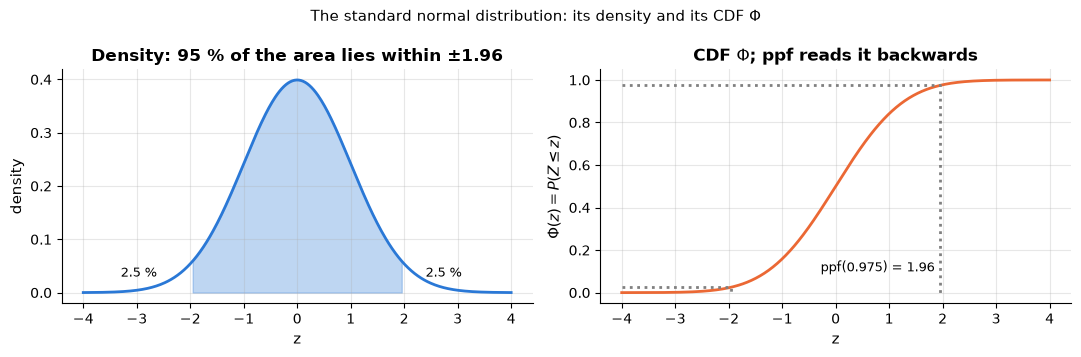

In [130]:
std_normal = stats.norm(0, 1)     # the standard normal N(0, 1); its CDF is written Phi
# .cdf(x) = P(X <= x); .ppf(q) inverts it: the value below which a fraction q of the distribution lies
print(f"Phi(1.96) = {std_normal.cdf(1.96):.4f}   Phi(-1.96) = {std_normal.cdf(-1.96):.4f}   "
      f"ppf(0.975) = {std_normal.ppf(0.975):.4f}")
print(f"Phi(-1) = {std_normal.cdf(-1):.4f}")
print(f"accuracy example: F(85) = n_correct.cdf(85) = {n_correct.cdf(85):.4f}")

z_grid = np.linspace(-4, 4, 400)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].plot(z_grid, std_normal.pdf(z_grid), color=PALETTE[0], lw=2)
# fill_between shades the area under the curve wherever `where` is True: here |z| <= 1.96
axes[0].fill_between(z_grid, std_normal.pdf(z_grid), where=np.abs(z_grid) <= 1.96, color=PALETTE[0], alpha=0.3)
for tail_x in [-3.3, 2.4]:        # label the two tails left outside the shaded area
    axes[0].text(tail_x, 0.03, "2.5 %", fontsize=9)
axes[0].set_title("Density: 95 % of the area lies within ±1.96")
axes[0].set_ylabel("density")
axes[1].plot(z_grid, std_normal.cdf(z_grid), color=PALETTE[1], lw=2)
for level in [0.025, 0.975]:      # a dotted path from a probability on the y-axis down to its quantile
    axes[1].plot([-4, std_normal.ppf(level), std_normal.ppf(level)], [level, level, 0], color="gray", ls=":")
axes[1].text(1.85, 0.1, "ppf(0.975) = 1.96", fontsize=9, ha="right")   # ha="right": the text ends at x = 1.85
axes[1].set_title("CDF $\\Phi$; ppf reads it backwards")
axes[1].set_ylabel("$\\Phi(z) = P(Z \\leq z)$")
for ax in axes:
    ax.set_xlabel("z")
fig.suptitle("The standard normal distribution: its density and its CDF $\\Phi$", fontsize=11)
plt.tight_layout()
plt.show()

**Sample quantiles, the median and the IQR.** For data, the same ideas apply to the *sorted sample*:
the median is the middle value, the quartiles $Q_1$ and $Q_3$ cut off the lowest and the highest
quarter, and the **interquartile range** IQR $= Q_3 - Q_1$ is the width of the middle half. Unlike
the mean and the standard deviation, they barely move when a few values are wrong.

**Example — one typo.** Nine customers pay 10, 11, …, 18 euros a month: mean = median = 14,
$Q_1 = 12$, $Q_3 = 16$, IQR $= 4$. Mistype the 18 as 180 and the total 126 becomes
$126 - 18 + 180 = 288$, so the mean jumps to $288/9 = 32$ and the standard deviation from 2.74 to
55.55, while the median and the IQR stay at 14 and 4.

In [131]:
from sklearn.preprocessing import RobustScaler   # rescales each column to (x - median) / IQR

charges_clean = np.arange(10.0, 19.0)            # 10, 11, ..., 18 euros
charges_typo = charges_clean.copy()              # .copy(): a new array, so the clean one stays unchanged
charges_typo[-1] = 180.0                         # the 18 mistyped as 180
for version, charges in [("clean", charges_clean), ("with typo", charges_typo)]:
    q1, median, q3 = np.percentile(charges, [25, 50, 75])     # sample quartiles (linear interpolation by default)
    print(f"{version:9s}: mean {charges.mean():5.1f}  sd {charges.std(ddof=1):5.2f}  |  "
          f"median {median:4.1f}  IQR {q3 - q1:.1f}")
# fit_transform learns the median and the IQR, then applies (x - median) / IQR; reshape(-1, 1) makes one column
print("robust-scaled:", RobustScaler().fit_transform(charges_typo.reshape(-1, 1)).ravel())
# (x - mean) / sd with the 1/n standard deviation is what StandardScaler computes
print("standardised :", ((charges_typo - charges_typo.mean()) / charges_typo.std()).round(2))

clean    : mean  14.0  sd  2.74  |  median 14.0  IQR 4.0
with typo: mean  32.0  sd 55.55  |  median 14.0  IQR 4.0
robust-scaled: [-1.   -0.75 -0.5  -0.25  0.    0.25  0.5   0.75 41.5 ]
standardised : [-0.42 -0.4  -0.38 -0.36 -0.34 -0.32 -0.31 -0.29  2.83]


> **In machine learning.**
> - **The best achievable error.** If a feature follows $\mathcal{N}(0, 1)$ in one class and
>   $\mathcal{N}(\Delta, 1)$ in an equally common other class, the best rule cuts at $\Delta/2$ and
>   still errs with probability $\Phi(-\Delta/2)$, e.g. $\Phi(-1) \approx 0.159$ for $\Delta = 2$.
>   Notebook 8, §1.5 checks $k$-nearest neighbours against this Bayes error.
> - **Robust scaling and outliers.** `RobustScaler` keeps the eight genuine charges spread over
>   $[-1, 0.75]$ and isolates the typo at 41.5; standardising squeezes them into $[-0.42, -0.29]$,
>   because the typo inflated the standard deviation (notebook 4, §4.1). Box plots flag points more
>   than $1.5 \times$ IQR beyond the quartiles, here anything above $16 + 6 = 22$ (notebook 3, §3.3
>   and §3.5).
> - **Quantile transforms.** `QuantileTransformer` passes each feature through its estimated CDF,
>   making it uniform on $[0, 1]$, and optionally through $\Phi^{-1}$ (`ppf`), making it Gaussian
>   (notebook 4, §4.1).
> - **Prediction intervals.** Models of the 5 % and the 95 % quantile of the target give a nominal
>   90 % prediction interval (quantile regression, notebook 16, §4.6).

### 3.3 Joint, marginal and conditional probabilities; independence

> **Key idea.** With two random quantities we can ask how often each *combination* occurs (joint),
> how often each value of one occurs on its own (marginal), and how the chances of one change once
> we know the other (conditional). If knowing one never changes the chances of the other, they are
> independent — and then one is useless for predicting the other.

For two random variables the **joint** distribution $P(X = x, Y = y)$ says how often each
combination occurs. Summing over one variable gives the **marginal** of the other,
$P(X = x) = \sum_y P(X = x, Y = y)$, and dividing gives the **conditional**,

$$
P(Y = y \mid X = x) = \frac{P(X = x, Y = y)}{P(X = x)} \qquad \text{(the product rule: } P(x, y) = P(y \mid x)\,P(x)\text{)}.
$$

$X$ and $Y$ are **independent** if $P(x, y) = P(x)P(y)$ for all $x, y$ — equivalently,
knowing $X$ does not change the distribution of $Y$. Classification is the business of
estimating $P(y \mid \mathbf{x})$; naive Bayes (notebook 8) assumes the features are
independent given the class (*conditional independence*, section 3.4); decision trees
(notebook 9) look for the feature whose conditional distributions differ most. We can
compute all of this from a table. Here $X$ = contract type and $Y$ = churned, from the
(cleaned) churn data:

In [132]:
churn = load_churn()                      # the cleaned customer-churn table (one row per customer)
# pd.crosstab counts every (contract, churned) combination; normalize=True divides the counts by the total
joint = pd.crosstab(churn["contract"], churn["churned"], normalize=True)   # P(contract, churned)
marg_contract = joint.sum(axis=1)                                            # P(contract)
marg_churn = joint.sum(axis=0)                                               # P(churned)
# .div(series, axis=0) divides each row by the matching entry of the series (matched by row label)
conditional = joint.div(marg_contract, axis=0)                               # P(churned | contract)
# np.outer(a, b) is the table a[i] * b[j], here (3 contracts) x (2 churn values)
independent = np.outer(marg_contract, marg_churn)                            # what the joint would be under independence

print("joint P(contract, churned):")
display(joint.round(3))                   # display() renders the table nicely even in the middle of a cell
print("marginal P(churned = 1):", marg_churn[1].round(3))      # [1] selects the entry with label 1, not position 1
# conditional[1] is the column churned = 1; .to_dict() turns it into {contract: probability}
print("conditional P(churned = 1 | contract):", conditional[1].round(3).to_dict())
print("\nlargest |joint - P(contract) P(churned)|:", np.abs(joint.to_numpy() - independent).max().round(3),
      "-> far from independent; contract type carries information about churn")

joint P(contract, churned):


churned,0,1
contract,,
Month-to-month,0.294,0.265
One year,0.197,0.047
Two year,0.183,0.014


marginal P(churned = 1): 0.326
conditional P(churned = 1 | contract): {'Month-to-month': 0.474, 'One year': 0.193, 'Two year': 0.072}

largest |joint - P(contract) P(churned)|: 0.083 -> far from independent; contract type carries information about churn


> **In machine learning.**
> - **Classifiers estimate conditional probabilities.** `predict_proba` returns an estimate of
>   $P(y \mid \mathbf{x})$. A decision tree (notebook 9) allowed to look only at the contract type
>   reproduces the conditional probabilities of the table exactly: each of its leaves holds one
>   contract type and predicts the churn rate inside it (demo below).
> - **The kinds of drift are named after what changes.** After deployment the joint distribution
>   $P(\mathbf{x}, y) = P(y \mid \mathbf{x})\,P(\mathbf{x}) = P(\mathbf{x} \mid y)\,P(y)$ (the product rule both ways
>   round) can change through the inputs
>   $P(\mathbf{x})$ (covariate shift), the base rate $P(y)$ (prior shift) or the relation
>   $P(y \mid \mathbf{x})$ itself (concept drift), and each leaves different symptoms (notebook 18,
>   §7.1).

In [133]:
from sklearn.tree import DecisionTreeClassifier   # a classifier that splits the data into groups (notebook 9)

# pd.get_dummies turns the contract column into three True/False columns, one per contract type
contract_onehot = pd.get_dummies(churn["contract"])            # churn: the table loaded above
# max_depth=2 allows two levels of splits, enough to separate the three contract types
contract_tree = DecisionTreeClassifier(max_depth=2, random_state=RANDOM_STATE).fit(contract_onehot, churn["churned"])
# predict_proba gives one row [P(churned = 0 | x), P(churned = 1 | x)] per customer; [:, 1] keeps P(churned = 1 | x)
# pd.Series(values, index=...) labels the probabilities with the customers' row labels, so they line up with churn
predicted_churn = pd.Series(contract_tree.predict_proba(contract_onehot)[:, 1], index=churn.index)
# the prediction is the same for every customer with a given contract: group by contract and show it once
print("tree's P(churned = 1 | contract):", predicted_churn.groupby(churn["contract"]).mean().round(3).to_dict())

tree's P(churned = 1 | contract): {'Month-to-month': 0.474, 'One year': 0.193, 'Two year': 0.072}


**Covariance and correlation.** For two numeric variables the **covariance**

$$
\operatorname{Cov}[X, Y] = \mathbb{E}\big[(X - \mathbb{E}[X])(Y - \mathbb{E}[Y])\big]
$$

is positive when $X$ and $Y$ tend to lie above (or below) their means together, and negative when
one tends to be high while the other is low; the covariance matrix of sections 1.4 and 1.6 collects
it for every pair of features. It completes the rule of section 3.1: in general
$\operatorname{Var}[X + Y] = \operatorname{Var}[X] + \operatorname{Var}[Y] + 2\operatorname{Cov}[X, Y]$,
so variances add whenever the covariance is zero. Its size depends on the units, so we divide by
both standard deviations to get the (Pearson) **correlation**
$\rho = \operatorname{Cov}[X, Y]/(\sigma_X\sigma_Y)$, which lies in $[-1, 1]$: $\pm 1$ for an exact
straight line, 0 for no *linear* relation. Independent variables have zero correlation, but not the
other way round.

**Example — correlation by hand.** For $x = (1, 2, 3)$ and $y = (1, 3, 2)$ the deviations from the
means (2 and 2) are $(-1, 0, 1)$ and $(-1, 1, 0)$, the sample covariance is
$\frac{(-1)(-1) + 0 \cdot 1 + 1 \cdot 0}{3 - 1} = 0.5$, both sample variances are
$\frac{1 + 0 + 1}{2} = 1$, so $\rho = 0.5$. For $x = (-1, 0, 1)$ and $y = x^2 = (1, 0, 1)$, $y$ is
completely determined by $x$, yet $\rho = 0$: the relation is not a straight line.

In [134]:
x_toy, y_toy = np.array([1.0, 2.0, 3.0]), np.array([1.0, 3.0, 2.0])
# np.cov(a, b) is the 2 x 2 matrix [[Var a, Cov(a, b)], [Cov(a, b), Var b]] (dividing by n - 1);
# .tolist() turns the array into nested Python lists, which print on one line
print("covariance matrix:", np.cov(x_toy, y_toy).tolist())
# np.corrcoef(a, b) is the 2 x 2 correlation matrix; the entry [0, 1] is the correlation of a and b
print(f"correlation: {np.corrcoef(x_toy, y_toy)[0, 1]:.2f}")
x_sym = np.array([-1.0, 0.0, 1.0])
print(f"correlation of x and x**2: {np.corrcoef(x_sym, x_sym ** 2)[0, 1]:.2f}   <- y depends on x, but not linearly")
# on the churn data: DataFrame.corr() gives the correlation of every pair of columns (missing values are skipped)
display(churn[["tenure_months", "total_charges", "support_tickets", "churned"]].corr().round(2))

covariance matrix: [[1.0, 0.5], [0.5, 1.0]]
correlation: 0.50
correlation of x and x**2: 0.00   <- y depends on x, but not linearly


,tenure_months,total_charges,support_tickets,churned
tenure_months,1.00,0.82,0.00,-0.35
total_charges,0.82,1.00,0.17,-0.18
support_tickets,0.00,0.17,1.00,0.32
churned,-0.35,-0.18,0.32,1.00


> **In machine learning.**
> - **Redundant features.** `tenure_months` and `total_charges` are correlated at 0.82: they carry
>   overlapping information. Correlation heatmaps reveal such pairs (notebook 3, §4.2 and §4.5); in
>   a linear model they make the individual coefficients unstable (multicollinearity, notebook 6,
>   §4.2), and permutation importance splits the credit between them (notebook 17, §3.2).
> - **A first screen of features.** Customers with a longer tenure churn less ($-0.35$), those who
>   file more support tickets churn more ($0.32$). A correlation near zero does not prove a feature
>   useless, though: correlation sees only straight-line relations, as the $x^2$ example shows.
>   Mutual information (section 5.3) detects any dependence and is used to select features (notebook
>   4, §7.1).

### 3.4 Bayes' theorem

> **Key idea.** Bayes' theorem turns "how likely is this evidence if the hypothesis is true?" into
> "how likely is the hypothesis now that I have seen the evidence?". The answer weighs the evidence
> against how common the hypothesis was to begin with (the base rate), so even strong evidence for
> something rare can leave it unlikely.

Applying the product rule in both orders, $P(x, y) = P(y \mid x)P(x) = P(x \mid y)P(y)$,
and dividing:

$$
P(y \mid x) \;=\; \frac{P(x \mid y)\,P(y)}{P(x)}, \qquad P(x) = \sum_{y'} P(x \mid y')\,P(y') .
$$

In the language of inference: the **posterior** probability of a hypothesis $y$ given
evidence $x$ equals the **likelihood** of the evidence under the hypothesis, times the
**prior** probability of the hypothesis, normalised by the total probability of the
evidence. The classic worked example shows why intuition fails here. A test for a disease
with **prevalence** 1 % has **sensitivity** $P(+ \mid D) = 0.99$ and **specificity**
$P(- \mid \neg D) = 0.95$. You test positive. How likely are you to have the disease?

$$
P(D \mid +) = \frac{0.99 \times 0.01}{0.99 \times 0.01 + 0.05 \times 0.99} = \frac{0.0099}{0.0099 + 0.0495} \approx 0.167 .
$$

Only one in six positives is a true positive: because the disease is rare, the 5 % of
healthy people who test positive outnumber the sick ones. *Natural frequencies* make this
transparent — of 10 000 people, 99 of the 100 sick ones and 495 of the 9 900 healthy ones
test positive. The same mechanism governs every classifier on an imbalanced problem:
precision depends on the base rate, not only on the model (notebook 7).

P(disease | positive test) = 0.167
natural frequencies out of 10000: 99 true positives vs 495 false positives


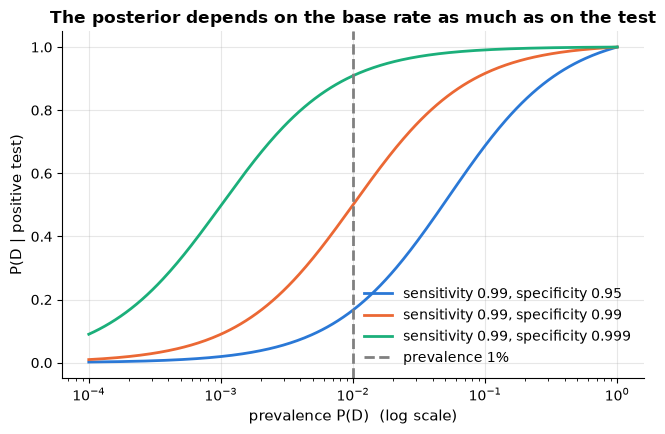

In [135]:
def posterior_positive(prevalence, sensitivity, specificity):
    """P(disease | positive test) by Bayes' theorem.

    prevalence is P(D), sensitivity P(+ | D), specificity P(- | healthy). Works element by element
    when prevalence is an array, which the plot below uses.
    """
    p_pos_given_d = sensitivity
    p_pos_given_healthy = 1 - specificity              # false-positive rate
    evidence = p_pos_given_d * prevalence + p_pos_given_healthy * (1 - prevalence)   # P(+), by total probability
    return p_pos_given_d * prevalence / evidence

print(f"P(disease | positive test) = {posterior_positive(0.01, 0.99, 0.95):.3f}")
N = 10_000
sick = N * 0.01
print(f"natural frequencies out of {N}: {sick * 0.99:.0f} true positives vs {(N - sick) * 0.05:.0f} false positives")

prev = np.logspace(-4, 0, 300)            # 300 prevalences from 10^-4 to 1, evenly spaced on a log scale
fig, ax = plt.subplots()
for sens, spec in [(0.99, 0.95), (0.99, 0.99), (0.99, 0.999)]:
    ax.plot(prev, posterior_positive(prev, sens, spec), lw=2, label=f"sensitivity {sens}, specificity {spec}")
ax.axvline(0.01, color="gray", ls="--", label="prevalence 1%")
ax.set_xscale("log")
ax.set_xlabel("prevalence P(D)  (log scale)")
ax.set_ylabel("P(D | positive test)")
ax.set_title("The posterior depends on the base rate as much as on the test")
ax.legend()
plt.show()

Bayes' theorem is also a *learning rule*: with $y$ = model parameters and $x$ = data, the
posterior over parameters is proportional to likelihood × prior, which is the idea behind
maximum a posteriori estimation and regularisation in section 4.4 and behind Bayesian
methods generally (Murphy, 2022; Bishop, 2006).

> **In machine learning.** Read the test as a classifier: sensitivity is its recall (true-positive
> rate), $1 -$ specificity its false-positive rate, and $P(D \mid +)$ its precision (notebook 7,
> §5.4). A fraud detector with 99 % sensitivity and 99 % specificity — the middle curve of the plot
> above — used where 0.1 % of transactions are fraudulent, raises 99 true and 999 false alarms per
> 100 000 transactions: a precision of $99/1098 \approx 0.09$. The same detector reaches 0.5 at a
> 1 % fraud rate (990 true against 990 false alarms). Recall and the false-positive rate do not
> change with the base rate, but precision does, which is why precision–recall curves are the better
> view when positives are rare (notebook 7, §6.4).

**Conditional independence and naive Bayes.** Two features can be dependent overall yet independent
once the class is known. In e-mail, "free" and "winner" often appear together, mainly because both
are typical of spam; *among spam e-mails alone*, seeing one says little about the other. Formally,
$X_1$ and $X_2$ are **conditionally independent given** $Y$ if
$P(x_1, x_2 \mid y) = P(x_1 \mid y)\,P(x_2 \mid y)$. Naive Bayes assumes this for all features, so
Bayes' theorem needs only one-feature probabilities.

**Example — a two-word spam filter.** Let $P(\text{spam}) = 0.4$,
$P(\text{free} \mid \text{spam}) = 0.5$, $P(\text{free} \mid \text{ham}) = 0.05$,
$P(\text{winner} \mid \text{spam}) = 0.3$ and $P(\text{winner} \mid \text{ham}) = 0.02$ ("ham" = not
spam), with the two words independent within each class. For an e-mail containing both words, spam
scores $0.4 \times 0.5 \times 0.3 = 0.06$ and ham $0.6 \times 0.05 \times 0.02 = 0.0006$; dividing
by their sum, the evidence, gives $P(\text{spam} \mid \text{both}) = 0.06 / 0.0606 \approx 0.990$.
Overall, though, the words are far from independent: seeing "free" doubles the chance of "winner",
from $0.4 \times 0.3 + 0.6 \times 0.02 = 0.132$ to $0.0606 / 0.23 \approx 0.263$.

In [136]:
class_prior = {"spam": 0.4, "ham": 0.6}                          # P(class)
word_given_class = {"spam": {"free": 0.5, "winner": 0.3},          # P(word appears | class)
                    "ham": {"free": 0.05, "winner": 0.02}}
# naive Bayes: prior x product of the one-word probabilities (a dict comprehension: one score per class)
nb_scores = {c: class_prior[c] * word_given_class[c]["free"] * word_given_class[c]["winner"] for c in class_prior}
print(f"P(spam | 'free' and 'winner') = {nb_scores['spam'] / sum(nb_scores.values()):.3f}")
# all e-mails together, by total probability: P(word) = sum over classes of P(class) P(word | class)
p_free = sum(class_prior[c] * word_given_class[c]["free"] for c in class_prior)
p_winner = sum(class_prior[c] * word_given_class[c]["winner"] for c in class_prior)
# the two scores add up to P(both words), so P(winner | free) = P(both) / P(free)
print(f"P(winner) = {p_winner:.3f}, but P(winner | free) = {sum(nb_scores.values()) / p_free:.3f}")
# counting "free" twice, as if it were a second independent clue, makes the model over-confident
nb_scores_twice = {c: nb_scores[c] * word_given_class[c]["free"] for c in class_prior}
print(f"with 'free' counted twice: P(spam | words) = {nb_scores_twice['spam'] / sum(nb_scores_twice.values()):.4f}")

P(spam | 'free' and 'winner') = 0.990
P(winner) = 0.132, but P(winner | free) = 0.263
with 'free' counted twice: P(spam | words) = 0.9990


> **In machine learning.** These few lines are the prediction rule of naive Bayes (notebook 8,
> §4.1); fitting it means estimating the one-feature probabilities from the training data — word
> counts for `MultinomialNB`, word presence for `BernoulliNB` (the model of this example; notebook
> 8, §4.3), one Gaussian per feature and class for `GaussianNB` (notebook 8, §4.2). Real features
> are rarely conditionally independent. The classifier often ranks well anyway, but correlated
> features count as independent evidence, which pushes its probabilities towards 0 and 1 — the
> "counted twice" line above, and notebook 8, §4.5.

### 3.5 The law of large numbers and the central limit theorem, by simulation

> **Key idea.** Averages of many independent measurements are stable: they settle down to the true
> mean (law of large numbers), and their remaining random error follows a bell curve whose width
> shrinks as the sample grows (central limit theorem). That is why a score measured on more data
> deserves more trust — and the bell curve says how much.

Two theorems justify most of statistics and, with it, most of machine learning. Let
$X_1, \dots, X_n$ be i.i.d. with mean $\mu$ and variance $\sigma^2$, and let
$\bar{X}_n = \frac{1}{n}\sum_i X_i$ be the sample mean. Here **i.i.d.**
(*independent and identically distributed*) means that no draw influences another
(section 3.3) and that all draws come from the same distribution — like repeated rolls of
one die, or customers picked at random from one population.

- **Law of large numbers (LLN):** $\bar{X}_n \to \mu$ as $n \to \infty$. Averages settle
  down. This is why the empirical risk (average loss on a sample, notebook 5) is a sensible
  proxy for the true risk (expected loss), and why test-set accuracy estimates generalisation.
- **Central limit theorem (CLT):** whatever the shape of the distribution of the $X_i$,
  $\sqrt{n}(\bar{X}_n - \mu)/\sigma \to \mathcal{N}(0, 1)$ in distribution; for finite $n$,
  $\bar{X}_n \approx \mathcal{N}(\mu, \sigma^2/n)$. Averages are approximately Gaussian with
  a standard deviation — the **standard error** — that shrinks like $1/\sqrt{n}$. This is why
  confidence intervals look like $\bar{x} \pm 1.96\, s/\sqrt{n}$ (section 4.5), why Gaussian
  noise is the default assumption (noise is often a sum of many small effects), and why
  halving the standard error of an estimate costs four times the data.

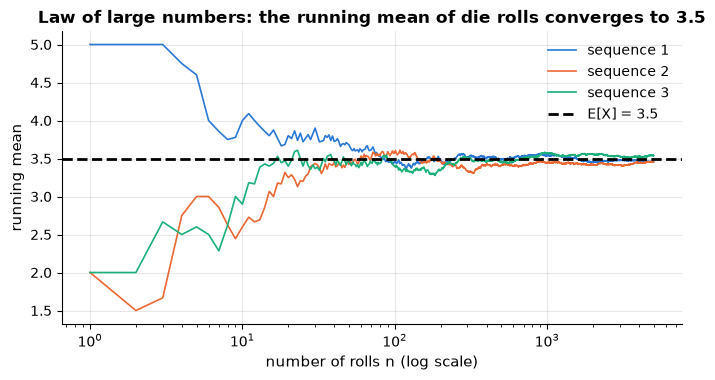

In [137]:
n_max = 5_000
fig, ax = plt.subplots(figsize=(8, 3.8))
for i in range(3):                        # three independent sequences of die rolls
    rolls = rng.integers(1, 7, size=n_max)
    # cumulative sums divided by 1, 2, ..., n_max: the mean of the first n rolls, for every n
    running_mean = np.cumsum(rolls) / np.arange(1, n_max + 1)
    ax.plot(np.arange(1, n_max + 1), running_mean, lw=1.2, color=PALETTE[i], label=f"sequence {i + 1}")
ax.axhline(3.5, color="black", ls="--", label="E[X] = 3.5")
ax.set_xscale("log")
ax.set_xlabel("number of rolls n (log scale)")
ax.set_ylabel("running mean")
ax.set_title("Law of large numbers: the running mean of die rolls converges to 3.5")
ax.legend()
plt.show()

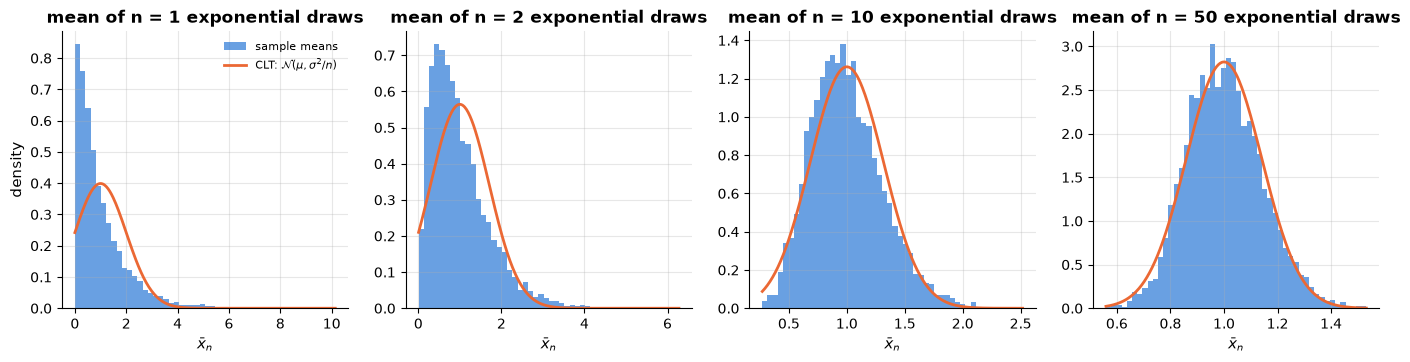

In [138]:
n_reps = 5_000
fig, axes = plt.subplots(1, 4, figsize=(17, 3.6))
for ax, n in zip(axes, [1, 2, 10, 50]):
    # a (5000, n) array of draws; .mean(axis=1) averages each row -> 5000 sample means of size n
    # e.g. call durations in units of the average call: most are short, a few very long
    means = rng.exponential(scale=1.0, size=(n_reps, n)).mean(axis=1)     # exponential(1): mean 1, variance 1, very skewed
    # density=True scales the bars so their total area is 1, comparable with the density curve
    ax.hist(means, bins=50, density=True, color=PALETTE[0], alpha=0.7, label="sample means")
    xs = np.linspace(means.min(), means.max(), 300)
    # the CLT prediction: a normal density with mean 1 and standard deviation 1 / sqrt(n)
    ax.plot(xs, stats.norm(1.0, 1.0 / np.sqrt(n)).pdf(xs), color=PALETTE[1], lw=2, label="CLT: $\\mathcal{N}(\\mu, \\sigma^2/n)$")
    ax.set_title(f"mean of n = {n} exponential draws")
    ax.set_xlabel("$\\bar{x}_n$")
axes[0].set_ylabel("density")
axes[0].legend(fontsize=8)
plt.show()

With $n = 1$ the histogram is the skewed exponential density itself; by $n = 50$ it is
indistinguishable from the Gaussian predicted by the CLT, and its width has shrunk by
$\sqrt{50} \approx 7$.

> **In machine learning.**
> - **Error bars on a test score.** A test accuracy is the average of $n$ i.i.d. 0/1 outcomes
>   (correct or not), each with variance $\text{acc}(1 - \text{acc})$, so its standard error is
>   $\sqrt{\text{acc}(1 - \text{acc})/n}$ — the binomial standard deviation of section 3.2 divided
>   by $n$ — and by the CLT it is approximately Gaussian. For the 100 test cases at 90 % accuracy of
>   that example, $\sqrt{0.9 \times 0.1/100} = 0.03$, and the 95 % interval is
>   $0.90 \pm 1.96 \times 0.03 = 0.90 \pm 0.059$, roughly $[0.84, 0.96]$. Notebook 20, §10 uses the
>   same formula: the share of its 169 senior customers picked for a retention offer, 0.14, has standard error
>   0.027.
> - **How large a test set?** Requiring the half-width $1.96\sqrt{\text{acc}(1 - \text{acc})/n}$ of
>   the interval to be at most $h$ gives $n \ge 1.96^2\,\text{acc}(1 - \text{acc})/h^2$: 3 458 test
>   cases for $\pm 1$ point at 90 % accuracy, and a hundred times as many for $\pm 0.1$ point.

In [139]:
test_accuracy = 0.9
for n_test_cases in [100, 1_000, 10_000]:
    se_accuracy = np.sqrt(test_accuracy * (1 - test_accuracy) / n_test_cases)   # standard error of the accuracy
    print(f"n = {n_test_cases:6d}: standard error {se_accuracy:.4f}  ->  95 % interval "
          f"{test_accuracy:.2f} ± {1.96 * se_accuracy:.3f}")
half_width = 0.01                                     # the precision we want: ± 1 percentage point
cases_needed = 1.96 ** 2 * test_accuracy * (1 - test_accuracy) / half_width ** 2
print(f"test cases needed for ± {half_width} at 95 % confidence: {np.ceil(cases_needed):.0f}")   # np.ceil rounds up
print(f"selection rate 0.14 among 169 customers: standard error {np.sqrt(0.14 * 0.86 / 169):.3f}")

n =    100: standard error 0.0300  ->  95 % interval 0.90 ± 0.059
n =   1000: standard error 0.0095  ->  95 % interval 0.90 ± 0.019
n =  10000: standard error 0.0030  ->  95 % interval 0.90 ± 0.006
test cases needed for ± 0.01 at 95 % confidence: 3458
selection rate 0.14 among 169 customers: standard error 0.027


**When the rows are not i.i.d.** Hourly electricity demand is a typical example: each hour resembles
the one before (not independent), and winter hours differ from summer hours (not identically
distributed). Several rows of the same customer or patient are not independent either.

> **In machine learning.** A random train/test split or shuffled $k$-fold cross-validation (fit on $k - 1$ parts of the
> data, score on the remaining one, $k$ times; notebook 5, §4.3) is
> honest, and the error bars above are valid, only when the rows are (close to) i.i.d. Otherwise a
> randomly chosen test row has near-copies in the training set, and the score comes out too
> optimistic — by about 20 % for the shuffled electricity forecasts of notebook 16, §4.4. The cures
> are splits that respect the structure: `TimeSeriesSplit` tests only on later rows, `GroupKFold` keeps all rows
> of one customer on the same side (notebook 5, §4.5). After deployment, drift breaks
> "identically distributed", which is why models are monitored (notebook 18, §7).

## 4. Statistics: estimators, likelihood, uncertainty

> **Key idea.** Probability starts from a known random process and asks what data it produces; statistics works
> backwards, from one finite sample to the process behind it. Fitting a model is exactly that, so this section
> explains where the usual losses and penalties come from and how far to trust a score measured on a limited test set.

### 4.1 Estimators, bias and variance

> **Key idea.** A number computed from a sample — an average, a fitted weight — would come out differently on another
> sample. So we judge the *recipe* (the estimator) by all the numbers it could produce, not by the one it did produce
> (the estimate), as we would judge a darts player by many throws: **bias** is aiming off-centre, **variance** is
> scattering the darts, and the mean squared error counts both.

An **estimator** is a rule that turns a sample into a guess for an unknown quantity: the
sample mean estimates $\mu$, the sample variance estimates $\sigma^2$, a fitted model
estimates the true regression function. Because the sample is random, so is the estimate,
and we judge an estimator $\hat\theta$ of $\theta$ by the distribution of its errors:

$$
\operatorname{bias}(\hat\theta) = \mathbb{E}[\hat\theta] - \theta, \qquad
\operatorname{Var}[\hat\theta] = \mathbb{E}\big[(\hat\theta - \mathbb{E}[\hat\theta])^2\big], \qquad
\operatorname{MSE}(\hat\theta) = \mathbb{E}\big[(\hat\theta - \theta)^2\big] = \operatorname{bias}^2 + \operatorname{Var}.
$$

The last identity is the bias–variance decomposition, which notebook 5 applies to
predictions of a model rather than to a single parameter. A classic surprise: the "natural"
variance estimator $\frac{1}{n}\sum(x_i - \bar{x})^2$ is biased — its expectation is
$\frac{n-1}{n}\sigma^2$, because $\bar{x}$ is closer to the data than $\mu$ is — which is
why `np.var(x, ddof=1)` divides by $n - 1$. Yet the biased version has the *smaller* mean
squared error: unbiasedness is not the same as accuracy.

> **Real-life example.** A factory estimates the share of faulty screws in a day's production from a
> sample. Inspecting only the first hour, when the machines are freshly calibrated, gives a *biased*
> estimate — too low, however many screws are checked. Inspecting 20 screws drawn at random over the
> whole day is unbiased but has a high *variance*: the estimate jumps from day to day. A large
> random sample keeps both small.

In [140]:
n, n_reps, sigma2 = 5, 20_000, 1.0
# e.g. 20 000 batches of tablets, 5 weighed per batch, as deviations from the nominal dose
samples = rng.normal(0, np.sqrt(sigma2), size=(n_reps, n))   # 20 000 samples (rows) of size 5 from N(0, 1)
var_biased = samples.var(axis=1, ddof=0)            # divide by n
var_unbiased = samples.var(axis=1, ddof=1)          # divide by n - 1
for name, est in [("1/n", var_biased), ("1/(n-1)", var_unbiased)]:
    bias = est.mean() - sigma2                      # average estimate minus the true value
    # est.var() is the variance of the estimator across the 20 000 repetitions; MSE = mean squared error
    print(f"{name:8s} estimator of the variance (n = {n}): mean {est.mean():.3f}  bias {bias:+.3f}  "
          f"variance {est.var():.3f}  MSE {((est - sigma2) ** 2).mean():.3f}")
print(f"theory: E[1/n estimator] = (n-1)/n sigma^2 = {(n - 1) / n:.3f}")

1/n      estimator of the variance (n = 5): mean 0.798  bias -0.202  variance 0.318  MSE 0.359
1/(n-1)  estimator of the variance (n = 5): mean 0.997  bias -0.003  variance 0.496  MSE 0.496
theory: E[1/n estimator] = (n-1)/n sigma^2 = 0.800


**Example — every possible sample of two coin flips.** Estimate the variance $\sigma^2 = 0.25$ of a fair coin
($X = 0$ or $1$) from $n = 2$ flips. Only four samples can occur, each with probability $1/4$, so the *sampling
distribution* — every estimate the recipe can produce, with its probability — can be written out in full. For
$(0, 1)$ and $(1, 0)$ the mean is $0.5$ and the $\frac{1}{n}$ variance is $\frac{(0 - 0.5)^2 + (1 - 0.5)^2}{2} = 0.25$;
for $(0, 0)$ and $(1, 1)$ it is $0$. So the $\frac{1}{n}$ estimator gives $0, 0.25, 0.25, 0$: average $0.125$ (bias
$-0.125$), variance $0.125^2 = 0.015625$ (every estimate lies $0.125$ from that average), and
MSE $= 0.125^2 + 0.015625 = 0.03125$. The $\frac{1}{n-1}$ estimator doubles every value to $0, 0.5, 0.5, 0$: unbiased,
but with four times the variance and an MSE of $0.0625$ — the simulation above in miniature.

In [141]:
from itertools import product     # product([0, 1], repeat=2) lists every pair: (0, 0), (0, 1), (1, 0), (1, 1)

two_flip_samples = np.array(list(product([0, 1], repeat=2)))   # the 4 equally likely samples, shape (4, 2)
coin_var = 0.25                                                # true variance of a fair 0/1 coin: p (1 - p)
for ddof_value in [0, 1]:                                      # ddof=0 divides by n, ddof=1 by n - 1
    estimates = two_flip_samples.var(axis=1, ddof=ddof_value)  # one estimate per possible sample
    # every sample has probability 1/4, so plain averages over the 4 rows are exact expectations
    print(f"ddof={ddof_value}: estimates {estimates}, bias {estimates.mean() - coin_var:+.3f}, "
          f"variance {estimates.var():.6f}, MSE {((estimates - coin_var) ** 2).mean():.5f}")

ddof=0: estimates [0.   0.25 0.25 0.  ], bias -0.125, variance 0.015625, MSE 0.03125
ddof=1: estimates [0.  0.5 0.5 0. ], bias +0.000, variance 0.062500, MSE 0.06250


> **In machine learning.**
> - **A trained model is an estimate.** Another training sample gives another model. Averaged over training sets,
>   the squared test error splits into bias² + variance + noise (notebook 5, §3): too simple a model is biased (it
>   underfits), a very flexible one has high variance (it overfits).
> - **Regularisation trades a little bias for much less variance.** It is the bargain the $\frac{1}{n}$ estimator
>   strikes. The demo below fits least squares and ridge regression (section 4.4; notebook 6, §7.1) to 500 small
>   training sets with two correlated features: least squares is centred on the truth but widely scattered, ridge is
>   off-centre but tight, with less than half the MSE.
> - **`ddof` in libraries.** `np.var`, `np.std` and `StandardScaler` divide by $n$, pandas' `.var()` and `.std()` by
>   $n - 1$: negligible for large $n$, but a source of small mismatches between tools.

least squares: bias^2 0.000 + variance 0.575 = MSE 0.575
ridge        : bias^2 0.152 + variance 0.075 = MSE 0.227


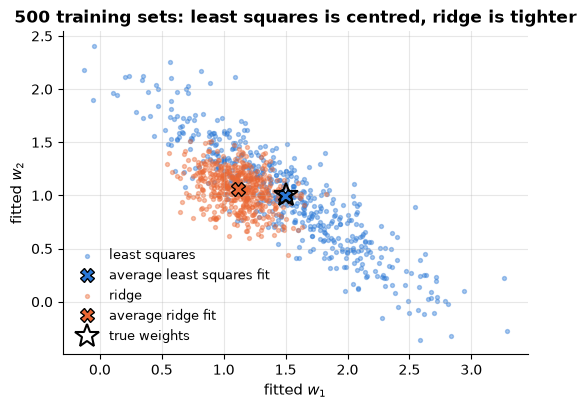

In [142]:
from sklearn import linear_model   # scikit-learn's linear models; Ridge(alpha) adds alpha * ||w||^2 (section 4.4)

rng_demo = np.random.default_rng(0)   # its own seeded generator: reproducible, and the notebook's rng is left untouched
w_true_2d = np.array([1.5, 1.0])
ols_fits, ridge_fits = [], []
# e.g. 20 weeks of a shop's radio and TV advertising spend (correlated: planned together) and its
# sales; 500 such data sets
for _ in range(500):                                   # 500 independent training sets of 20 rows
    x_first = rng_demo.normal(size=20)                 # feature 1; feature 2 below is feature 1 plus a little noise
    X_sim = np.column_stack([x_first, x_first + 0.5 * rng_demo.normal(size=20)])   # column_stack: arrays as columns
    y_sim = X_sim @ w_true_2d + rng_demo.normal(size=20)                           # true weights plus N(0, 1) noise
    # LinearRegression is ordinary least squares; fit_intercept=False as the data have no intercept; .coef_ = weights
    ols_fits.append(linear_model.LinearRegression(fit_intercept=False).fit(X_sim, y_sim).coef_)
    ridge_fits.append(linear_model.Ridge(alpha=5.0, fit_intercept=False).fit(X_sim, y_sim).coef_)

fig, ax = plt.subplots(figsize=(6, 4.2))
for fits, method, colour in [(np.array(ols_fits), "least squares", PALETTE[0]),
                             (np.array(ridge_fits), "ridge", PALETTE[1])]:
    bias_sq = np.sum((fits.mean(axis=0) - w_true_2d) ** 2)      # squared distance from the average fit to the truth
    spread = np.sum(fits.var(axis=0))                            # variance: scatter of the fits around their average
    mse = np.mean(np.sum((fits - w_true_2d) ** 2, axis=1))       # average squared distance from the truth
    print(f"{method:13s}: bias^2 {bias_sq:.3f} + variance {spread:.3f} = MSE {mse:.3f}")
    ax.scatter(fits[:, 0], fits[:, 1], s=8, alpha=0.4, color=colour, label=method)   # s = marker size, alpha = opacity
    # * unpacks the pair into x, y; mec = marker edge colour; ls="none": no line; zorder=4 draws it above the dots
    ax.plot(*fits.mean(axis=0), marker="X", ms=10, color=colour, mec="black", ls="none", zorder=4,
            label=f"average {method} fit")
# mfc="none" leaves the star hollow, so the average fit underneath stays visible; mew = marker edge width
ax.plot(*w_true_2d, marker="*", ms=18, mfc="none", mec="black", mew=1.5, ls="none", zorder=5, label="true weights")
ax.set_xlabel("fitted $w_1$")
ax.set_ylabel("fitted $w_2$")
ax.set_title("500 training sets: least squares is centred, ridge is tighter")
ax.legend(loc="lower left", fontsize=9)
plt.show()

### 4.2 Maximum likelihood

> **Key idea.** Maximum likelihood asks: *which parameter values would have made the data we actually saw most
> probable?* If 7 of 10 customers churned, a churn probability of 0.7 explains that better than 0.2 or 0.99, and 0.7
> is the maximum-likelihood estimate.

The most important estimation principle in this course (Fisher, 1922): choose the
parameters under which the observed data are most probable. For i.i.d. data
$x_1, \dots, x_n$ with a model $p(x \mid \theta)$, the **likelihood** is
$L(\theta) = \prod_i p(x_i \mid \theta)$, and because products of small numbers are
numerically hopeless and sums are easier to differentiate, we maximise the
**log-likelihood** $\ell(\theta) = \sum_i \log p(x_i \mid \theta)$:

$$
\hat\theta_{\text{MLE}} = \arg\max_\theta\, \ell(\theta) .
$$

**Bernoulli.** Observing $k$ ones among $n$ flips, $\ell(p) = k\log p + (n-k)\log(1-p)$.
Setting $\ell'(p) = k/p - (n-k)/(1-p) = 0$ gives $\hat p = k/n$: the observed frequency.

**Gaussian.** With $\ell(\mu, \sigma^2) = -\frac{n}{2}\log(2\pi\sigma^2) -
\frac{1}{2\sigma^2}\sum_i (x_i - \mu)^2$, the derivative in $\mu$ vanishes at
$\hat\mu = \bar{x}$, and the derivative in $\sigma^2$, $-\frac{n}{2\sigma^2} +
\frac{1}{2\sigma^4}\sum_i(x_i - \hat\mu)^2 = 0$, gives $\hat\sigma^2 = \frac{1}{n}\sum_i
(x_i - \bar{x})^2$ — the *biased* variance estimator of section 4.1. MLE is not
automatically unbiased; it is, under mild conditions, *consistent* (converges to the truth)
and *asymptotically efficient* (no consistent estimator has lower variance for large $n$),
which is why it is the default.

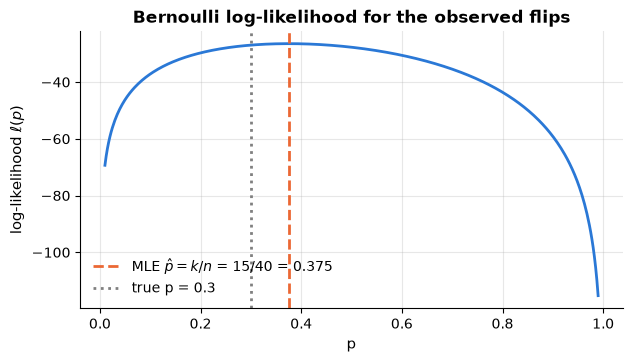

Gaussian MLE by numerical optimisation: mu = 2.0665, sigma^2 = 2.1908
closed form                           : mu = 2.0665, sigma^2 = 2.1908 (1/n, not 1/(n-1))


In [143]:
# e.g. whether each of 40 visitors clicked an advert (True = clicked)
flips = rng.random(40) < 0.3                       # 40 Bernoulli(0.3) draws
k, n = flips.sum(), len(flips)                     # number of ones (True counts as 1) and number of flips
p_grid = np.linspace(0.01, 0.99, 400)             # candidate values of p (0 and 1 excluded: log(0) is -inf)
loglik = k * np.log(p_grid) + (n - k) * np.log(1 - p_grid)    # l(p) for every candidate at once

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.plot(p_grid, loglik, lw=2)
ax.axvline(k / n, color=PALETTE[1], ls="--", label=f"MLE $\\hat p = k/n$ = {k}/{n} = {k / n:.3f}")
ax.axvline(0.3, color="gray", ls=":", label="true p = 0.3")
ax.set_xlabel("p")
ax.set_ylabel("log-likelihood $\\ell(p)$")
ax.set_title("Bernoulli log-likelihood for the observed flips")
ax.legend()
plt.show()

x_obs = rng.normal(loc=2.0, scale=1.5, size=200)     # e.g. weight lost in kg by 200 people on a diet
# .logpdf(x) is the log-density of each observation; optimising log(sigma) keeps sigma = exp(.) positive
neg_loglik = lambda theta: -np.sum(stats.norm(theta[0], np.exp(theta[1])).logpdf(x_obs))   # theta = (mu, log sigma)
# optimize.minimize(f, x0) searches numerically for the minimum of f starting from x0 (here with BFGS, the default
# for problems without bounds or constraints); it returns a result object whose .x is the minimiser
res = optimize.minimize(neg_loglik, x0=[0.0, 0.0])
mu_hat, sigma_hat = res.x[0], np.exp(res.x[1])
print(f"Gaussian MLE by numerical optimisation: mu = {mu_hat:.4f}, sigma^2 = {sigma_hat ** 2:.4f}")
print(f"closed form                           : mu = {x_obs.mean():.4f}, sigma^2 = {x_obs.var(ddof=0):.4f} (1/n, not 1/(n-1))")

**Example — three heads in four tosses.** For the tosses H, H, T, H the likelihood of a head probability $p$ is
$L(p) = p \cdot p \cdot (1 - p) \cdot p = p^3(1 - p)$, so $L(0.5) = 0.0625$, $L(0.75) = 0.75^3 \times 0.25 \approx 0.1055$
and $L(0.9) = 0.9^3 \times 0.1 = 0.0729$: the best value is the observed frequency $\hat p = 3/4$. ($L$ scores parameter
values for fixed data; it is not a probability distribution over $p$.) **Why logs:** 1 000 observations that each get
probability $0.1$ have likelihood $0.1^{1000} = 10^{-1000}$, below the smallest positive float64 (about
$5 \times 10^{-324}$), so the computed product is $0$; its logarithm, $1000 \ln 0.1 \approx -2302.6$, is an ordinary
number.

In [144]:
coin_tosses = np.array([1, 1, 0, 1])                  # H, H, T, H coded as 1 and 0
for p_head in [0.5, 0.75, 0.9]:
    # np.where(condition, a, b) takes p for every head and 1 - p for every tail; np.prod multiplies them all
    print(f"L({p_head}) = {np.prod(np.where(coin_tosses == 1, p_head, 1 - p_head)):.4f}")
probs_1000 = np.full(1000, 0.1)                       # np.full(1000, 0.1): an array of 1000 copies of 0.1
print(f"product of the 1000 probabilities: {np.prod(probs_1000)};  sum of their logs: {np.sum(np.log(probs_1000)):.1f}")
print(f"smallest positive float64: {np.finfo(float).smallest_subnormal:.0e}")   # np.finfo(float): limits of float64

L(0.5) = 0.0625
L(0.75) = 0.1055
L(0.9) = 0.0729
product of the 1000 probabilities: 0.0;  sum of their logs: -2302.6
smallest positive float64: 5e-324


> **In machine learning.**
> - **Gaussian naive Bayes is maximum likelihood.** It stores, per class and feature, the Gaussian MLEs above — the
>   class mean and the $\frac{1}{n}$ class variance, as the demo below checks on the churn data — and adds
>   log-probabilities rather than multiplying probabilities (notebook 8, §4.2).
> - **So are many other models.** Logistic and Poisson regression maximise a Bernoulli and a Poisson likelihood
>   (section 4.3; notebook 6, §8), Gaussian mixtures theirs with the EM algorithm (notebook 13, §5.2).
> - **Consistent and efficient — if the noise model is right.** With more data the MLE of a correct model homes in
>   on the truth (*consistency*), and in large samples no other consistent estimator scatters less (*efficiency*):
>   for Gaussian data the median needs about 57 % more observations than the mean for the same precision. But a few
>   outliers drag the *Gaussian* MLE — the mean, least squares — far; the median, itself the MLE under Laplace noise
>   (section 4.3), and robust losses resist them (notebook 6, §5.2).

In [145]:
from sklearn.naive_bayes import GaussianNB     # naive Bayes with one Gaussian per class and feature

nb_cols = ["tenure_months", "support_tickets"]
gnb = GaussianNB().fit(churn[nb_cols], churn["churned"])     # churn: the customer table loaded in section 3.3
# groupby("churned") splits the rows by class (0 = stayed, 1 = churned); statistics are then computed per class
class_rows = churn.groupby("churned")[nb_cols]
# theta_ and var_ are the fitted means and variances: one row per class, one column per feature;
# .tolist() turns an array into plain nested lists, which print compactly
print("theta_ (fitted means)       :", gnb.theta_.round(3).tolist())
print("class means by hand         :", class_rows.mean().round(3).to_numpy().tolist())
print("var_ (fitted variances)     :", gnb.var_.round(3).tolist())
print("1/n class variances by hand :", class_rows.var(ddof=0).round(3).to_numpy().tolist())
# epsilon_ = var_smoothing (default 1e-9) x the largest feature variance, added to every variance so that none is 0
print(f"epsilon_ = {gnb.epsilon_:.1e}")

theta_ (fitted means)       : [[33.661, 0.755], [18.267, 1.536]]
class means by hand         : [[33.661, 0.755], [18.267, 1.536]]
var_ (fitted variances)     : [[447.717, 0.9], [220.225, 1.828]]
1/n class variances by hand : [[447.717, 0.9], [220.225, 1.828]]
epsilon_ = 4.3e-07


### 4.3 Least squares is maximum likelihood; cross-entropy is negative log-likelihood

> **Key idea.** Behind many loss functions hides an assumption about the noise: squaring the errors is what maximum
> likelihood gives if the noise is Gaussian, and the cross-entropy, or log loss, is what it gives if each label is a
> biased coin flip whose probability the model predicts. Minimising such a loss *is* maximising the likelihood.

Two of the most important connections in machine learning follow from the previous
section in a few lines.

**Regression.** Assume $y_i = \mathbf{w}^\top\mathbf{x}_i + \varepsilon_i$ with Gaussian
noise $\varepsilon_i \sim \mathcal{N}(0, \sigma^2)$. Then $y_i \mid \mathbf{x}_i \sim
\mathcal{N}(\mathbf{w}^\top\mathbf{x}_i, \sigma^2)$ and

$$
\ell(\mathbf{w}) = -\frac{n}{2}\log(2\pi\sigma^2) - \frac{1}{2\sigma^2}\sum_{i=1}^n\big(y_i - \mathbf{w}^\top\mathbf{x}_i\big)^2 .
$$

The first term does not involve $\mathbf{w}$; maximising $\ell$ therefore means minimising
$\sum_i (y_i - \mathbf{w}^\top\mathbf{x}_i)^2 = \|\mathbf{X}\mathbf{w} - \mathbf{y}\|^2$.
**Least squares is the MLE under Gaussian noise.** (Laplacian noise would give least
absolute deviations; heavy-tailed noise motivates robust losses — notebook 6.)

> **Real-life example.** A weather service's errors in forecasting tomorrow's temperature come from
> many small influences and are roughly bell-shaped: squared error, the Gaussian choice, suits them.
> A taxi company's errors in predicting trip durations are mostly small, but now and then a trip
> stuck in a jam takes an hour longer; squared error would chase those rare huge errors, while the
> absolute error of heavier-tailed Laplace noise shrugs them off.

**Classification.** Assume $y_i \in \{0, 1\}$ with $P(y_i = 1 \mid \mathbf{x}_i) = p_i =
\sigma(\mathbf{w}^\top\mathbf{x}_i)$, the logistic model (the *sigmoid* $\sigma(z) = 1/(1 + e^{-z})$ turns any score into a probability; example below). The Bernoulli log-likelihood is

$$
\ell(\mathbf{w}) = \sum_{i=1}^n \big[y_i\log p_i + (1 - y_i)\log(1 - p_i)\big],
\qquad
-\frac{1}{n}\ell(\mathbf{w}) = \text{the binary cross-entropy (log loss).}
$$

**Minimising cross-entropy is maximising the Bernoulli likelihood.** Its gradient is
$\nabla_\mathbf{w}(-\ell) = \mathbf{X}^\top(\mathbf{p} - \mathbf{y})$ — derived in notebook
7 — and its Hessian is PSD, so logistic regression is a convex problem. Both facts are
easy to verify numerically: minimise the negative log-likelihoods with a generic optimiser
and compare with the specialised solvers.

In [146]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss      # the average binary cross-entropy of predicted probabilities

# --- regression: minimising the Gaussian negative log-likelihood == least squares ---
sigma_noise = 1.0
# the first term does not depend on w, so it does not move the minimum
gauss_nll = lambda w: 0.5 * n * np.log(2 * np.pi * sigma_noise ** 2) + np.sum((y_ls - X_ls @ w) ** 2) / (2 * sigma_noise ** 2)
w_mle = optimize.minimize(gauss_nll, x0=np.zeros(d)).x
w_lstsq = np.linalg.lstsq(X_ls, y_ls, rcond=None)[0]
print("Gaussian MLE :", w_mle.round(4))
print("least squares:", w_lstsq.round(4))

# --- classification: minimising the Bernoulli negative log-likelihood == logistic regression ---
sigmoid = lambda z: 1 / (1 + np.exp(-z))   # squashes any number into (0, 1)
n_c = 400
# e.g. 400 visitors of an online shop: (intercept, minutes on the site, price of the viewed item),
# standardised; y_c = 1 if the visitor bought something
X_c = np.column_stack([np.ones(n_c), rng.normal(size=(n_c, 2))])          # intercept column + 2 features
w_true = np.array([-0.5, 2.0, -1.0])
# each label is 1 with probability sigmoid(w_true . x) (a Bernoulli draw); .astype(float) turns True/False into 1.0/0.0
y_c = (rng.random(n_c) < sigmoid(X_c @ w_true)).astype(float)

def bernoulli_nll(w):
    """Negative Bernoulli log-likelihood (the summed cross-entropy) of the weights w on the data (X_c, y_c)."""
    p = np.clip(sigmoid(X_c @ w), 1e-12, 1 - 1e-12)     # np.clip keeps p away from 0 and 1, so log() stays finite
    return -np.sum(y_c * np.log(p) + (1 - y_c) * np.log(1 - p))

grad_nll = lambda w: X_c.T @ (sigmoid(X_c @ w) - y_c)    # gradient X^T (p - y)
print(f"\ngradient check for the cross-entropy gradient: relative error {relative_error(grad_nll(w_true), numerical_gradient(bernoulli_nll, w_true)):.1e}")
# jac= passes the analytic gradient to the optimiser; method="BFGS" is a quasi-Newton method
w_ce = optimize.minimize(bernoulli_nll, x0=np.zeros(3), jac=grad_nll, method="BFGS").x
logreg = LogisticRegression(C=1e12, fit_intercept=False).fit(X_c, y_c)   # huge C = (effectively) no regularisation; intercept is a column of X_c
print("minimised cross-entropy :", w_ce.round(4))
print("LogisticRegression      :", logreg.coef_[0].round(4))     # coef_ has shape (1, 3); [0] takes the row
# predict_proba returns an (n, 2) array [P(y = 0), P(y = 1)] per row; [:, 1] keeps P(y = 1)
print(f"cross-entropy per sample: by hand {bernoulli_nll(w_ce) / n_c:.5f}, sklearn log_loss {log_loss(y_c, logreg.predict_proba(X_c)[:, 1]):.5f}")

Gaussian MLE : [ 1.0794 -2.0757  0.4947  3.0463]
least squares: [ 1.0794 -2.0757  0.4947  3.0463]

gradient check for the cross-entropy gradient: relative error 7.5e-11
minimised cross-entropy : [-0.4143  2.3131 -1.2272]
LogisticRegression      : [-0.4142  2.3128 -1.2269]
cross-entropy per sample: by hand 0.39780, sklearn log_loss 0.39780


**The sigmoid and the log-odds.** The sigmoid $\sigma(z) = 1/(1 + e^{-z})$, already met in the neuron example of
section 2.1, turns a score $z = \mathbf{w}^\top\mathbf{x}$ of any size into a probability: $\sigma(0) = 1/(1 + 1) = 0.5$
("no idea"), $\sigma(2) = 1/(1 + e^{-2}) \approx 0.881$ and $\sigma(-2) = 1 - \sigma(2) \approx 0.119$. Its inverse is
the **logit**, or *log-odds*, $z = \ln\frac{p}{1 - p}$: $p = 0.881$ means odds of $0.881/0.119 \approx 7.4$ to 1, and
$\ln 7.4 \approx 2$. So the logistic model says that the log-odds of $y = 1$ are linear in $\mathbf{x}$ (notebook 7,
§1.2); for more than two classes the sigmoid becomes the softmax (section 5.3).

> **Real-life example.** Medical studies report risk factors as odds ratios, and logistic regression
> produces them directly: a weight of 0.69 on "smoker" adds 0.69 to the log-odds of a disease, which
> multiplies the odds by about 2 (e to the power 0.69), whatever the patient's other
> characteristics. A patient at odds of 1 to 9 (probability 0.10) moves to 2 to 9 (probability 0.18)
> as a smoker.

**Example — log loss of three predictions.** A model gives three customers who all churned ($y = 1$) the churn
probabilities 0.9, 0.6 and 0.1. Their losses are $-\ln 0.9 \approx 0.105$ (confident and right: tiny),
$-\ln 0.6 \approx 0.511$ (hesitant) and $-\ln 0.1 \approx 2.303$ (confident and wrong: 22 times the first); the log
loss is their average, $(0.105 + 0.511 + 2.303)/3 \approx 0.973$.

sigmoid(+0) = 0.500
sigmoid(+2) = 0.881
sigmoid(-2) = 0.119
log-odds of p = 0.881: ln(p / (1 - p)) = 2.000   <- back to the score 2
losses -ln p: [0.105 0.511 2.303]   mean 0.973
sklearn log_loss: 0.973


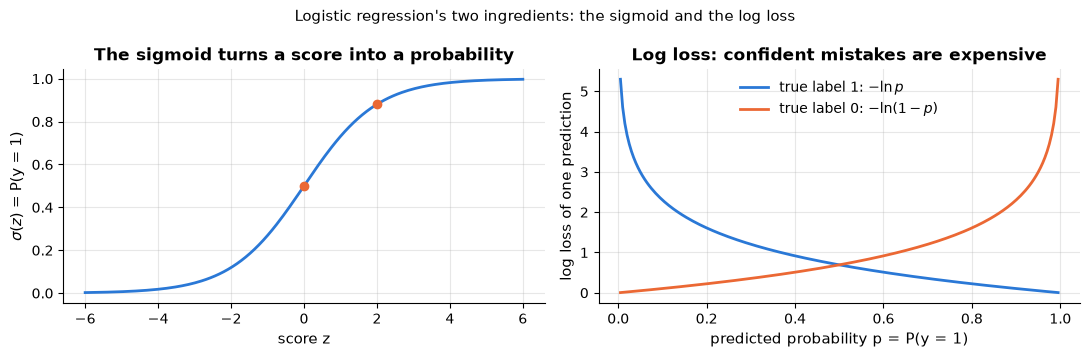

In [147]:
# sigmoid and log_loss come from the first code cell of section 4.3, above
for z_score in [0.0, 2.0, -2.0]:
    print(f"sigmoid({z_score:+.0f}) = {sigmoid(z_score):.3f}")
p_two = sigmoid(2.0)
print(f"log-odds of p = {p_two:.3f}: ln(p / (1 - p)) = {np.log(p_two / (1 - p_two)):.3f}   <- back to the score 2")
churner_probs = np.array([0.9, 0.6, 0.1])          # predicted P(churn) for three customers who all churned
print("losses -ln p:", (-np.log(churner_probs)).round(3), f"  mean {-np.log(churner_probs).mean():.3f}")
# labels=[0, 1] tells log_loss that class 0 exists, although all three true labels are 1
print(f"sklearn log_loss: {log_loss([1, 1, 1], churner_probs, labels=[0, 1]):.3f}")

score_grid = np.linspace(-6, 6, 200)
p_axis = np.linspace(0.005, 0.995, 200)                    # predicted probabilities (0 and 1 excluded: log(0) = -inf)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))          # two panels side by side
axes[0].plot(score_grid, sigmoid(score_grid), color=PALETTE[0], lw=2)
axes[0].plot([0, 2], sigmoid(np.array([0.0, 2.0])), "o", color=PALETTE[1])   # sigma(0) = 0.5 and sigma(2) = 0.881
axes[0].set_xlabel("score z")
axes[0].set_ylabel("$\\sigma(z)$ = P(y = 1)")
axes[0].set_title("The sigmoid turns a score into a probability")
axes[1].plot(p_axis, -np.log(p_axis), color=PALETTE[0], lw=2, label="true label 1: $-\\ln p$")
axes[1].plot(p_axis, -np.log(1 - p_axis), color=PALETTE[1], lw=2, label="true label 0: $-\\ln(1 - p)$")
axes[1].set_xlabel("predicted probability p = P(y = 1)")
axes[1].set_ylabel("log loss of one prediction")
axes[1].set_title("Log loss: confident mistakes are expensive")
axes[1].legend()
fig.suptitle("Logistic regression's two ingredients: the sigmoid and the log loss", fontsize=11)
plt.tight_layout()
plt.show()

> **In machine learning.** For these losses, choosing a loss means choosing a noise model:
> - **Squared error ↔ Gaussian noise, absolute error ↔ Laplace noise.** `LinearRegression` and `Ridge` assume the
>   first (notebook 6); the Laplace density, proportional to $e^{-|x - \mu|/b}$ — a sharp peak with heavier tails than the
>   Gaussian's — makes outliers less surprising. The best constant
>   prediction for 200, 210, 220, 230 and 1000 is their mean, 372, under squared error but their median, 220, under
>   absolute error (`loss="absolute_error"` in gradient boosting; Huber's loss, notebook 6, §5.2, is a compromise).
> - **Log loss ↔ Bernoulli labels.** `LogisticRegression` minimises it (notebook 7, §2.1), and it is the standard
>   score of predicted probabilities (notebook 7, §7.1). Its gradient $\mathbf{X}^\top(\mathbf{p} - \mathbf{y})$ is
>   "error × feature", like the least-squares gradient (section 2.2); the neuron of section 2.1 computes it for one
>   example.
> - **Poisson deviance ↔ counts.** The Poisson deviance, twice the Poisson negative log-likelihood up to a
>   constant, is what `PoissonRegressor` minimises (notebook 6, §8).

### 4.4 Maximum a posteriori estimation: regularisation as a prior

> **Key idea.** Maximum likelihood trusts the data completely. MAP estimation also uses what we believed *before*
> seeing them — the **prior** — and combines the two into the **posterior**: with little data the prior keeps the
> estimate sensible, with lots of data the data win. In machine learning the prior is the regularisation penalty.

Bayes' theorem applied to parameters says $p(\mathbf{w} \mid \mathcal{D}) \propto
p(\mathcal{D} \mid \mathbf{w})\,p(\mathbf{w})$. The **maximum a posteriori** (MAP) estimate
maximises the posterior, i.e. $\log p(\mathcal{D} \mid \mathbf{w}) + \log p(\mathbf{w})$.
With the Gaussian regression likelihood of section 4.3 and a Gaussian prior
$\mathbf{w} \sim \mathcal{N}(\mathbf{0}, \tau^2\mathbf{I})$, whose log-density is
$-\|\mathbf{w}\|_2^2 / (2\tau^2)$ plus a constant, the MAP objective is

$$
\min_\mathbf{w}\ \frac{1}{2\sigma^2}\|\mathbf{X}\mathbf{w} - \mathbf{y}\|_2^2 + \frac{1}{2\tau^2}\|\mathbf{w}\|_2^2
\;\;\Longleftrightarrow\;\;
\min_\mathbf{w}\ \|\mathbf{X}\mathbf{w} - \mathbf{y}\|_2^2 + \lambda\|\mathbf{w}\|_2^2, \quad \lambda = \sigma^2/\tau^2 .
$$

This is **ridge regression** (notebook 6). A Laplace prior $p(w_j) \propto e^{-|w_j|/b}$
gives the $\ell_1$ penalty of the **lasso** instead. Regularisation, then, is a statement of
prior belief that the weights are small — and the strength $\lambda$ trades the prior
against the data: noisier data (larger $\sigma^2$) or a firmer belief in small weights (smaller $\tau^2$) mean a
larger $\lambda$. The data term is a sum over the $n$ observations and grows with $n$, while the penalty does not,
so the prior's influence fades as data accumulate: with few observations it matters a lot, with many the MAP
estimate approaches the MLE.

In [148]:
from sklearn.linear_model import Ridge   # least squares plus the penalty alpha * ||w||^2

lam = 5.0
map_objective = lambda w: np.sum((y_ls - X_ls @ w) ** 2) + lam * np.sum(w ** 2)   # ||X w - y||^2 + lambda ||w||^2
w_map = optimize.minimize(map_objective, x0=np.zeros(d)).x
w_ridge = Ridge(alpha=lam, fit_intercept=False).fit(X_ls, y_ls).coef_   # alpha is scikit-learn's name for lambda
print("MAP with a Gaussian prior:", w_map.round(4))
print("Ridge(alpha = 5)         :", w_ridge.round(4))
print("unregularised MLE        :", w_lstsq.round(4), "<- the prior pulls every weight towards 0")

MAP with a Gaussian prior: [ 0.96   -1.9524  0.4434  2.752 ]
Ridge(alpha = 5)         : [ 0.96   -1.9524  0.4434  2.752 ]
unregularised MLE        : [ 1.0794 -2.0757  0.4947  3.0463] <- the prior pulls every weight towards 0


**Example — three heads in three tosses.** The MLE of the head probability is $\hat p = 3/3 = 1$: it declares tails
impossible. Add the mild prior belief that the coin is roughly fair, a Beta(2, 2) prior with density proportional to
$p(1 - p)$, which is worth one imaginary head and one imaginary tail. The posterior is proportional to
$p^3 \cdot p(1 - p) = p^4(1 - p)$, which is largest at $\hat p_{\text{MAP}} = (3 + 1)/(3 + 2) = 0.8$. After 210 heads in
300 tosses the same prior hardly matters: MLE $0.7$, MAP $211/302 \approx 0.699$.

> **Real-life example.** A restaurant guide receives the first three reviews of a new restaurant,
> all of them positive. Maximum likelihood rates it 100 % positive, above a place with 300 reviews
> of which 95 % are positive. A prior centred on the typical share of positive reviews across all
> restaurants pulls the newcomer's estimate towards that share and lets its own reviews take over as
> they accumulate.

In [149]:
p_candidates = np.linspace(0.001, 0.999, 999)               # candidate head probabilities, in steps of 0.001
for heads, tosses in [(3, 3), (210, 300)]:
    log_lik = heads * np.log(p_candidates) + (tosses - heads) * np.log(1 - p_candidates)   # Bernoulli log-likelihood
    log_prior = np.log(p_candidates) + np.log(1 - p_candidates)     # log of p (1 - p): Beta(2, 2), up to a constant
    # posterior = likelihood x prior, so its log is a sum; np.argmax gives the position of the largest value
    print(f"{heads:3d} heads in {tosses:3d} tosses: MLE k/n = {heads / tosses:.3f}, "
          f"MAP = {p_candidates[np.argmax(log_lik + log_prior)]:.3f}")

  3 heads in   3 tosses: MLE k/n = 1.000, MAP = 0.800
210 heads in 300 tosses: MLE k/n = 0.700, MAP = 0.699


> **In machine learning.** Penalised models are MAP estimates: the penalty is the negative log of the prior.
> - **Ridge versus lasso.** A Gaussian prior expects small weights: ridge shrinks them all a little. A Laplace prior
>   is sharply peaked at 0: the lasso sets many weights exactly to zero, selecting features (notebook 6, §7.2–7.3),
>   as the demo below shows with 3 useful features out of 10.
> - **`C` is the inverse prior strength.** `LogisticRegression` uses `C` $= 1/\lambda$ (notebook 7, §3.1): small `C`,
>   strong prior. Any finite `C` keeps the weights finite when the classes are perfectly separable and the MLE does
>   not exist (notebook 7, §9.2). $\lambda$ itself is tuned by cross-validation (notebook 6, §7.4).
> - **Smoothing is a prior.** `MultinomialNB(alpha=1)` adds one imaginary occurrence of every word to every class,
>   like the imaginary head and tail above, so a word unseen in one class's training texts does not get probability 0
>   (notebook 8, §4.3).

In [150]:
from sklearn.linear_model import Lasso    # least squares (divided by 2n) plus the penalty alpha * ||w||_1

rng_demo = np.random.default_rng(0)   # its own seeded generator: reproducible, and the notebook's rng is left untouched
# e.g. 100 wheat fields x 10 soil measurements, of which only 3 affect the yield (y_sparse)
X_sparse = rng_demo.normal(size=(100, 10))                      # 100 rows, 10 features
w_sparse = np.array([3.0, -2.0, 1.5, 0, 0, 0, 0, 0, 0, 0])     # only the first 3 features matter
y_sparse = X_sparse @ w_sparse + rng_demo.normal(size=100)
# Ridge was imported in the first code cell of section 4.4; the two alphas are on different scales (the lasso
# divides the squared error by 2n, ridge does not)
for model in [Ridge(alpha=10.0), Lasso(alpha=0.1)]:
    fitted = model.fit(X_sparse, y_sparse).coef_
    # type(model).__name__ is the class name; + 0.0 prints -0.0 as 0.0; == 0 finds the exactly-zero weights
    print(f"{type(model).__name__:5s}: {np.round(fitted, 2) + 0.0}   exact zeros: {np.sum(fitted == 0)}")

Ridge: [ 2.83 -1.9   1.2  -0.03 -0.02 -0.09 -0.09  0.12  0.01  0.03]   exact zeros: 0
Lasso: [ 3.08 -1.99  1.27  0.    0.    0.    0.    0.    0.    0.  ]   exact zeros: 7


### 4.5 Confidence intervals and the bootstrap

> **Key idea.** An error bar says how much a number computed from data could change with a different sample. A 95 %
> confidence interval is a range built by a recipe that catches the true value in 95 % of samples; the bootstrap finds
> such a range by treating the sample as if it were the population and re-drawing from it.

A point estimate without a measure of uncertainty is a guess. A **95 % confidence
interval** for a parameter is an interval computed from the data by a procedure that, over
repeated samples, contains the true value 95 % of the time. (It is a statement about the
*procedure*; any particular interval either contains the truth or does not.) For the mean,
the CLT gives the standard error $s/\sqrt{n}$ and the interval

$$
\bar{x} \;\pm\; 1.96\,\frac{s}{\sqrt{n}} .
$$

This formula needs $n$ large enough for the CLT to have kicked in, and there is no such
formula for most other statistics — a median, a correlation, the test accuracy of a
model. The **bootstrap** (Efron, 1979) replaces the theory with computation: since we
cannot draw new samples from the population, we treat the sample as the population and
draw new samples *from it*, with replacement.

1. For $b = 1, \dots, B$: draw $n$ observations with replacement from the data and compute
   the statistic $\hat\theta^{*}_b$ on the resample.
2. The spread of $\{\hat\theta^{*}_b\}$ estimates the sampling distribution of $\hat\theta$;
   the 2.5 % and 97.5 % quantiles give a **percentile interval**.

It works for any statistic, and it is how later notebooks put error bars on model scores.
Let us check both methods honestly by measuring their *coverage* on small, skewed samples,
where the CLT is shaky.

In [151]:
def analytic_ci(sample):
    """95 % confidence interval for the mean from the CLT: mean +- 1.96 standard errors. Returns (low, high)."""
    m, se = sample.mean(), sample.std(ddof=1) / np.sqrt(len(sample))    # standard error s / sqrt(n)
    return m - 1.96 * se, m + 1.96 * se

def bootstrap_ci(sample, statistic=np.mean, n_boot=1000, rng=rng):
    """95 % bootstrap percentile interval for statistic(sample). Returns (low, high).

    statistic must accept an axis argument (np.mean, np.median, ...). The default rng=rng is evaluated
    once, when the function is defined, so it is the notebook's seeded generator.
    """
    # an (n_boot, n) array: each row is one resample of the data, drawn with replacement
    resamples = rng.choice(sample, size=(n_boot, len(sample)), replace=True)
    boot_stats = statistic(resamples, axis=1)          # one statistic per resample -> (n_boot,)
    return tuple(np.percentile(boot_stats, [2.5, 97.5]))   # the bounds of the middle 95 %

true_mean, n_reps = 1.0, 300
for n in [15, 200]:
    hits = {"analytic": 0, "bootstrap": 0}             # how often each interval contains the true mean
    for _ in range(n_reps):
        # e.g. emergency-department waiting times in hours: a few very long waits make them skewed
        sample = rng.exponential(scale=true_mean, size=n)          # skewed population, true mean 1
        # a chained comparison low <= x <= high; True adds 1 to the count
        hits["analytic"] += analytic_ci(sample)[0] <= true_mean <= analytic_ci(sample)[1]
        lo, hi = bootstrap_ci(sample)
        hits["bootstrap"] += lo <= true_mean <= hi
    print(f"n = {n:3d}: coverage of the nominal 95% interval — analytic {hits['analytic'] / n_reps:.1%}, "
          f"bootstrap percentile {hits['bootstrap'] / n_reps:.1%}")

# e.g. 60 recorded waiting times: an interval for their median needs the bootstrap
sample = rng.exponential(scale=1.0, size=60)
print(f"\nmedian of one sample of 60: {np.median(sample):.3f}, bootstrap 95% CI {np.round(bootstrap_ci(sample, statistic=np.median), 3)}"
      "  (no simple formula exists for this one)")

n =  15: coverage of the nominal 95% interval — analytic 89.3%, bootstrap percentile 89.3%
n = 200: coverage of the nominal 95% interval — analytic 95.0%, bootstrap percentile 95.3%

median of one sample of 60: 0.802, bootstrap 95% CI [0.524 1.293]  (no simple formula exists for this one)


Both intervals under-cover for tiny skewed samples — neither method is magic, and the
bootstrap in particular needs a sample that is representative of the population — but with
$n = 200$ both are close to the nominal 95 %.

**Example — a bootstrap by hand.** The sample $(1, 2, 3, 4, 10)$ has mean 4. Drawing five values from it *with
replacement* gave the resample $(3, 3, 4, 10, 1)$ below, with mean 4.2: some values appear twice, others not at all.
Two more resamples have means 5.0 and 5.4. Repeating the draw 2000 times and keeping the middle 95 % of the resample
means gives the **percentile interval** $[1.8, 7.0]$. Unlike $\bar{x} \pm 1.96\,s/\sqrt{n}$ it need not be
symmetric: the 10 pulls some resample means far up, so the interval reaches 3.0 above the estimate but only 2.2 below.

In [152]:
rng_demo = np.random.default_rng(1)   # its own seeded generator: reproducible, and the notebook's rng is left untouched
five_values = np.array([1, 2, 3, 4, 10])
for _ in range(3):
    # choice(values, size, replace=True) draws with replacement: the same value can be picked several times
    one_resample = rng_demo.choice(five_values, size=5, replace=True)
    print("resample:", one_resample, "  mean:", one_resample.mean())
# bootstrap_ci (defined above) takes (sample, statistic, n_boot, generator): 2000 resamples drawn with rng_demo
ci_low, ci_high = bootstrap_ci(five_values, np.mean, 2000, rng_demo)
print(f"95% percentile interval for the mean: [{ci_low:.1f}, {ci_high:.1f}]")

resample: [ 3  3  4 10  1]   mean: 4.2
resample: [ 1 10 10  2  2]   mean: 5.0
resample: [10  3  2 10  2]   mean: 5.4
95% percentile interval for the mean: [1.8, 7.0]


> **In machine learning.**
> - **Error bars for any score.** A test accuracy has a formula for its standard error (section 3.5); the AUC (how well
>   the scores rank positives above negatives, notebook 7, §6.3) or a median error have no simple one, but resampling the test cases and recomputing the score gives an interval for
>   any of them (notebook 20, §7 does so for several metrics, and for the model's gain over a simple heuristic). The
>   demo below checks that, for an accuracy, the bootstrap and the CLT interval closely agree.
> - **Bagging is bootstrap aggregating.** A random forest trains each tree on a bootstrap sample of the rows; the
>   roughly 37 % of rows a tree never saw give a free *out-of-bag* error estimate (notebook 10, §2.1 and §2.5).
> - **Coefficient uncertainty.** Bootstrapping the rows of a data set gives intervals for regression coefficients
>   without any formula (notebook 6, §3.2).

In [153]:
from sklearn import datasets                            # scikit-learn's built-in example data sets
from sklearn.model_selection import train_test_split    # one random split into training and test rows

# return_X_y=True returns plain arrays: the (569, 30) features of the tumours and their 0/1 labels
X_cancer, y_cancer = datasets.load_breast_cancer(return_X_y=True)
# test_size=0.3 holds out 30 % of the rows; stratify=y_cancer keeps the class proportions equal in both parts
X_tr_bc, X_te_bc, y_tr_bc, y_te_bc = train_test_split(X_cancer, y_cancer, test_size=0.3, stratify=y_cancer,
                                                      random_state=RANDOM_STATE)
nb_cancer = GaussianNB().fit(X_tr_bc, y_tr_bc)                       # GaussianNB: imported in section 4.2
# .predict returns the predicted class of every test row; the comparison gives 1.0 for every correct prediction
correct = (nb_cancer.predict(X_te_bc) == y_te_bc).astype(float)
print(f"test accuracy {correct.mean():.3f} on {len(correct)} test cases")
print("95% CI from the CLT :", np.round(analytic_ci(correct), 3))   # analytic_ci, bootstrap_ci: defined in 4.5 above
# arguments (sample, statistic, n_boot, generator): 2000 resamples of the test cases, drawn with a fresh generator
print("95% CI by bootstrap :", np.round(bootstrap_ci(correct, np.mean, 2000, np.random.default_rng(7)), 3))

test accuracy 0.947 on 171 test cases
95% CI from the CLT : [0.914 0.981]
95% CI by bootstrap : [0.912 0.977]


### 4.6 Hypothesis tests on model scores, and why to be careful

> **Key idea.** A hypothesis test plays devil's advocate: *suppose nothing is going on* (the null hypothesis) — how
> surprising would data like ours be? That surprise, as a probability, is the $p$-value. A small $p$ says that data like
> ours would rarely arise by chance alone; it does not say how probable the null hypothesis is, nor how large or
> important the effect is.

Is model A really better than model B, or did it win by chance on this data? The
statistician's answer is a **hypothesis test**: assume the *null hypothesis* $H_0$ that
there is no difference, compute a test statistic, and report the $p$-value — the
probability, under $H_0$, of a statistic at least as extreme as the one observed. A small
$p$ (conventionally $< 0.05$) is taken as evidence against $H_0$. For two models evaluated
on the same $k$ cross-validation folds the natural choice is the **paired $t$-test** on the
$k$ score differences $d_j$: $t = \bar{d} / (s_d / \sqrt{k})$, compared with a $t$
distribution with $k - 1$ degrees of freedom.

The caveat, spelled out by Dietterich (1998), is that the test assumes the $k$ differences
are independent, and they are not: the training sets of different folds overlap heavily,
so the scores are positively correlated, the variance is underestimated and the test
rejects $H_0$ too often — much more so with repeated cross-validation, where 100
"observations" are really re-uses of the same 569 rows. Dietterich recommends the
$5 \times 2$-fold CV $t$-test instead; Nadeau & Bengio (2003) give a corrected variance for
repeated CV. In practice: report means *with standard errors*, treat $p$-values on CV folds
as rough guides, and remember that a statistically significant difference of 0.2 % may be
practically irrelevant. Notebook 12 returns to this when comparing tuned models.

**Example — is this coin fair?** First the mechanics, on the simplest case: 100 tosses give 60 heads. The null
hypothesis $H_0$: the coin is fair. The test statistic: the number of heads, which under $H_0$ is Binomial(100, 0.5),
with mean 50 and standard deviation $\sqrt{100 \times 0.5 \times 0.5} = 5$, so 60 lies two standard deviations
above the mean. The two-sided $p$-value is the probability of a result at least that far from 50 in either
direction, $P(X \ge 60) + P(X \le 40) \approx 0.057$. At the usual **significance level** $\alpha = 0.05$ we do *not*
reject $H_0$; 61 heads would give $p \approx 0.035$, and we would. The cut-off is a convention, not a law of nature.

In [154]:
# stats.binomtest(k, n, p) is an exact test of "the success probability is p"; .pvalue is two-sided by default
for n_heads in [60, 61]:
    print(f"{n_heads} heads in 100 tosses: p-value {stats.binomtest(n_heads, n=100, p=0.5).pvalue:.3f}")
fair_coin = stats.binom(100, 0.5)       # the distribution of the number of heads under H0
# .sf(x) is the survival function 1 - cdf(x) = P(X > x), so .sf(59) = P(X >= 60); .cdf(40) = P(X <= 40)
print(f"by hand: P(X >= 60) + P(X <= 40) = {fair_coin.sf(59) + fair_coin.cdf(40):.3f}")

60 heads in 100 tosses: p-value 0.057
61 heads in 100 tosses: p-value 0.035
by hand: P(X >= 60) + P(X <= 40) = 0.057


In [155]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import StratifiedKFold, RepeatedStratifiedKFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

X_bc, y_bc = load_breast_cancer(return_X_y=True)     # the (569, 30) features and the labels as plain arrays
# make_pipeline chains the steps like Pipeline but names them automatically; StandardScaler gives every feature
# mean 0 and standard deviation 1, learned on the training folds only
model_a = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
model_b = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5))   # majority vote of the 5 nearest points

# 10 folds that keep the class proportions; cross_val_score returns one accuracy per fold
cv10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
scores_a = cross_val_score(model_a, X_bc, y_bc, cv=cv10)
scores_b = cross_val_score(model_b, X_bc, y_bc, cv=cv10)
diff = scores_a - scores_b                            # per-fold differences (both models used the same folds)
t_stat, p_value = stats.ttest_rel(scores_a, scores_b)   # paired t-test: returns the t statistic and two-sided p-value
print(f"10-fold CV accuracy: logistic regression {scores_a.mean():.4f} ± {scores_a.std(ddof=1) / np.sqrt(10):.4f} (s.e.), "
      f"kNN {scores_b.mean():.4f} ± {scores_b.std(ddof=1) / np.sqrt(10):.4f}")
print(f"paired t-test on 10 folds : mean difference {diff.mean():+.4f}, t = {t_stat:.2f}, p = {p_value:.3f}")

# 10-fold CV repeated 10 times with different shuffles -> 100 scores per model
rcv = RepeatedStratifiedKFold(n_splits=10, n_repeats=10, random_state=RANDOM_STATE)
rep_a = cross_val_score(model_a, X_bc, y_bc, cv=rcv)
rep_b = cross_val_score(model_b, X_bc, y_bc, cv=rcv)
t_rep, p_rep = stats.ttest_rel(rep_a, rep_b)
print(f"paired t-test on 100 repeated-CV scores: mean difference {(rep_a - rep_b).mean():+.4f}, t = {t_rep:.2f}, p = {p_rep:.2g}"
      "   <- overconfident: the 100 scores are not independent")

10-fold CV accuracy: logistic regression 0.9754 ± 0.0065 (s.e.), kNN 0.9701 ± 0.0059
paired t-test on 10 folds : mean difference +0.0053, t = 1.16, p = 0.277
paired t-test on 100 repeated-CV scores: mean difference +0.0097, t = 4.22, p = 5.5e-05   <- overconfident: the 100 scores are not independent


On ten folds the half-point difference between the two models is well within noise
($p \approx 0.3$); the very same comparison on 100 repeated-CV scores comes out as
"highly significant". Nothing about the models changed — only the number of correlated
observations the test was fed.

**The paired $t$-test, by hand.** The statistic $t = \bar d / (s_d / \sqrt{k})$ is the mean fold difference measured
in units of its standard error. If the two models were equally good (and the differences independent and roughly
Gaussian), $t$ would follow a **$t$ distribution with $k - 1 = 9$ degrees of freedom**: bell-shaped like the standard
normal, but with heavier tails, because $s_d$ is itself estimated from only 10 numbers. The degrees of freedom count
the independent pieces of information in $s_d$: the 10 deviations from their mean always sum to zero, so only 9 are
free — the reason the unbiased variance divides by $n - 1$ (section 4.1). With 9 degrees of freedom the 97.5 %
quantile is 2.262 instead of 1.96, so $|t|$ would have to exceed 2.262 for $p < 0.05$; the observed $t = 1.16$ is far
from it. Regression coefficients get their $p$-values the same way, from a $t$ distribution with $n$ minus the number
of coefficients (intercept included) as degrees of freedom (notebook 6, §3.2).

In [156]:
# diff: the 10 per-fold accuracy differences from the cross-validation cell above
t_by_hand = diff.mean() / (diff.std(ddof=1) / np.sqrt(len(diff)))    # mean difference / its standard error
t_dist = stats.t(df=len(diff) - 1)                   # Student's t distribution with k - 1 = 9 degrees of freedom
# two-sided p-value: P(|T| >= |t|), twice the upper tail .sf (stats.ttest_rel above gave the same)
print(f"t = {t_by_hand:.2f}, two-sided p = {2 * t_dist.sf(abs(t_by_hand)):.3f}")
# .ppf, the inverse of the CDF, gives the value below which 97.5 % of each distribution lies
print(f"97.5% quantile: t (9 degrees of freedom) {t_dist.ppf(0.975):.3f}, normal {stats.norm.ppf(0.975):.3f}")

t = 1.16, two-sided p = 0.277
97.5% quantile: t (9 degrees of freedom) 2.262, normal 1.960


**Multiple comparisons.** When the null hypothesis is true, a test still comes out "significant" at $\alpha = 0.05$
one time in 20, by luck alone. Test 100 useless features and about 5 will pass; the chance that at least one passes
is $1 - 0.95^{100} \approx 0.994$ for independent tests. Below, 100 features of pure noise are each tested against
an unrelated target, as a filter method for feature selection does. The simplest remedy, the **Bonferroni
correction**, tests each of $m$ hypotheses at $\alpha / m$ (here $0.05/100 = 0.0005$), which keeps the chance of even
one false discovery at most $\alpha$; scikit-learn's `SelectFwe` applies exactly that rule.

> **Real-life example.** Genome-wide association studies test about a million genetic variants, one
> at a time, for a link with a disease. At the 0.05 level tens of thousands of variants would pass
> by chance alone, so the field calls a variant significant only if p < 5 × 10⁻⁸ — the Bonferroni
> threshold 0.05 / 1 000 000.

In [157]:
from sklearn.feature_selection import f_regression, SelectFpr, SelectFwe   # one-feature-at-a-time tests and filters

rng_demo = np.random.default_rng(4)   # its own seeded generator: reproducible, and the notebook's rng is left untouched
# e.g. 100 blood markers measured on 200 patients, and a symptom score unrelated to all of them
noise_features = rng_demo.normal(size=(200, 100))     # 200 rows, 100 features of pure noise
noise_target = rng_demo.normal(size=200)              # a target unrelated to every one of them
# f_regression tests each feature on its own ("no linear relation with the target"): returns (F statistics, p-values)
_, p_values = f_regression(noise_features, noise_target)
print(f"p < 0.05 for {np.sum(p_values < 0.05)} of the 100 useless features (smallest p = {p_values.min():.4f})")
# SelectFpr keeps every feature with p < alpha; SelectFwe uses alpha / (number of features): the Bonferroni rule
for selector in [SelectFpr(f_regression, alpha=0.05), SelectFwe(f_regression, alpha=0.05)]:
    n_kept = selector.fit(noise_features, noise_target).get_support().sum()   # get_support(): True = feature kept
    print(f"{type(selector).__name__}(alpha=0.05) keeps {n_kept} features")

p < 0.05 for 5 of the 100 useless features (smallest p = 0.0065)
SelectFpr(alpha=0.05) keeps 5 features
SelectFwe(alpha=0.05) keeps 0 features


> **In machine learning.**
> - **Compare models in pairs.** On the same folds or test cases two models meet the same easy and hard cases, so
>   their score *differences* cancel that luck (notebook 12, §6.3 tests them with the corrected $t$-test of Nadeau &
>   Bengio, 2003; notebook 20, §7 bootstraps them).
> - **Picking the best of many is a multiple comparison.** The best of hundreds of features screened one at a time
>   (notebook 4, §7.1) or of hyper-parameter settings (notebook 12, §6.1) is partly the luckiest, so its score is
>   optimistic. Remedies: corrections such as `SelectFwe`, nested cross-validation (tuning repeated inside every outer
>   fold) and a test set used only once
>   (notebook 5, §4.4).
> - **Statistical is not practical significance.** On a million test cases, 90.1 % accuracy beats a 90.0 % benchmark
>   by 3.3 standard errors ($\sqrt{0.9 \times 0.1 / 10^6} = 0.0003$, section 3.5), so $p < 0.001$; whether 0.1 points
>   justify a more complex model is a business question.

## 5. Information theory

> **Key idea.** Information theory puts numbers on uncertainty: how unpredictable an outcome is, how far a believed
> distribution is from the true one, and how much knowing one variable tells you about another.
> Machine learning uses these measurements to train and judge classifiers, grow decision trees, rank features and
> notice when new data drift away from the training data.

### 5.1 Entropy

> **Key idea.** Information is measured by *surprise*: learning that a one-in-a-thousand event happened tells you far
> more than learning that a near-certain one did. Entropy is the *average* surprise of a random outcome — how
> unpredictable it is, roughly the number of yes/no questions needed on average to find it out. Labels that all agree
> have entropy 0; an even mix has the most.

Shannon (1948) asked how much information a random outcome carries, and answered with a
single number. The **surprise** of an outcome with probability $p$ is $-\log p$ (rare
events are more surprising; certain events carry no information), and the **entropy** of a
distribution is the expected surprise,

$$
H(p) \;=\; -\sum_x p(x)\log p(x) \;=\; \mathbb{E}[-\log p(X)] .
$$

With $\log_2$ the unit is *bits*, with $\ln$ it is *nats*; the convention $0\log 0 = 0$
applies. Entropy is $0$ for a certain outcome and maximal, $\log K$, for a uniform
distribution over $K$ outcomes; it is the minimum average number of bits needed to encode
outcomes drawn from $p$ (MacKay, 2003). For a binary variable, $H(p) = -p\log_2 p -
(1-p)\log_2(1-p)$ peaks at one bit when $p = 1/2$ — a fair coin is the most unpredictable
binary variable. In machine learning entropy measures the *impurity* of a set of labels:
decision trees (notebook 9) choose the split that reduces it most.

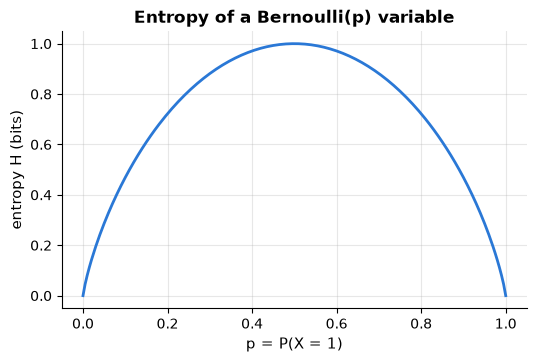

churn label: P(churned = 1) = 0.326 -> H = 0.911 bits (max 1 bit)
contract type {'Month-to-month': 0.559, 'One year': 0.244, 'Two year': 0.197} -> H = 1.427 bits (max log2(3) = 1.585)
uniform over 8 outcomes: H = 3.0 bits; a certain outcome: H = 0.0 bits


In [158]:
def entropy(p, base=2):
    """Entropy -sum p log p of the probability vector p, in bits by default (base=2; base=np.e gives nats)."""
    p = np.asarray(p, dtype=float)
    p = p[p > 0]                                   # 0 log 0 = 0
    # dividing by log(base) converts the natural log into a log to that base
    return float(-np.sum(p * np.log(p)) / np.log(base)) + 0.0     # + 0.0 turns -0.0 into 0.0

ps = np.linspace(0, 1, 201)
fig, ax = plt.subplots(figsize=(6, 3.6))
ax.plot(ps, [entropy([p, 1 - p]) for p in ps], lw=2)   # the entropy of the distribution (p, 1 - p) for every p
ax.set_xlabel("p = P(X = 1)")
ax.set_ylabel("entropy H (bits)")
ax.set_title("Entropy of a Bernoulli(p) variable")
plt.show()

churn_rate = churn["churned"].mean()
print(f"churn label: P(churned = 1) = {churn_rate:.3f} -> H = {entropy([churn_rate, 1 - churn_rate]):.3f} bits (max 1 bit)")
p_contract = churn["contract"].value_counts(normalize=True)    # share of customers per contract type
print(f"contract type {p_contract.round(3).to_dict()} -> H = {entropy(p_contract):.3f} bits (max log2(3) = {np.log2(3):.3f})")
print(f"uniform over 8 outcomes: H = {entropy(np.full(8, 1 / 8)):.1f} bits; a certain outcome: H = {entropy([1.0]):.1f} bits")

**Example — coins, dice and yes/no questions.** The side of a fair coin carries $-\log_2 \tfrac12 = 1$ bit of
surprise, the face of a fair die $\log_2 6 = 2.585$ bits, and one of 8 equally likely outcomes $\log_2 8 = 3$ bits —
three questions of the form "is it in the first half?" always find it. A coin that lands heads 90 % of the time is
far more predictable:

$$
H = 0.9\log_2\tfrac{1}{0.9} + 0.1\log_2\tfrac{1}{0.1} = 0.9 \times 0.152 + 0.1 \times 3.322 = 0.469 \text{ bits},
$$

the height of the curve above at $p = 0.9$; a tree node whose labels are 90 % "stayed" is just as predictable, i.e.
fairly pure. Changing the unit multiplies every entropy by the same constant, $1 \text{ bit} = \ln 2 = 0.693$ nats, so
it never changes which split or model wins; scikit-learn's `log_loss` and `mutual_info_score` report nats. Finally,
$2^{H}$ is the *effective number of equally likely outcomes*: $2^{0.469} = 1.38$ for the biased coin, $2.69$ for the
three contract types above.

In [159]:
# the surprise -log2(probability) of a single outcome, in bits
for outcome, prob in [("side of a fair coin", 1 / 2), ("face of a fair die", 1 / 6), ("one of 8 equal outcomes", 1 / 8)]:
    print(f"{outcome:24s} probability {prob:.3f} -> surprise {-np.log2(prob):.3f} bits")
coin_90 = [0.9, 0.1]                                                 # a coin that lands heads 90 % of the time
h_bits, h_nats = entropy(coin_90), entropy(coin_90, base=np.e)      # entropy() is defined in the code cell above
print(f"biased coin: H = {h_bits:.3f} bits = {h_nats:.3f} nats  (nats per bit: {h_nats / h_bits:.3f} = ln 2)")
# 2 ** H, the effective number of equally likely outcomes; p_contract holds the contract shares (code cell above)
print(f"2^H: biased coin {2 ** h_bits:.2f}, contract type {2 ** entropy(p_contract):.2f} (out of 3 types)")

side of a fair coin      probability 0.500 -> surprise 1.000 bits
face of a fair die       probability 0.167 -> surprise 2.585 bits
one of 8 equal outcomes  probability 0.125 -> surprise 3.000 bits
biased coin: H = 0.469 bits = 0.325 nats  (nats per bit: 0.693 = ln 2)
2^H: biased coin 1.38, contract type 2.69 (out of 3 types)


> **In machine learning.**
> - **Uncertainty of a prediction.** The entropy of a classifier's predicted probabilities is 0 bits when it is sure
>   and $\log_2 K$ bits for $K$ classes when it has no idea, so it can rank predictions for a human to double-check
>   (notebook 19, §6.2 abstains on the same principle, using the largest predicted probability). In the demo below,
>   the 10 % most uncertain predictions of a digit classifier contain 7 of its 10 mistakes.
> - **Perplexity.** t-SNE sets the size of each point's neighbourhood through the perplexity $2^{H}$, an effective
>   number of neighbours (notebook 14, §5.2).
> - **Rare words are informative.** The textbook idf weight $\log(n/\mathrm{df})$ of TF-IDF, for a word found in
>   $\mathrm{df}$ of $n$ documents, is the surprise of finding it in a randomly chosen document (notebook 15, §3.2).

In [160]:
from sklearn.datasets import load_digits                 # 1797 handwritten digits: 8 x 8 = 64 pixels each, 10 classes
from sklearn.model_selection import train_test_split     # randomly splits the rows into a training and a test part

X_digits, y_digits = load_digits(return_X_y=True)
# test_size=0.3 keeps 30 % of the rows for testing; stratify=y_digits keeps the class proportions equal in both parts
X_tr_dig, X_te_dig, y_tr_dig, y_te_dig = train_test_split(X_digits, y_digits, test_size=0.3, stratify=y_digits,
                                                          random_state=RANDOM_STATE)
# make_pipeline, StandardScaler and LogisticRegression were imported in sections 4.3 and 4.6;
# max_iter=2000 lets the solver run longer than its default 100 iterations
digit_clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)).fit(X_tr_dig, y_tr_dig)
proba_dig = digit_clf.predict_proba(X_te_dig)                     # (540, 10): one probability per digit, per image
uncertainty_bits = np.array([entropy(row) for row in proba_dig])  # 0 bits = sure ... log2(10) = 3.32 bits = no idea
is_error = digit_clf.predict(X_te_dig) != y_te_dig                # True where the prediction is wrong
# np.quantile(a, 0.9) is the value below which 90 % of a lies: flag the 10 % most uncertain predictions
flagged = uncertainty_bits >= np.quantile(uncertainty_bits, 0.9)
print(f"{is_error.sum()} errors among {len(y_te_dig)} test images; {is_error[flagged].sum()} of them are among "
      f"the {flagged.sum()} most uncertain predictions")
# ~ swaps True and False, so ~flagged selects the other 90 % of the predictions
print(f"error rate: {is_error[flagged].mean():.0%} of the flagged predictions, {is_error[~flagged].mean():.1%} of the rest")

10 errors among 540 test images; 7 of them are among the 54 most uncertain predictions
error rate: 13% of the flagged predictions, 0.6% of the rest


### 5.2 Cross-entropy and KL divergence

> **Key idea.** Cross-entropy is the average surprise of someone who *believes* one distribution while the outcomes
> really follow another; the KL divergence is the *extra* surprise caused by the wrong belief. On average nobody
> beats the person who believes the truth, so this extra cost is never negative. A classifier's predicted
> probabilities are scored in exactly this way.

If the true distribution is $p$ but we encode outcomes using a code optimised for $q$
(a model's predicted probabilities, say), the average code length is the **cross-entropy**

$$
H(p, q) = -\sum_x p(x)\log q(x),
$$

and the *excess* over the best possible length is the **Kullback–Leibler divergence**
(Kullback & Leibler, 1951),

$$
D_{\mathrm{KL}}(p \,\|\, q) = \sum_x p(x)\log\frac{p(x)}{q(x)} = H(p, q) - H(p) .
$$

**KL is never negative, and zero only if $p = q$** (Gibbs' inequality). Proof: since
$\ln t \le t - 1$ for all $t > 0$, with equality only at $t = 1$,

$$
-D_{\mathrm{KL}}(p\,\|\,q) = \sum_x p(x)\ln\frac{q(x)}{p(x)} \;\le\; \sum_x p(x)\Big(\frac{q(x)}{p(x)} - 1\Big) = \sum_x q(x) - \sum_x p(x) = 0 .
$$

KL is *not* symmetric — $D_{\mathrm{KL}}(p\|q) \ne D_{\mathrm{KL}}(q\|p)$ in general — so
it is a divergence, not a distance. For two Gaussians it has a closed form,
$D_{\mathrm{KL}}\big(\mathcal{N}(\mu_1, \sigma_1^2)\,\|\,\mathcal{N}(\mu_2, \sigma_2^2)\big)
= \log\frac{\sigma_2}{\sigma_1} + \frac{\sigma_1^2 + (\mu_1 - \mu_2)^2}{2\sigma_2^2} - \frac{1}{2}$,
which we can verify by numerical integration.

H(p) = 1.4855  H(p, q) = 1.8084  KL(p||q) = 0.3229  KL(q||p) = 0.2796 bits
KL(p||p) = 0.0000;  H(p, q) >= H(p): True
smallest KL over 2000 random pairs of distributions: 0.0204  (Gibbs' inequality: never negative)
KL between two Gaussians: closed form 0.34991 nats, numerical integration 0.34991 nats


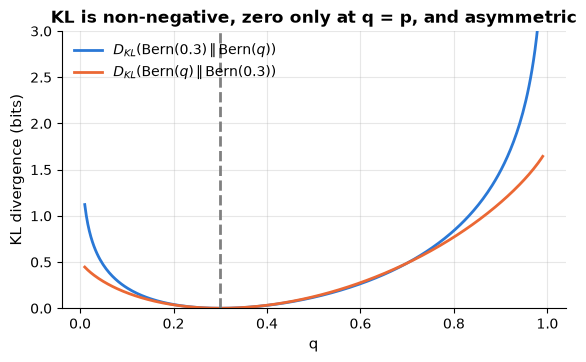

In [161]:
def cross_entropy(p, q, base=2):
    """Cross-entropy H(p, q) = -sum p log q, in bits by default; terms where p = 0 contribute nothing."""
    p, q = np.asarray(p, dtype=float), np.asarray(q, dtype=float)
    mask = p > 0
    return -np.sum(p[mask] * np.log(q[mask])) / np.log(base)

def kl_divergence(p, q, base=2):
    """Kullback-Leibler divergence KL(p || q) = H(p, q) - H(p), in bits by default."""
    return cross_entropy(p, q, base) - entropy(p, base)

# e.g. p: how customers really split over three payment methods (card, cash, app); q: what a model assumes
p = np.array([0.5, 0.3, 0.2])
q = np.array([0.2, 0.5, 0.3])
print(f"H(p) = {entropy(p):.4f}  H(p, q) = {cross_entropy(p, q):.4f}  KL(p||q) = {kl_divergence(p, q):.4f}  KL(q||p) = {kl_divergence(q, p):.4f} bits")
print(f"KL(p||p) = {kl_divergence(p, p):.4f};  H(p, q) >= H(p): {cross_entropy(p, q) >= entropy(p)}")
# rng.dirichlet(np.ones(5)) draws a random probability vector of length 5 (non-negative, summing to 1);
# size=(2000, 2) gives an array of shape (2000, 2, 5): 2000 pairs of distributions
random_pairs = rng.dirichlet(np.ones(5), size=(2000, 2))
kls = [kl_divergence(a, b) for a, b in random_pairs]   # each item is a (2, 5) array, unpacked into a and b
print(f"smallest KL over 2000 random pairs of distributions: {min(kls):.4f}  (Gibbs' inequality: never negative)")

mu1, s1, mu2, s2 = 0.0, 1.0, 1.0, 1.5
kl_closed = np.log(s2 / s1) + (s1 ** 2 + (mu1 - mu2) ** 2) / (2 * s2 ** 2) - 0.5   # natural log -> nats
# the KL integrand p(x) (log p(x) - log q(x)) for p = N(mu1, s1^2) and q = N(mu2, s2^2)
integrand = lambda x: stats.norm(mu1, s1).pdf(x) * (stats.norm(mu1, s1).logpdf(x) - stats.norm(mu2, s2).logpdf(x))
# integrate.quad(f, a, b) numerically integrates f from a to b and returns (value, error estimate); [0] is the value
kl_numeric = integrate.quad(integrand, -20, 20)[0]
print(f"KL between two Gaussians: closed form {kl_closed:.5f} nats, numerical integration {kl_numeric:.5f} nats")

qs = np.linspace(0.01, 0.99, 300)
p_fixed = 0.3
fig, ax = plt.subplots(figsize=(6.5, 3.6))
# KL in both directions between Bernoulli(0.3) and Bernoulli(q), for every q on the grid
ax.plot(qs, [kl_divergence([p_fixed, 1 - p_fixed], [q_, 1 - q_]) for q_ in qs], lw=2, label="$D_{KL}(\\mathrm{Bern}(0.3)\\,\\|\\,\\mathrm{Bern}(q))$")
ax.plot(qs, [kl_divergence([q_, 1 - q_], [p_fixed, 1 - p_fixed]) for q_ in qs], lw=2, label="$D_{KL}(\\mathrm{Bern}(q)\\,\\|\\,\\mathrm{Bern}(0.3))$")
ax.axvline(p_fixed, color="gray", ls="--")
ax.set_ylim(0, 3)
ax.set_xlabel("q")
ax.set_ylabel("KL divergence (bits)")
ax.set_title("KL is non-negative, zero only at q = p, and asymmetric")
ax.legend()
plt.show()

**Example — a fair coin you believe is biased.** The coin is fair, $p = (\tfrac12, \tfrac12)$, but you believe
$q = (\tfrac14, \tfrac34)$. Your average surprise is the cross-entropy

$$
H(p, q) = \tfrac12\log_2 4 + \tfrac12\log_2\tfrac43 = 1 + 0.5 \times 0.415 = 1.208 \text{ bits},
$$

against $H(p) = 1$ bit for someone who knows the coin is fair, so the wrong belief costs
$D_{\mathrm{KL}}(p\,\|\,q) = 0.208$ bits per toss. The other direction gives
$D_{\mathrm{KL}}(q\,\|\,p) = \tfrac14\log_2\tfrac12 + \tfrac34\log_2\tfrac32 = -0.25 + 0.439 = 0.189$ bits. The asymmetry
grows when $q$ almost rules out an outcome that $p$ allows: for $q = (0.99, 0.01)$,
$D_{\mathrm{KL}}(p\,\|\,q) = 2.33$ bits but $D_{\mathrm{KL}}(q\,\|\,p) = 0.92$ bits. For two Gaussians with the same
$\sigma$ the closed form above reduces to $(\mu_1 - \mu_2)^2 / (2\sigma^2)$, half the squared distance between the
means measured in standard deviations: $0.5$ nats for $\mathcal{N}(0, 1)$ against $\mathcal{N}(1, 1)$.

In [162]:
fair, believed = np.array([0.5, 0.5]), np.array([0.25, 0.75])
# entropy(), cross_entropy() and kl_divergence() are the helpers defined above (bits by default)
print(f"H(p) = {entropy(fair):.3f}  H(p, q) = {cross_entropy(fair, believed):.3f}  "
      f"KL(p||q) = {kl_divergence(fair, believed):.3f}  KL(q||p) = {kl_divergence(believed, fair):.3f} bits")
nearly_certain = np.array([0.99, 0.01])
print(f"q = (0.99, 0.01): KL(p||q) = {kl_divergence(fair, nearly_certain):.2f} bits, "
      f"KL(q||p) = {kl_divergence(nearly_certain, fair):.2f} bits")
# the Gaussian closed form above for N(0, 1) and N(1, 1): the same standard deviation, means 1 apart
mu_a, mu_b, sigma = 0.0, 1.0, 1.0
kl_gauss = np.log(sigma / sigma) + (sigma ** 2 + (mu_a - mu_b) ** 2) / (2 * sigma ** 2) - 0.5   # natural log: nats
print(f"KL(N(0, 1) || N(1, 1)) = {kl_gauss:.3f} nats;  (mu_a - mu_b)^2 / (2 sigma^2) = "
      f"{(mu_a - mu_b) ** 2 / (2 * sigma ** 2):.3f}")

H(p) = 1.000  H(p, q) = 1.208  KL(p||q) = 0.208  KL(q||p) = 0.189 bits
q = (0.99, 0.01): KL(p||q) = 2.33 bits, KL(q||p) = 0.92 bits
KL(N(0, 1) || N(1, 1)) = 0.500 nats;  (mu_a - mu_b)^2 / (2 sigma^2) = 0.500


> **In machine learning.** Cross-entropy is the log loss (section 5.3); KL divergence compares distributions:
> - **Drift monitoring.** The population stability index compares a feature's binned distribution in production and
>   in training: $\mathrm{PSI} = D_{\mathrm{KL}}(\text{current}\,\|\,\text{reference}) + D_{\mathrm{KL}}(\text{reference}\,\|\,\text{current})$
>   (notebook 18, §7.2). Credit-scoring rules of thumb read PSI $< 0.1$ as no meaningful change and $> 0.25$ as a
>   significant shift — conventions, not tests. In the demo below, an unchanged month scores 0.015 (sampling noise),
>   and raising every monthly charge by 5, 10 and 20 % gives 0.10, 0.27 and 0.80.
> - **t-SNE** minimises $D_{\mathrm{KL}}(P\,\|\,Q)$ between neighbour probabilities in the data and in the 2-D map
>   (notebook 14, §5.2). As in the example, a large $p$ with a tiny $q$ is expensive and the reverse cheap, so
>   neighbours stay together but distances between clusters mean little.
> - **Class separability.** Two equally likely Gaussian classes with a common $\sigma$ and means $\Delta\sigma$ apart
>   have $D_{\mathrm{KL}} = \Delta^2/2$; the best possible error rate, $\Phi(-\Delta/2)$ (section 3.2; notebook 8, §1.5), falls as
>   it grows.

In [163]:
monthly_ref = churn["monthly_charges"].dropna().to_numpy()     # reference: the monthly charges seen in training
rng_demo = np.random.default_rng(0)   # its own seeded generator: reproducible, and the notebook's rng is left untouched
# a simulated new month: 2000 charges drawn with replacement from the reference (rng_demo.choice), so no real change
new_month = rng_demo.choice(monthly_ref, size=2000)
# bin edges at the deciles of the reference; opening the outer edges lets every value fall into a bin
decile_edges = np.quantile(monthly_ref, np.linspace(0, 1, 11))
decile_edges[0], decile_edges[-1] = -np.inf, np.inf

def bin_shares(values):
    """Share of the values in each decile bin of the reference, floored at 1e-6 so that no logarithm sees a 0."""
    # np.histogram(values, bins=edges)[0] counts the values falling into each bin
    return np.clip(np.histogram(values, bins=decile_edges)[0] / len(values), 1e-6, None)

reference_shares = bin_shares(monthly_ref)                     # about 0.1 in every bin, by construction
for price_rise in [0.0, 0.05, 0.10, 0.20]:
    current_shares = bin_shares(new_month * (1 + price_rise))  # every charge raised by the same percentage
    # PSI = KL(current || reference) + KL(reference || current), in nats (base=np.e)
    psi_value = (kl_divergence(current_shares, reference_shares, base=np.e)
                 + kl_divergence(reference_shares, current_shares, base=np.e))
    print(f"price rise {price_rise:3.0%}: PSI = {psi_value:.3f}")

price rise  0%: PSI = 0.015
price rise  5%: PSI = 0.104
price rise 10%: PSI = 0.273
price rise 20%: PSI = 0.796


### 5.3 From information theory to loss functions and decision trees

> **Key idea.** A good model is rarely surprised by the data, and a good question removes as much uncertainty as
> possible. The first idea is the log loss that trains classifiers; the second is how a decision tree chooses its
> splits and how mutual information picks out the features that tell us something about the target.

Three consequences tie this section to the rest of the course.

**Cross-entropy loss is KL minimisation, is maximum likelihood.** Write the empirical
distribution of the labels for input $\mathbf{x}_i$ as $p_i$ (a one-hot vector) and the
model's prediction as $q_i$. The average cross-entropy $\frac{1}{n}\sum_i H(p_i, q_i) =
-\frac{1}{n}\sum_i \log q_i(y_i)$ is exactly the negative log-likelihood of section 4.3;
because $H(p_i)$ is a constant (in fact $0$: a one-hot label holds no surprise),
minimising the average cross-entropy minimises $\frac{1}{n}\sum_i
D_{\mathrm{KL}}(p_i \| q_i)$, i.e. it pushes the predicted distribution towards the observed
one. This is why the softmax + cross-entropy combination is the default output layer of
neural network classifiers, and why the log loss (notebook 7) is a proper
score for probabilities. (The **softmax**, $\operatorname{softmax}(\mathbf{z})_k = e^{z_k} / \sum_{j=1}^{K} e^{z_j}$,
turns a model's $K$ class scores into probabilities; a score is **proper** if reporting the true probabilities
minimises its expected value. Both are worked through after the churn example below.)

**Mutual information** measures how much knowing $X$ tells you about $Y$:
$I(X; Y) = D_{\mathrm{KL}}\big(p(x, y)\,\|\,p(x)p(y)\big) = H(Y) - H(Y \mid X)$, where
$H(Y \mid X) = \sum_x p(x) H(Y \mid X = x)$ is the conditional entropy. It is zero exactly
when $X$ and $Y$ are independent, and it is the basis of the `mutual_info_*` feature
selectors in notebook 4.

> **Real-life example.** Electricity demand in a region with both electric heating and air
> conditioning is high on cold days and on hot days and lowest in mild weather. This U-shape can
> give a correlation with temperature close to 0, yet the mutual information is clearly positive:
> the temperature tells the grid operator a lot about the demand to expect, and a correlation screen
> would wrongly drop it.

**Information gain in decision trees.** Splitting a node whose labels have entropy $H(Y)$
on feature $X$ leaves children with average entropy $H(Y \mid X)$; the reduction
$H(Y) - H(Y \mid X)$ is the **information gain** — and it *is* the mutual information
between the feature and the label. Notebook 9 grows trees by picking, at every node, the
split with the largest gain (or the largest decrease of the closely related Gini
impurity). Computed on the churn data, using the joint table from section 3.3:

In [164]:
from sklearn.metrics import mutual_info_score   # mutual information between two columns of discrete labels

H_churn = entropy(marg_churn)                   # H(Y): entropy of the churn label
# H(Y | X) = sum over contracts c of P(c) * H(Y | X = c); conditional.loc[c] is the row (P(0 | c), P(1 | c))
H_churn_given_contract = sum(marg_contract[c] * entropy(conditional.loc[c]) for c in conditional.index)
info_gain = H_churn - H_churn_given_contract
# flatten the 3 x 2 joint table and the independence table into two distributions over 6 outcomes
mi_from_kl = kl_divergence(joint.to_numpy().ravel(), independent.ravel())
mi_sklearn = mutual_info_score(churn["contract"], churn["churned"]) / np.log(2)      # sklearn returns nats

print(f"H(churned) = {H_churn:.4f} bits;  H(churned | contract) = {H_churn_given_contract:.4f} bits")
print(f"information gain of splitting on contract = {info_gain:.4f} bits")
print(f"mutual information as KL(joint || product of marginals) = {mi_from_kl:.4f} bits;  sklearn mutual_info_score = {mi_sklearn:.4f} bits")
for feature in ["internet_service", "payment_method", "region", "senior_citizen"]:
    print(f"  information gain of {feature:17s}: {mutual_info_score(churn[feature], churn['churned']) / np.log(2):.4f} bits")

H(churned) = 0.9112 bits;  H(churned | contract) = 0.8043 bits
information gain of splitting on contract = 0.1069 bits
mutual information as KL(joint || product of marginals) = 0.1069 bits;  sklearn mutual_info_score = 0.1069 bits
  information gain of internet_service : 0.0775 bits
  information gain of payment_method   : 0.0014 bits
  information gain of region           : 0.0008 bits
  information gain of senior_citizen   : 0.0024 bits


Contract type is by far the most informative of these features about churn (a tree would
split on it first), and `region` carries essentially none — consistent with how the data
were generated.

**Example — one split by hand.** A node holds 8 customers, 4 who churned and 4 who stayed, so $H(Y) = 1$ bit. Split
A sends 3 churners and 1 stayer to the left and the rest (1 churner, 3 stayers) to the right. Each child has
$H = \tfrac34\log_2\tfrac43 + \tfrac14\log_2 4 = 0.811$ bits, so the **conditional entropy** — the uncertainty left
once you know which side a customer went to — is $H(Y \mid A) = \tfrac48 \times 0.811 + \tfrac48 \times 0.811 = 0.811$
bits, and the **information gain** is $1 - 0.811 = 0.189$ bits, which is also the mutual information $I(Y; A)$.
Split B sends 2 churners and 2 stayers each way: the children are as mixed as the parent, so the gain is $0$, as for
any split independent of the label; a perfect split would gain the full bit.

**Gini impurity.** The other common impurity measure is $G = 1 - \sum_k p_k^2$, the probability that two labels
drawn at random (with replacement) from the node differ. The parent has $G = 1 - (0.5^2 + 0.5^2) = 0.5$ and each
child of split A $G = 1 - (0.75^2 + 0.25^2) = 0.375$, a decrease of $0.125$; split B again gains nothing. Like
entropy, Gini is $0$ for a pure node and largest for an even mix, but it needs no logarithm. Both rank these two
splits the same way; on real data they sometimes pick different splits, but the resulting trees are about equally
accurate (notebook 9, §10.2).

In [165]:
churned_node = np.array([1, 1, 1, 1, 0, 0, 0, 0])                    # the node's labels: 4 churners, 4 stayers
# True = the customer goes to the left child
goes_left = {"A": np.array([True, True, True, False, True, False, False, False]),    # 3 churners + 1 stayer
             "B": np.array([True, True, False, False, True, True, False, False])}    # 2 churners + 2 stayers

def impurities(labels):
    """Return the array [entropy in bits, Gini impurity] of an array of 0/1 labels (entropy() is from 5.1)."""
    share = labels.mean()                                           # proportion of 1s
    return np.array([entropy([share, 1 - share]), 1 - share ** 2 - (1 - share) ** 2])

for split_name, left in goes_left.items():
    left_labels, right_labels = churned_node[left], churned_node[~left]      # ~left: the customers going right
    # impurity after the split: the children's impurities, weighted by their shares of the 8 customers
    after_split = (len(left_labels) * impurities(left_labels) + len(right_labels) * impurities(right_labels)) / 8
    gain_bits, gini_decrease = impurities(churned_node) - after_split       # a 2-element array unpacks into 2 names
    mi_bits = mutual_info_score(left, churned_node) / np.log(2)              # imported above; it reports nats
    print(f"split {split_name}: H(Y | split) = {after_split[0]:.3f} bits, information gain = {gain_bits:.3f} bits, "
          f"mutual information = {mi_bits:.3f} bits, Gini decrease = {gini_decrease:.3f}")

split A: H(Y | split) = 0.811 bits, information gain = 0.189 bits, mutual information = 0.189 bits, Gini decrease = 0.125
split B: H(Y | split) = 1.000 bits, information gain = 0.000 bits, mutual information = 0.000 bits, Gini decrease = 0.000


**Softmax: from scores to probabilities.** A model for $K$ classes first computes one score per class —
multinomial logistic regression uses $z_k = \mathbf{w}_k^\top\mathbf{x} + b_k$ (notebook 7, §4.1) — and the softmax
turns the scores into probabilities: exponentiating makes them positive, dividing by their sum makes them add up to
1, and a larger score always gets a larger probability.

**Example — three classes.** Scores $\mathbf{z} = (2, 1, 0.1)$ give $e^{2} = 7.389$, $e^{1} = 2.718$ and
$e^{0.1} = 1.105$, with sum $11.2125$, so $\operatorname{softmax}(\mathbf{z}) = (0.659, 0.242, 0.099)$. If the true
class is $k$, the cross-entropy loss is $-\ln \operatorname{softmax}(\mathbf{z})_k = \ln 11.2125 - z_k = 2.417 - z_k$:
$0.417$ nats if it is the first class, $2.317$ nats if it is the third; averaged over the data, this is the
multi-class log loss. Adding the same constant to every score changes nothing (the factor $e^{c}$ cancels), so only
differences between scores matter. With two classes, $\operatorname{softmax}(z_1, z_2)_1 = 1/(1 + e^{-(z_1 - z_2)}) = \sigma(z_1 - z_2)$:
the sigmoid of section 4.3 is the two-class softmax. The code checks these numbers, that `LogisticRegression`
computes its probabilities in exactly this way, and that scikit-learn's `log_loss` is this average.

In [166]:
from scipy.special import softmax        # softmax(z, axis=...): exp(z) divided by its sum along that axis
from sklearn.datasets import load_iris   # 150 iris flowers: 4 measurements each, 3 species

scores_demo = np.array([2.0, 1.0, 0.1])
probs_demo = np.exp(scores_demo) / np.exp(scores_demo).sum()            # softmax by hand
print("softmax by hand:", probs_demo.round(3), "  scipy:", softmax(scores_demo).round(3))
print(f"loss if the true class is the 1st: {-np.log(probs_demo[0]):.3f} nats; the 3rd: {-np.log(probs_demo[2]):.3f} nats")
# two classes: only the difference of the scores matters (sigmoid() was defined in section 4.3)
print(f"softmax([2.5, 1.0])[0] = {softmax([2.5, 1.0])[0]:.4f};  sigmoid(2.5 - 1.0) = {sigmoid(2.5 - 1.0):.4f}")

X_iris, y_iris = load_iris(return_X_y=True)
iris_clf = LogisticRegression(max_iter=1000).fit(X_iris, y_iris)  # unscaled features: allow more solver iterations
iris_probs = softmax(iris_clf.decision_function(X_iris), axis=1)   # decision_function: (150, 3) linear class scores
print("predict_proba == softmax of the scores:", np.allclose(iris_clf.predict_proba(X_iris), iris_probs))
# iris_probs[np.arange(150), y_iris] picks, in every row i, the probability of the true class y_i;
# log_loss (imported in section 4.3) should be the mean of -ln of those probabilities
print(f"log_loss {log_loss(y_iris, iris_probs):.4f} = mean of -ln(probability of the true class) "
      f"{-np.log(iris_probs[np.arange(150), y_iris]).mean():.4f}")

softmax by hand: [0.659 0.242 0.099]   scipy: [0.659 0.242 0.099]
loss if the true class is the 1st: 0.417 nats; the 3rd: 2.317 nats
softmax([2.5, 1.0])[0] = 0.8176;  sigmoid(2.5 - 1.0) = 0.8176
predict_proba == softmax of the scores: True
log_loss 0.1196 = mean of -ln(probability of the true class) 0.1196


**Example — the log loss rewards honest probabilities.** Suppose 30 % of the customers in a segment churn, and a
forecaster reports the churn probability $q$. Averaged over the segment, the log loss is
$-[0.3\ln q + 0.7\ln(1 - q)]$, the cross-entropy $H(p, q) = H(p) + D_{\mathrm{KL}}(p\,\|\,q)$ of section 5.2, so by
Gibbs' inequality it is smallest at the honest $q = 0.3$; the extra loss of reporting any other $q$ is the curve
$D_{\mathrm{KL}}(\mathrm{Bern}(0.3)\,\|\,\mathrm{Bern}(q))$ in the figure of section 5.2 (there in bits). The log loss
is therefore proper, and so is the Brier score $(y - q)^2$ of notebook 7. The absolute error $|y - q|$ is not: its
average, $0.3(1 - q) + 0.7q = 0.3 + 0.4q$, keeps falling as $q$ goes to 0, so it rewards claiming that nobody churns.

In [167]:
q_grid = np.linspace(0.01, 0.99, 99)                 # candidate forecasts 0.01, 0.02, ..., 0.99
churn_share = 0.3                                    # the true churn probability of the segment
# expected score of each forecast = churn_share * (score if y = 1) + (1 - churn_share) * (score if y = 0)
expected_scores = {"log loss": -(churn_share * np.log(q_grid) + (1 - churn_share) * np.log(1 - q_grid)),
                   "Brier score": churn_share * (1 - q_grid) ** 2 + (1 - churn_share) * q_grid ** 2,
                   "absolute error": churn_share * (1 - q_grid) + (1 - churn_share) * q_grid}
for score_name, expected in expected_scores.items():
    # np.argmin gives the position of the smallest expected score; q_grid[...] is the forecast at that position
    print(f"{score_name:14s}: best forecast q = {q_grid[np.argmin(expected)]:.2f}")

log loss      : best forecast q = 0.30
Brier score   : best forecast q = 0.30
absolute error: best forecast q = 0.01


> **In machine learning.**
> - **Softmax + cross-entropy for many classes.** For more than two classes `LogisticRegression` minimises the
>   (penalised) cross-entropy of its softmax probabilities (notebook 7, §4.1), and gradient-boosted classifiers
>   minimise the same log loss by default (notebook 10, §5.1).
> - **Proper scores keep probabilities honest.** The log loss and the Brier score judge predicted probabilities,
>   including their *calibration* — whether about 30 % of the customers given 30 % really churn (notebook 7, §7.1);
>   an improper score, like the absolute error, rewards over-confidence.
> - **Splitting criteria.** `DecisionTreeClassifier` and `RandomForestClassifier` use the Gini decrease by default
>   (`criterion="gini"`); `criterion="entropy"` (or `"log_loss"`) uses the information gain (notebook 9, §2.1 and
>   §10.2).
> - **Mutual information sees any dependence**, not just straight lines: in the demo below, a U-shaped feature has a
>   correlation near 0 with the target but about the same mutual information as a linear one. Hence its use to screen
>   features (`mutual_info_classif`, `mutual_info_regression`; notebook 4, §7.1).

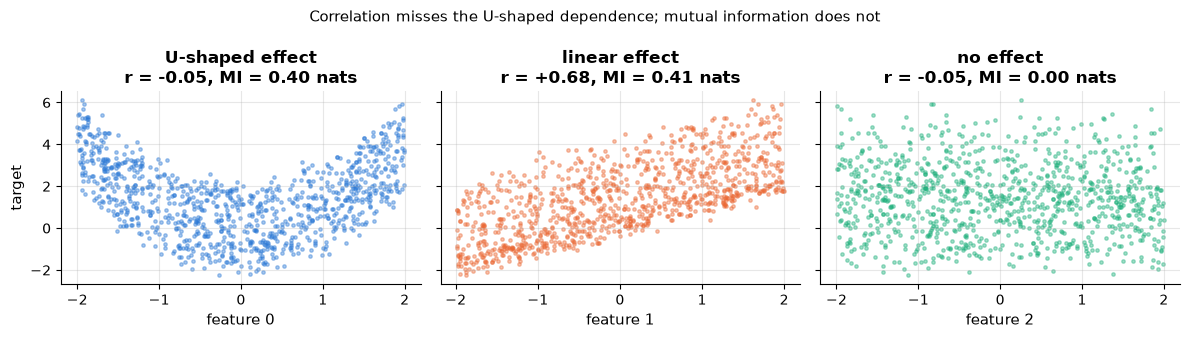

In [168]:
from sklearn.feature_selection import mutual_info_regression   # estimates I(feature; target) in nats, per column

rng_demo = np.random.default_rng(0)   # its own seeded generator: reproducible, and the notebook's rng is left untouched
# uniform(low, high, size): random numbers spread evenly between -2 and 2; 1000 samples of three candidate features
features_demo = rng_demo.uniform(-2, 2, size=(1000, 3))
# e.g. temperature, industrial activity and a meter's serial number, with electricity demand as the target:
# the target depends on feature 0 through a U-shape, on feature 1 linearly, and not at all on feature 2
target_demo = features_demo[:, 0] ** 2 + features_demo[:, 1] + 0.3 * rng_demo.normal(size=1000)
# a nearest-neighbour estimate; random_state seeds the tiny noise it adds to break ties between equal values
mi_demo = mutual_info_regression(features_demo, target_demo, random_state=RANDOM_STATE)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.4), sharey=True)    # sharey=True: the panels share one y-axis
for j, (ax, effect) in enumerate(zip(axes, ["U-shaped effect", "linear effect", "no effect"])):
    # np.corrcoef(a, b) is the 2 x 2 correlation matrix of a and b; [0, 1] is Pearson's r between them
    corr_j = np.corrcoef(features_demo[:, j], target_demo)[0, 1]
    ax.scatter(features_demo[:, j], target_demo, s=6, alpha=0.4, color=PALETTE[j])   # s: marker size, alpha: opacity
    ax.set_title(f"{effect}\nr = {corr_j:+.2f}, MI = {mi_demo[j]:.2f} nats")
    ax.set_xlabel(f"feature {j}")
axes[0].set_ylabel("target")
fig.suptitle("Correlation misses the U-shaped dependence; mutual information does not", fontsize=11)
plt.tight_layout()
plt.show()

## Summary

- **Linear algebra.** Norms and dot products measure size and similarity, and a distance is the
  norm of a difference — so the units of the features matter: standardise first. A data set is a
  design matrix $\mathbf{X}$, and $\mathbf{X}\mathbf{w}$ computes every prediction at once. Matrices
  are linear maps with a rank and, when square and full-rank, an inverse; redundant columns (all
  dummies plus an intercept) lower the rank. Least squares is a *projection* onto the column space
  of $\mathbf{X}$. Symmetric matrices have orthogonal eigenvectors (the principal axes of PCA; the
  trace is the total variance); every matrix has an SVD whose truncation is the best low-rank
  approximation. Covariance and Gram matrices are PSD; adding $\lambda\mathbf{I}$ makes them PD.
- **Calculus.** The gradient is the direction of steepest ascent; the chain rule composes
  gradients (backpropagation); check every hand-derived gradient numerically. Gradient
  descent converges for $\eta < 2/\lambda_{\max}$ at a speed governed by the condition
  number (scale your features!); machine-learning code usually minimises *mean* losses, so that one
  learning rate suits any $n$, and stochastic (mini-batch) gradient descent trades exact steps for cheap
  noisy ones. On convex functions gradient descent finds the global minimum, on non-convex ones a
  local one that depends on the start.
- **Probability.** Expectation is linear, variance adds for independent variables; joint =
  conditional × marginal. The CDF and its inverse, the quantile function, give medians, IQRs and
  the 1.96 of confidence intervals; correlation measures only linear dependence. Bayes' theorem
  turns likelihood and prior into a posterior, and base rates matter. LLN: averages converge;
  CLT: averages are approximately Gaussian with standard error $\sigma/\sqrt{n}$ — and a test accuracy is such
  an average.
- **Statistics.** MSE = bias² + variance. Least squares = Gaussian MLE, cross-entropy =
  Bernoulli negative log-likelihood (the sigmoid turns a score into a probability), ridge = MAP
  with a Gaussian prior: for these common losses, choosing a loss is choosing a noise model. Confidence intervals via the
  CLT or, for any statistic, via the bootstrap. Paired $t$-tests on CV folds are optimistic, and
  among many tests some come out "significant" by chance alone (multiple comparisons).
- **Information theory.** Entropy = expected surprise = impurity (Gini impurity is the common
  alternative); cross-entropy = entropy + KL; KL $\ge 0$ and asymmetric; softmax turns scores
  into probabilities, and minimising cross-entropy = MLE; information gain = mutual information,
  which also sees the non-linear dependence that correlation misses; a symmetrised KL (PSI)
  monitors drift.

| Concept | Formula | Where it is used |
|---|---|---|
| distance | $\lVert\mathbf{x} - \mathbf{y}\rVert_2$ | $k$-nearest neighbours (8), $k$-means (13), feature scaling (4) |
| cosine similarity | $\mathbf{x}^\top\mathbf{y} / (\lVert\mathbf{x}\rVert\,\lVert\mathbf{y}\rVert)$ | text and word vectors (15) |
| design matrix | $\mathbf{X}\mathbf{w} + b$: all predictions (or class scores) at once | every linear model (6, 7, 11) |
| projection / normal equations | $\mathbf{X}^\top\mathbf{X}\mathbf{w} = \mathbf{X}^\top\mathbf{y}$ | linear regression (6) |
| eigen-decomposition of $\boldsymbol{\Sigma}$ | $\boldsymbol{\Sigma} = \mathbf{Q}\boldsymbol{\Lambda}\mathbf{Q}^\top$ | PCA (14), Gaussian mixtures (13) |
| truncated SVD | $\mathbf{A}_k = \sum_{i \le k}\sigma_i\mathbf{u}_i\mathbf{v}_i^\top$ | PCA, recommenders (14), LSA (15) |
| gradient descent | $\mathbf{w} \leftarrow \mathbf{w} - \eta\nabla\mathcal{L}$, $\eta < 2/\lambda_{\max}$ | linear and logistic regression (6, 7), SVMs (11), boosting (10) |
| condition number | $\kappa = \lambda_{\max}/\lambda_{\min}$ | feature scaling (4), gradient descent (6) |
| chain rule | $\partial L/\partial \mathbf{w} = (\partial L/\partial z)\,\partial z/\partial \mathbf{w}$ | logistic regression's gradient (7); backpropagation in neural networks |
| Bayes' theorem | $P(y \mid \mathbf{x}) \propto P(\mathbf{x} \mid y)P(y)$ | naive Bayes (8), precision and base rates (7) |
| CDF / quantiles | $F(x) = P(X \le x)$, $\Phi(1.96) = 0.975$ | confidence intervals (3, 6, 20), Bayesian optimisation (12), robust scaling (4), quantile regression (16) |
| correlation | $\rho = \operatorname{Cov}[X, Y] / (\sigma_X\sigma_Y)$ | EDA (3), multicollinearity (6), feature importance (17) |
| CLT / standard error | $\bar{x} \pm 1.96\, s/\sqrt{n}$ | error bars on test and CV scores (5, 12) |
| MLE | $\arg\max_\theta \sum_i \log p(x_i \mid \theta)$ | least squares (6), logistic regression (7), naive Bayes (8), EM (13) |
| sigmoid and log loss | $\sigma(z) = 1/(1 + e^{-z})$, $-[y\ln p + (1 - y)\ln(1 - p)]$ | logistic regression, calibration (7) |
| MAP / regularisation | ridge ↔ Gaussian prior, lasso ↔ Laplace prior | ridge and lasso (6), `C` $= 1/\lambda$ (7) |
| bootstrap | resample with replacement, take quantiles | confidence intervals (6, 20), bagging (10) |
| entropy, information gain | $H = -\sum p\log p$, $H(Y) - H(Y \mid X)$ | decision trees (9), feature selection (4) |
| Gini impurity | $1 - \sum_k p_k^2$ | decision trees and random forests (9, 10) |
| cross-entropy, softmax | $-\sum_x p(x)\log q(x)$, $e^{z_k} / \sum_j e^{z_j}$ | log loss and softmax regression (7) |
| KL divergence | $\sum_x p(x)\log\frac{p(x)}{q(x)}$ | t-SNE (14), drift monitoring with PSI (18) |
| mutual information | $I(X; Y) = H(Y) - H(Y \mid X)$ | feature selection (4), comparing clusterings by normalised mutual information (13) |

**Next steps:** notebook 3 (exploratory data analysis) applies the descriptive statistics;
notebook 5 (fundamentals) builds the bias–variance decomposition on section 4.1; notebook
6 (linear regression) derives least squares and ridge in full from sections 1.3, 2.2 and
4.4; notebook 7 (logistic regression) develops the cross-entropy loss and its gradient;
notebook 8 ($k$-nearest neighbours and naive Bayes) builds on the distances of section 1.1 and
on Bayes' theorem; notebook 9 (decision trees) uses information gain; notebook 14
(dimensionality reduction) builds PCA on sections 1.4–1.5.

## Exercises

### Exercise 1 — The projection formula (easy)
Draw a random matrix `A` of shape `(20, 3)` and a random vector `b` of length 20. Compute
the projection matrix $\mathbf{P} = \mathbf{A}(\mathbf{A}^\top\mathbf{A})^{-1}\mathbf{A}^\top$
and verify numerically that (a) $\mathbf{P}^2 = \mathbf{P}$, (b) $\mathbf{P}^\top = \mathbf{P}$,
(c) the eigenvalues of $\mathbf{P}$ are only 0 and 1, with exactly three 1s, (d)
$\|\mathbf{b} - \mathbf{P}\mathbf{b}\| \le \|\mathbf{b} - \mathbf{A}\mathbf{w}\|$ for 1 000
random $\mathbf{w}$. Then compute the SVD of $\mathbf{A}$ and show that
$\mathbf{P} = \mathbf{U}\mathbf{U}^\top$.

<details><summary>Solution sketch</summary>

`P = A @ np.linalg.solve(A.T @ A, A.T)`; `np.linalg.eigvalsh(P).round(6)` shows 17 zeros
and 3 ones (the rank); `U, s, Vt = np.linalg.svd(A, full_matrices=False)` and
`np.allclose(P, U @ U.T)` — projection onto the column space only needs an orthonormal
basis of it, which is what $\mathbf{U}$ provides.
</details>

### Exercise 2 — Newton's method in one dimension (medium)
Newton's method uses curvature as well as slope: $x_{t+1} = x_t - f'(x_t)/f''(x_t)$.
Implement it and gradient descent for $f(x) = x^4 - 3x^2 + x$ from $x_0 = 2$, and compare
the number of iterations each needs to reach $|f'(x)| < 10^{-8}$. Then start both from
$x_0 = -0.2$. What does Newton's method converge to, and why? (Hint: section 2.5.)

<details><summary>Solution sketch</summary>

With $f' = 4x^3 - 6x + 1$ and $f'' = 12x^2 - 6$, Newton converges in about 6 iterations
from $x_0 = 2$ versus hundreds for gradient descent with a safe $\eta$ (quadratic vs. linear
convergence). From $x_0 = -0.2$, $f'' < 0$: Newton steps *uphill* to the local maximum near
$x \approx 0.17$ — it finds stationary points, not minima. Notebook 7 mentions Newton/IRLS
for logistic regression, where convexity guarantees $f'' > 0$.
</details>

### Exercise 3 — Maximum likelihood for a Poisson (medium)
The number of support tickets per customer looks like a count variable. Derive the MLE of
$\lambda$ for i.i.d. Poisson data (log-likelihood $\ell(\lambda) = \sum_i [x_i\log\lambda -
\lambda - \log x_i!]$), then estimate it on `churn["support_tickets"]`, plot the fitted PMF
over the empirical histogram, and compare mean and variance of the data. Is the Poisson
model adequate?

<details><summary>Solution sketch</summary>

$\ell'(\lambda) = \sum_i x_i/\lambda - n = 0 \Rightarrow \hat\lambda = \bar{x}$. On the churn
data the sample variance exceeds the mean (over-dispersion), because $\lambda$ differs
between customers (fibre customers file more tickets) — a mixture of Poissons is not a
Poisson. `stats.poisson(x.mean()).pmf(k)` versus `np.bincount(x) / len(x)` shows the
mismatch in the tail.
</details>

### Exercise 4 — Bootstrap vs. analytic intervals for a correlation (medium)
Take `tenure_months` and `total_charges` from `load_churn()` (drop missing values). Compute
the Pearson correlation and a 95 % bootstrap percentile interval with 2 000 resamples of
*rows* (resample index pairs, not the two columns separately). Compare with Fisher's
$z$-transformation interval: $z = \operatorname{artanh}(r) \pm 1.96/\sqrt{n - 3}$, then
$\tanh$ back. Repeat on a random subsample of 40 customers. When do the two disagree?

<details><summary>Solution sketch</summary>

```py
idx = rng.integers(0, n, size=(2000, n))
boot_r = [np.corrcoef(x[i], y[i])[0, 1] for i in idx]
```
For $n \approx 5000$ both intervals are tiny and agree; for $n = 40$ the sampling
distribution of $r$ is skewed (it is bounded by 1) and the two intervals differ noticeably,
the bootstrap interval being asymmetric.
</details>

### Exercise 5 — Entropy of class distributions and the best split (medium)
Write a function `information_gain(df, feature, target)` that computes
$H(Y) - H(Y \mid X)$ for a categorical feature, and apply it to every categorical column of
`load_churn()`. Then bin `tenure_months` into 2, 4 and 8 equal-frequency buckets
(`pd.qcut`) and compute the gain of each binning. Why does the gain increase with the
number of buckets, and why is that a problem for tree learning? (Notebook 9 discusses the
bias of information gain towards many-valued features.)

<details><summary>Solution sketch</summary>

More buckets can only decrease conditional entropy (a finer partition never increases
$H(Y \mid X)$), so gain is monotone in the number of categories even when the extra
categories carry noise — a customer ID with 5 000 values would have the maximal gain and
zero predictive value. C4.5 corrects for this with the *gain ratio*; CART limits itself
to binary splits.
</details>

### Exercise 6 — Gradient descent with momentum (hard)
Add momentum to `gradient_descent`: keep a velocity $\mathbf{v} \leftarrow \beta\mathbf{v} - \eta\nabla f(\mathbf{w})$,
$\mathbf{w} \leftarrow \mathbf{w} + \mathbf{v}$ (Polyak, 1964).
On the bowl with condition number 25, compare the number of steps needed to reduce the
loss by 1000× for plain gradient descent ($\eta = 0.072$) and momentum ($\eta = 0.04$,
$\beta = 0.8$). Plot both trajectories on the contour plot. Then try $\beta = 0.95$ and
explain what you see.

<details><summary>Solution sketch</summary>

Momentum damps the oscillation along the steep axis and accelerates along the flat one: on
this bowl it needs 27 steps against 37 for plain gradient descent (17 with $\beta = 0.7$), and the
advantage grows on worse-conditioned problems, roughly like $\sqrt{\kappa}$ instead of $\kappa$. Too much
momentum ($\beta = 0.95$: 69 steps) overshoots and the trajectory spirals around the minimum
before settling. Momentum and adaptive step sizes (RMSProp, Adam) are the standard remedies. In scikit-learn they are options only of the neural-network estimators (`MLPRegressor(solver="sgd", momentum=0.9)`, or `solver="adam"`, the default); `SGDRegressor` has no momentum and offers learning-rate schedules instead, such as `learning_rate="invscaling"` (its default) or `"adaptive"` (divide the step by 5 whenever the loss stops improving).
</details>

## References and further reading

### Textbooks

- Deisenroth, M. P., Faisal, A. A., & Ong, C. S. (2020). *Mathematics for Machine Learning*. Cambridge University Press. (free at https://mml-book.github.io) — Written for exactly this purpose: chapters 2–7 cover linear algebra, geometry, matrix decompositions, vector calculus, probability and optimisation; chapters 8–10 apply them to regression, PCA and density estimation.
- Strang, G. (2019). *Linear Algebra and Learning from Data*. Wellesley-Cambridge Press. — Strang's ML-flavoured linear algebra: the SVD, least squares, the four fundamental subspaces, and optimisation for deep learning.
- Boyd, S., & Vandenberghe, L. (2018). *Introduction to Applied Linear Algebra: Vectors, Matrices, and Least Squares*. Cambridge University Press. (free) — Gentle and concrete; chapters 3 (norms, distance, angle) and 12–15 (least squares and regularisation).
- Boyd, S., & Vandenberghe, L. (2004). *Convex Optimization*. Cambridge University Press. (free) — Chapters 2–4 define convexity; chapter 9 analyses gradient descent and Newton's method, including conditioning.
- Nocedal, J., & Wright, S. J. (2006). *Numerical Optimization* (2nd ed.). Springer. — The standard reference on line search, quasi-Newton methods (BFGS, used by `scipy.optimize.minimize`) and more.
- Wasserman, L. (2004). *All of Statistics: A Concise Course in Statistical Inference*. Springer. — The statistics of this notebook in compact, mathematically honest form; chapter 8 is the bootstrap, chapter 9 maximum likelihood.
- Blitzstein, J. K., & Hwang, J. (2019). *Introduction to Probability* (2nd ed.). CRC Press. (free) — The friendliest rigorous probability book; chapter 2 (conditioning and Bayes), chapter 10 (LLN and CLT).
- MacKay, D. J. C. (2003). *Information Theory, Inference, and Learning Algorithms*. Cambridge University Press. (free) — Chapters 1–2 and 8 for entropy and KL divergence with the coding interpretation.
- Cover, T. M., & Thomas, J. A. (2006). *Elements of Information Theory* (2nd ed.). Wiley. — Chapter 2 is the standard treatment of entropy, relative entropy and mutual information.
- Murphy, K. P. (2022). *Probabilistic Machine Learning: An Introduction*. MIT Press. (free) — Chapters 2–8 parallel this notebook in more depth: probability, statistics, decision theory, information theory, linear algebra, optimisation.

### Papers

- Eckart, C., & Young, G. (1936). The approximation of one matrix by another of lower rank. *Psychometrika*, 1(3), 211–218. — The low-rank approximation theorem of section 1.5.
- Cauchy, A.-L. (1847). Méthode générale pour la résolution des systèmes d'équations simultanées. *Comptes Rendus de l'Académie des Sciences*, 25, 536–538. — The origin of gradient descent.
- Robbins, H., & Monro, S. (1951). A stochastic approximation method. *The Annals of Mathematical Statistics*, 22(3), 400–407. — Stochastic gradient descent.
- Bottou, L., Curtis, F. E., & Nocedal, J. (2018). Optimization methods for large-scale machine learning. *SIAM Review*, 60(2), 223–311. — A thorough survey of gradient methods as used in machine learning.
- Polyak, B. T. (1964). Some methods of speeding up the convergence of iteration methods. *USSR Computational Mathematics and Mathematical Physics*, 4(5), 1–17. — Momentum (exercise 6).
- Fisher, R. A. (1922). On the mathematical foundations of theoretical statistics. *Philosophical Transactions of the Royal Society A*, 222, 309–368. — Maximum likelihood, consistency and efficiency.
- Efron, B. (1979). Bootstrap methods: another look at the jackknife. *The Annals of Statistics*, 7(1), 1–26. — The bootstrap.
- Dietterich, T. G. (1998). Approximate statistical tests for comparing supervised classification learning algorithms. *Neural Computation*, 10(7), 1895–1923. — Why $t$-tests on CV folds are optimistic; the $5 \times 2$ CV test.
- Nadeau, C., & Bengio, Y. (2003). Inference for the generalization error. *Machine Learning*, 52(3), 239–281. — A variance correction for repeated cross-validation.
- Shannon, C. E. (1948). A mathematical theory of communication. *Bell System Technical Journal*, 27(3), 379–423. — Entropy, and the birth of information theory.
- Kullback, S., & Leibler, R. A. (1951). On information and sufficiency. *The Annals of Mathematical Statistics*, 22(1), 79–86. — The KL divergence.

### Documentation and online resources (free)

- NumPy reference, *Linear algebra (`numpy.linalg`)* — https://numpy.org/doc/stable/reference/routines.linalg.html
- SciPy user guide, *Statistics* and *Optimization* — https://docs.scipy.org/doc/scipy/tutorial/stats.html and https://docs.scipy.org/doc/scipy/tutorial/optimize.html
- 3Blue1Brown, *Essence of linear algebra* and *Essence of calculus* (video series) — https://www.3blue1brown.com — The geometric intuition for sections 1 and 2, animated.